# Weeks 5 - 8: **Numerical Computing**
### Solving Real Physics on a Computer

---

There is a certain kind of satisfaction that comes from watching a simulation unfold on screen — orbits tracing their ellipses, a heat pulse spreading through a rod, a quantum wave smearing itself across a barrier and reappearing on the other side. This notebook is built around that feeling.

Every section grew out of a question that couldn't be answered with pen and paper alone. Analytical methods are beautiful, and we use them constantly as benchmarks. But the world is nonlinear, coupled, and messy — numerical methods are how we get there.

Run the code first. Look at the figure. Then read the explanation. Physics intuition almost always arrives *after* the numbers do.

---

### What You'll Find Here

| # | Topic | Core Skill |
|---|-------|-----------|
| 0 | Python Setup | NumPy, Matplotlib, SciPy |
| 1 | Floating-Point Arithmetic | Machine epsilon, cancellation, optimal $h$ |
| 2 | Root Finding | Bisection, Newton, Secant — convergence rates |
| 3 | Numerical Integration | Trapezoidal, Simpson, Gauss–Legendre, Romberg |
| 4 | Linear Algebra | Solving $Ax=b$, eigenvalues, SVD, Poisson |
| 5 | ODE Solvers | Euler, RK4, adaptive RK45 |
| 6 | Planetary Orbits | Symplectic integrators, Kepler's Third Law |
| 7 | Atmospheric Parcels | Buoyancy, lapse rate, moist convection |
| 8 | Diffusion Equation | Explicit vs implicit, stability analysis |
| 9 | Quantum Tunneling | Schrödinger as an eigenvalue problem |
| 10 | Monte Carlo Transport | Random sampling, photon transport, $1/\sqrt{N}$ |
| 11 | Lorenz System | Deterministic chaos, Lyapunov exponent |
| 12 | Navier–Stokes | Lid-driven cavity, projection method |
| 13 | Spectral Methods | FFT, power spectra, spectral derivatives |
| 14 | Shallow-Water Equations | Gravity waves, CFL stability |
| 15 | N-Body Gravity | Direct summation, softening, figure-8 orbit |
| 16 | Radiative Transfer | Two-stream approximation, greenhouse effect |
| 17 | Data Assimilation | Ensemble Kalman Filter |
| **18** | **Numerical vs Analytical** | **What numerics reveals beyond analysis** |
| **19** | **Intensive Numerical Analysis** | **Deep accuracy and stability studies** |
| **20** | **Student Projects** | **Open investigations** |
| A–B | Appendices | Constants, method reference |


## 0. Python Scientific Setup

### Why These Libraries?

Before writing any physics, we load the three pillars of scientific Python:

- **NumPy** (`numpy`): Provides fast arrays and mathematical operations. Think of it as a supercharged version of Python lists — it can do maths on entire arrays at once without slow Python `for` loops.

- **Matplotlib** (`matplotlib.pyplot`): The standard plotting library. We use it to turn arrays of numbers into graphs, contour plots, and 3-D figures.

- **SciPy** (`scipy`): Built on top of NumPy, it provides battle-tested implementations of integration, optimisation, linear algebra, and much more. We fall back to pure NumPy if SciPy is unavailable.

### The Random Number Generator

We create a **seeded** random generator (`rng = np.random.default_rng(42)`).  
The seed `42` means every time you run this notebook you get *exactly the same*  "random" numbers. As we saw in earlier weeks, this is essential for reproducible science.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D   # enables 3-D projection plots

# Try to import SciPy; fall back gracefully if not installed
try:
    from scipy import optimize, integrate, linalg, fft, signal
    SCIPY_AVAILABLE = True
    print("SciPy available:", SCIPY_AVAILABLE)
except ImportError:
    SCIPY_AVAILABLE = False
    print("SciPy not found – some sections will use pure-NumPy fallbacks")

# Print floats with 6 decimal places and suppress tiny near-zero values
np.set_printoptions(precision=6, suppress=True)

# Global plot style: grid on, clean spines, readable font
plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.grid": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11
})

# Seeded random generator – same results every run
rng = np.random.default_rng(42)

print("Environment ready.")


SciPy available: True
Environment ready.


---
## 1. Numerical Errors & Floating-Point Arithmetic

### Why Does This Matter?

Computers cannot store most real numbers exactly. Instead, they use a format called **IEEE 754 double precision**, which represents every number as:

$$x = (-1)^s \times 1.\underbrace{b_1 b_2 \cdots b_{52}}_{\text{52 mantissa bits}} \times 2^e$$

This gives roughly **15–17 significant decimal digits** of precision, which is impressive, but not infinite.

### Machine Epsilon

The most important characterisation of floating-point precision is **machine epsilon** $\varepsilon_{\text{mach}}$:

$$\varepsilon_{\text{mach}} = 2^{-52} \approx 2.22 \times 10^{-16}$$

**Practical meaning:** If you add two numbers that differ by less than $\varepsilon_{\text{mach}}$ times the larger number, the computer cannot tell them apart.

---

### Three Key Limits

| Limit | Name | What happens at/beyond it |
|-------|------|--------------------------|
| $\varepsilon_{\text{mach}}$ | Machine epsilon | Numbers closer than this are treated as equal |
| `tiny` | Smallest normal float | Numbers smaller than this lose precision (denormal) |
| `max` | Largest float | Numbers larger than this become `inf` (overflow) |

### 1.1 Inspecting Python's Floating-Point Limits


In [2]:
# np.finfo(float) reveals the limits of 64-bit floating-point on this machine
eps   = np.finfo(float).eps    # machine epsilon ≈ 2.22e-16
tiny  = np.finfo(float).tiny   # smallest positive normal number ≈ 2.23e-308
big   = np.finfo(float).max    # largest finite number ≈ 1.80e+308

print(f"Machine epsilon : {eps:.3e}")
print(f"Smallest normal : {tiny:.3e}")
print(f"Largest float   : {big:.3e}")

# Demonstration: 1 + (eps/2) is rounded back to 1 — indistinguishable!
print("\n--- Rounding demonstration ---")
print("1 + eps/2 == 1 ?", 1.0 + eps/2 == 1.0)   # True  – lost in rounding
print("1 + eps   == 1 ?", 1.0 + eps   == 1.0)   # False – just barely distinguishable


Machine epsilon : 2.220e-16
Smallest normal : 2.225e-308
Largest float   : 1.798e+308

--- Rounding demonstration ---
1 + eps/2 == 1 ? True
1 + eps   == 1 ? False


### 1.2 Catastrophic Cancellation

**What is it?**  
When you subtract two nearly equal numbers, you lose almost all significant digits. The result looks precise (it's a float with 15 digits), but most of those digits are meaningless noise. This is called **catastrophic cancellation**.

**A concrete example:**  
Consider $f(x) = \sqrt{x+1} - \sqrt{x}$.

For large $x$ (say $x = 10^{10}$), both $\sqrt{x+1}$ and $\sqrt{x}$ are approximately $10^5$, differing only in the last few digits. After subtraction, only 5–6 digits survive.

**The fix — algebraic reformulation:**  
Multiply and divide by the conjugate:

$$\sqrt{x+1} - \sqrt{x} = \frac{(\sqrt{x+1} - \sqrt{x})(\sqrt{x+1} + \sqrt{x})}{\sqrt{x+1} + \sqrt{x}} = \frac{1}{\sqrt{x+1} + \sqrt{x}}$$

The second form never subtracts two large similar numbers — it is **numerically stable**.

> **<font color='blue'>Key lesson:</font>** Whenever you're subtracting similar quantities, look for an algebraically equivalent form that avoids the cancellation.


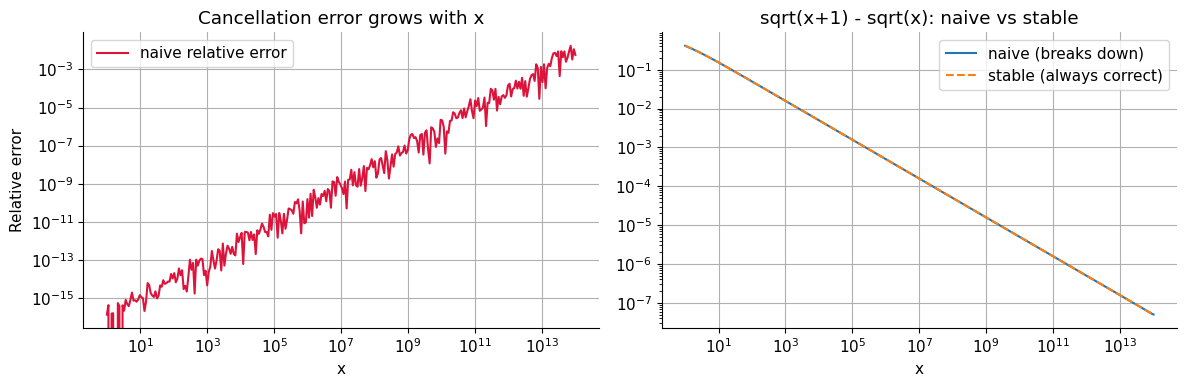

In [3]:
# Range of x values from 1 to 10^14 on a log scale
x_vals = np.logspace(0, 14, 300)

# NAIVE: directly compute sqrt(x+1) - sqrt(x)
naive  = np.sqrt(x_vals + 1) - np.sqrt(x_vals)

# STABLE: rationalised form – no subtraction of large similar numbers
stable = 1.0 / (np.sqrt(x_vals + 1) + np.sqrt(x_vals))

# Compute relative error of naive vs stable (stable is taken as truth)
rel_err = np.abs(naive - stable) / (stable + 1e-300)  # +tiny avoids /0

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left plot: show how relative error grows for the naive formula
axes[0].loglog(x_vals, rel_err, color="crimson", label="naive relative error")
axes[0].set_xlabel("x")
axes[0].set_ylabel("Relative error")
axes[0].set_title("Cancellation error grows with x")
axes[0].legend()

# Right plot: both formulas agree at small x but diverge at large x
axes[1].loglog(x_vals, naive,  label="naive (breaks down)")
axes[1].loglog(x_vals, stable, label="stable (always correct)", ls="--")
axes[1].set_xlabel("x")
axes[1].set_title("sqrt(x+1) - sqrt(x): naive vs stable")
axes[1].legend()

plt.tight_layout()
plt.show()


### 1.3 Finite-Difference Differentiation Error

**The core tension in numerical differentiation:**

The derivative is defined as:
$$f'(x) \approx \frac{f(x+h) - f(x)}{h}$$

Two competing errors pull in opposite directions as we change $h$:

| Error type | Origin | Behaviour |
|-----------|--------|-----------|
| **Truncation error** | We ignored higher-order Taylor terms | Shrinks as $h \to 0$: $O(h)$ for forward, $O(h^2)$ for central |
| **Round-off error** | Floating-point cancellation in $f(x+h)-f(x)$ | Grows as $h \to 0$: $O(\varepsilon/h)$ |

**Optimal step size** balances these:
- Forward difference: $h^* \approx \sqrt{\varepsilon} \approx 10^{-8}$
- Central difference: $h^* \approx \varepsilon^{1/3} \approx 10^{-5}$

**Central differences** are always preferred — they're $O(h^2)$ accurate vs $O(h)$  
for forward differences, at essentially no extra cost.


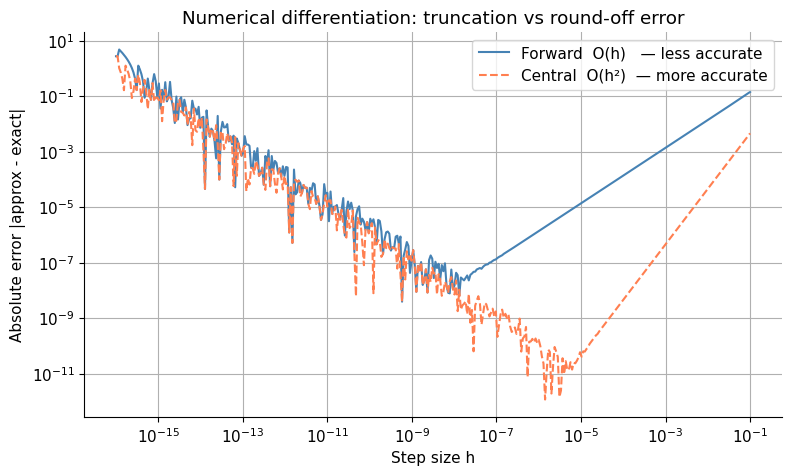

Optimal h (forward): 5.85e-10  (theory: sqrt(eps) ≈ 1.49e-08)
Optimal h (central): 1.41e-06  (theory: eps^(1/3) ≈ 6.06e-06)


In [4]:
# Test function: f(x) = e^x, exact derivative = e^x
f  = lambda x: np.exp(x)
df = lambda x: np.exp(x)
x0 = 1.0                             # evaluate derivative at x = 1

# Sweep h from 10^-16 (near machine epsilon) to 10^-1
h_ = np.logspace(-16, -1, 400)

# Forward difference: [f(x+h) - f(x)] / h
err_fwd = np.abs((f(x0+h_) - f(x0)) / h_              - df(x0))

# Central difference: [f(x+h) - f(x-h)] / 2h  — more accurate
err_cen = np.abs((f(x0+h_) - f(x0-h_)) / (2*h_)       - df(x0))

plt.figure()
plt.loglog(h_, err_fwd, label="Forward  O(h)   — less accurate", color="steelblue")
plt.loglog(h_, err_cen, label="Central  O(h²)  — more accurate", color="coral", ls="--")
plt.xlabel("Step size h")
plt.ylabel("Absolute error |approx - exact|")
plt.title("Numerical differentiation: truncation vs round-off error")
plt.legend()
plt.show()

# Report the optimal h for each method
print(f"Optimal h (forward): {h_[np.argmin(err_fwd)]:.2e}  "
      f"(theory: sqrt(eps) ≈ {np.sqrt(np.finfo(float).eps):.2e})")
print(f"Optimal h (central): {h_[np.argmin(err_cen)]:.2e}  "
      f"(theory: eps^(1/3) ≈ {np.finfo(float).eps**(1/3):.2e})")


---
## 2. Root Finding Algorithms

### The Problem

A **root** (or zero) of a function $f$ is a value $x^*$ such that $f(x^*) = 0$.  
Root-finding appears everywhere in physics:

- Finding the energy levels of a quantum well
- Locating the peak wavelength of blackbody radiation (Wien's law)
- Solving transcendental equations from circuit analysis
- Finding equilibrium states of dynamical systems

No single algorithm is best in all situations — the right choice depends on what  
you know about $f$ and how much accuracy you need.

---

### 2.1 Bisection Method

**Core idea:** If $f(a) < 0$ and $f(b) > 0$ (or vice versa), then by the  
**Intermediate Value Theorem**, there must be at least one root between $a$ and $b$.  
We repeatedly halve the interval, keeping the half that still contains the sign change.

**Convergence:** The interval shrinks by exactly $\frac{1}{2}$ each step.  
After $n$ steps, the error is at most $(b-a)/2^n$ — this is called **linear convergence**.

**Pros:** Guaranteed to converge, very robust, works for any continuous function.  
**Cons:** Slow (one function evaluation per halving), requires a bracket $[a, b]$.

$$\text{After } n \text{ steps: error} \leq \frac{b-a}{2^n}$$


In [5]:
def bisection(f, a, b, tol=1e-12, maxiter=200):
    """
    Bisection root finder.
    Returns: (root, history of midpoints)
    """
    # Safety check: the function must have opposite signs at the endpoints
    assert f(a) * f(b) < 0, "f must change sign between a and b"

    history = []   # track every midpoint for convergence analysis

    for _ in range(maxiter):
        c = 0.5 * (a + b)    # midpoint of current interval
        history.append(c)

        if abs(b - a) < tol:
            break            # interval is small enough — we're done

        # Keep the half-interval where the sign change occurs
        if f(a) * f(c) < 0:
            b = c            # root is in left half
        else:
            a = c            # root is in right half

    return c, np.array(history)


### 2.2 Newton–Raphson Method

**Core idea:** At the current estimate $x_n$, draw the tangent line to $f$.  
The tangent line crosses zero at the next estimate:

$$x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}$$

**Why is it fast?** Near the root, the error roughly **squares** each iteration:  
if you have 3 correct digits, the next step gives ~6, then ~12, then ~24.  
This is called **quadratic convergence** — astronomically faster than bisection.

**Pros:** Extremely fast near a simple root.  
**Cons:** Requires the derivative $f'$, can diverge if starting point is poor  
or if $f'(x) \approx 0$ near the iterate.

$$\underbrace{\varepsilon_{n+1}}_{\text{new error}} \approx \frac{f''(x^*)}{2f'(x^*)} \underbrace{\varepsilon_n^2}_{\text{old error squared}}$$


In [6]:
def newton(f, df, x0, tol=1e-12, maxiter=50):
    """
    Newton-Raphson root finder.
    Requires both f and its derivative df.
    Returns: (root, history of iterates)
    """
    x = float(x0)
    history = [x]

    for _ in range(maxiter):
        fx = f(x)
        if abs(fx) < tol:
            break            # |f(x)| is tiny — root found

        # Newton step: move to where the tangent line hits zero
        x -= fx / df(x)
        history.append(x)

    return x, np.array(history)


### 2.3 Secant Method

**Core idea:** Newton's method requires $f'$, which may be hard to compute analytically.  
The secant method approximates $f'$ using the last two function values:

$$x_{n+1} = x_n - f(x_n) \cdot \frac{x_n - x_{n-1}}{f(x_n) - f(x_{n-1})}$$

**Convergence order:** $\approx 1.618$ (the golden ratio!) — faster than bisection (1.0)  
but slower than Newton (2.0). Requires two initial guesses $x_0, x_1$.

**When to prefer it over Newton:** When computing $f'$ analytically is tedious or  
when $f$ is given as a black-box subroutine.


In [7]:
def secant(f, x0, x1, tol=1e-12, maxiter=50):
    """
    Secant method: Newton-like convergence without needing f'.
    Requires two starting points x0 and x1.
    """
    history = [x0, x1]

    for _ in range(maxiter):
        fx0, fx1 = f(x0), f(x1)

        # Guard against nearly equal function values (division instability)
        if abs(fx1 - fx0) < 1e-30:
            break

        # Secant step: approximate derivative from the last two points
        x2 = x1 - fx1 * (x1 - x0) / (fx1 - fx0)
        history.append(x2)

        if abs(x2 - x1) < tol:
            break            # converged

        x0, x1 = x1, x2     # slide the window forward

    return x2, np.array(history)


### 2.4 Physics Application: **Wien's Displacement Law**

**The physics:**  
A blackbody at temperature $T$ emits radiation with a spectrum that peaks at wavelength:

$$\lambda_{\max} = \frac{b}{T}, \quad b \approx 2.898 \times 10^{-3}\,\text{m·K}$$

This is **Wien's displacement law**, and it explains why:
- The Sun (T ≈ 5800 K) peaks in the visible yellow-green
- A human body (T ≈ 310 K) peaks in the infrared

**Deriving the equation to solve:**  
Setting $dB_\lambda/d\lambda = 0$ from Planck's law and substituting $x = hc/(\lambda k_B T)$ gives:

$$5(1 - e^{-x}) = x$$

This **transcendental equation** has no closed-form solution — we must find it numerically.


Method                   Root   Steps
--------------------------------------
Bisection      4.965114231744      45
Newton         4.965114231744       4
Secant         4.965114231744       7


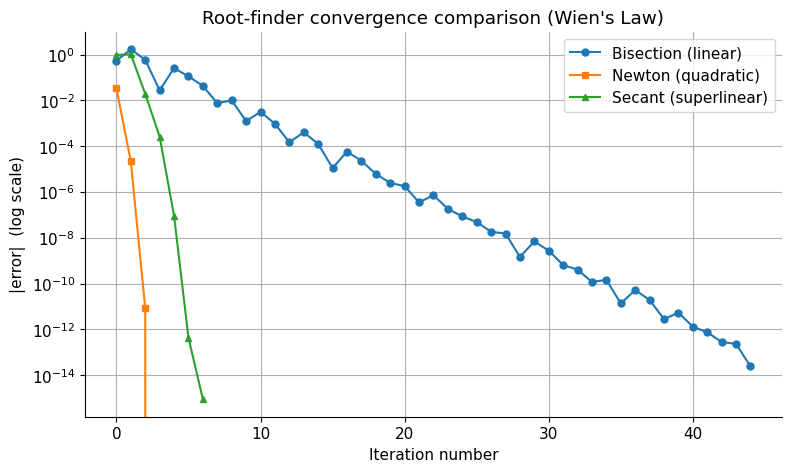


Wien root x* = 4.9651142317
This means: λ_max · T = hc/(k_B · x*) ≈ 2.8980e-03 m·K
→ Red star at 3000 K peaks at 0.97 μm (infrared)
→ Sun  at 5800 K peaks at 0.50 μm (visible)


In [8]:
# Define the Wien transcendental equation: 5(1-e^{-x}) - x = 0
f_wien  = lambda x: 5*(1 - np.exp(-x)) - x
df_wien = lambda x: 5*np.exp(-x) - 1    # analytical derivative

# Apply all three methods and compare
root_b, hist_b = bisection(f_wien, 1, 10)
root_n, hist_n = newton(f_wien, df_wien, 5)
root_s, hist_s = secant(f_wien, 4, 6)

print(f"{'Method':<12} {'Root':>16}  {'Steps':>6}")
print("-" * 38)
print(f"{'Bisection':<12} {root_b:>16.12f}  {len(hist_b):>6}")
print(f"{'Newton':<12} {root_n:>16.12f}  {len(hist_n):>6}")
print(f"{'Secant':<12} {root_s:>16.12f}  {len(hist_s):>6}")

# Convergence rate comparison plot
fig, ax = plt.subplots(figsize=(9, 5))
ref = root_n    # use Newton's answer as the reference truth
ax.semilogy(np.abs(hist_b - ref), "o-", ms=5, label="Bisection (linear)")
ax.semilogy(np.abs(hist_n - ref), "s-", ms=5, label="Newton (quadratic)")
ax.semilogy(np.abs(hist_s - ref), "^-", ms=5, label="Secant (superlinear)")
ax.set_xlabel("Iteration number")
ax.set_ylabel("|error|  (log scale)")
ax.set_title("Root-finder convergence comparison (Wien's Law)")
ax.legend()
plt.show()

# Physical interpretation: compute Wien's constant from the root
b_wien = 2.898e-3   # known constant (m·K)
print(f"\nWien root x* = {root_n:.10f}")
print(f"This means: λ_max · T = hc/(k_B · x*) ≈ {b_wien:.4e} m·K")
print("→ Red star at 3000 K peaks at {:.2f} μm (infrared)".format(b_wien/3000*1e6))
print("→ Sun  at 5800 K peaks at {:.2f} μm (visible)".format(b_wien/5800*1e6))


---
## 3. Numerical Integration

### Why Numerical Integration?

Most integrals that arise in physics cannot be evaluated analytically:

$$\int_0^\infty \frac{x^3}{e^x - 1}\,dx = \frac{\pi^4}{15} \quad \text{(one of the lucky ones!)}$$

For the rest, we must approximate the integral numerically. All basic methods work by replacing the smooth function with a simpler shape (rectangle, trapezoid, parabola) over small sub-intervals and summing the areas.

### Error Analysis Summary

If $f$ is sufficiently smooth and we use $n$ equal sub-intervals of width $h = (b-a)/n$:

| Method | Formula | Error |
|--------|---------|-------|
| Trapezoidal | $\frac{h}{2}(f_0 + 2f_1 + \cdots + 2f_{n-1} + f_n)$ | $O(h^2)$ |
| Simpson's 1/3 | $\frac{h}{3}(f_0 + 4f_1 + 2f_2 + 4f_3 + \cdots + f_n)$ | $O(h^4)$ |
| Gauss–Legendre | Optimal nodes and weights | $O(h^{2p})$ for $p$-point rule |
| Romberg | Richardson extrapolation on trapezoidal | $O(h^{2k})$ |

**Rule of thumb:** Doubling $n$ reduces the trapezoidal error by 4×, and Simpson's by 16×.

### 3.1 The Three Core Integrators


In [9]:
def trap(f, a, b, n):
    """
    Trapezoidal rule: approximates the area under f using n trapezoids.
    Simple and robust; error is O(h^2).
    """
    x = np.linspace(a, b, n+1)   # n+1 points create n sub-intervals
    y = f(x)
    h = (b - a) / n

    # Sum: half-weight the endpoints, full weight for interior points
    return h * (0.5*y[0] + np.sum(y[1:-1]) + 0.5*y[-1])


def simpson(f, a, b, n):
    """
    Simpson's 1/3 rule: fits parabolas through consecutive triples of points.
    Error is O(h^4) — much more accurate than trapezoidal for smooth functions.
    Requires n to be even.
    """
    if n % 2:
        n += 1    # force n to be even (Simpson's rule requires this)

    x = np.linspace(a, b, n+1)
    y = f(x)
    h = (b - a) / n

    # Weights: 1, 4, 2, 4, 2, ..., 4, 1  (alternating 4 and 2 for interior)
    return h/3 * (y[0] + y[-1]
                  + 4*np.sum(y[1:-1:2])   # odd-indexed points get weight 4
                  + 2*np.sum(y[2:-2:2]))   # even-indexed interior get weight 2


def gauss_legendre(f, a, b, n=5):
    """
    Gauss-Legendre quadrature: uses n optimally-placed nodes and weights.
    For smooth functions, n=5 is often as accurate as Simpson with n=1000.
    """
    # Get the Gauss-Legendre nodes (xi) and weights (wi) on [-1, 1]
    xi, wi = np.polynomial.legendre.leggauss(n)

    # Linearly map nodes from [-1, 1] to [a, b]
    xmap = 0.5*(b - a)*xi + 0.5*(b + a)

    return 0.5*(b - a) * np.dot(wi, f(xmap))   # weighted sum


def romberg_int(f, a, b, max_order=6):
    """
    Romberg integration: applies Richardson extrapolation to the trapezoidal rule.
    Builds a triangular table R[k,j] — the bottom-right entry is the best estimate.
    Achieves O(h^{2k}) accuracy.
    """
    R = np.zeros((max_order, max_order))

    for k in range(max_order):
        R[k, 0] = trap(f, a, b, 2**k)    # trapezoidal with 2^k panels
        for j in range(1, k+1):
            # Richardson extrapolation: cancel the leading error term
            R[k, j] = (4**j * R[k, j-1] - R[k-1, j-1]) / (4**j - 1)

    return R[-1, -1], R    # best estimate + full Romberg table


<>:20: SyntaxWarning: invalid escape sequence '\i'
<>:20: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_519/2287936772.py:20: SyntaxWarning: invalid escape sequence '\i'
  plt.title("Integration convergence: $\int_0^1 e^x\,dx$")


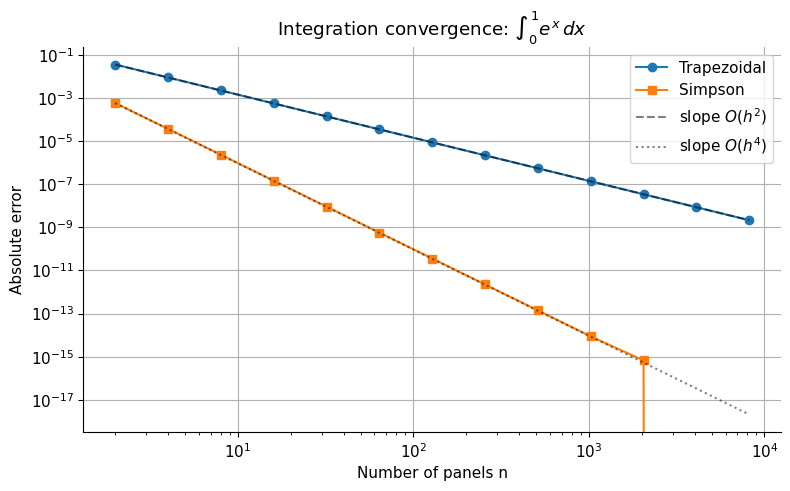

Romberg result : 1.718281828459045
Exact value    : 1.718281828459045
Error          : 2.22e-16

Romberg table (each row is more accurate):
[[1.859141 0.       0.       0.       0.       0.      ]
 [1.753931 1.718861 0.       0.       0.       0.      ]
 [1.727222 1.718319 1.718283 0.       0.       0.      ]
 [1.720519 1.718284 1.718282 1.718282 0.       0.      ]
 [1.718841 1.718282 1.718282 1.718282 1.718282 0.      ]
 [1.718422 1.718282 1.718282 1.718282 1.718282 1.718282]]


In [10]:
# ── Convergence study ──────────────────────────────────────────────────────
# Integrate exp(x) from 0 to 1; exact answer is e - 1 ≈ 1.71828...
f_int = np.exp
exact = np.e - 1

# Panel counts: 2, 4, 8, ..., 8192
ns = 2**np.arange(1, 14)

err_trap = [abs(trap(f_int, 0, 1, n) - exact)    for n in ns]
err_simp = [abs(simpson(f_int, 0, 1, n) - exact) for n in ns]

plt.figure()
plt.loglog(ns, err_trap, "o-", label="Trapezoidal")
plt.loglog(ns, err_simp, "s-", label="Simpson")
# Reference lines showing theoretical slopes
plt.loglog(ns, err_trap[0]*(ns[0]/ns)**2, "k--", alpha=.5, label="slope $O(h^2)$")
plt.loglog(ns, err_simp[0]*(ns[0]/ns)**4, "k:",  alpha=.5, label="slope $O(h^4)$")
plt.xlabel("Number of panels n")
plt.ylabel("Absolute error")
plt.title("Integration convergence: $\int_0^1 e^x\,dx$")
plt.legend()
plt.show()

# ── Romberg table ───────────────────────────────────────────────────────────
rom_val, R = romberg_int(f_int, 0, 1)
print(f"Romberg result : {rom_val:.15f}")
print(f"Exact value    : {exact:.15f}")
print(f"Error          : {abs(rom_val - exact):.2e}")
print("\nRomberg table (each row is more accurate):")
print(np.round(R, 10))


### 3.2 Physics Application — Work Done by a Variable Force

**The physics:**  
Work is the integral of force over displacement. For a force that varies with position:

$$W = \int_{x_1}^{x_2} F(x)\,dx$$

Here we use $F(x) = 3x^2 + \sin(2x)$ N acting over $[0, 3]$ m.  
The exact answer is $\left[x^3 - \frac{1}{2}\cos(2x)\right]_0^3 = 27 - \frac{1}{2}\cos(6) + \frac{1}{2} \approx 27.46$ J.


Work W = ∫₀³ F(x) dx = 27.01991486 J
Exact                 = 27.01991486 J
Error                 = 2.30e-12 J


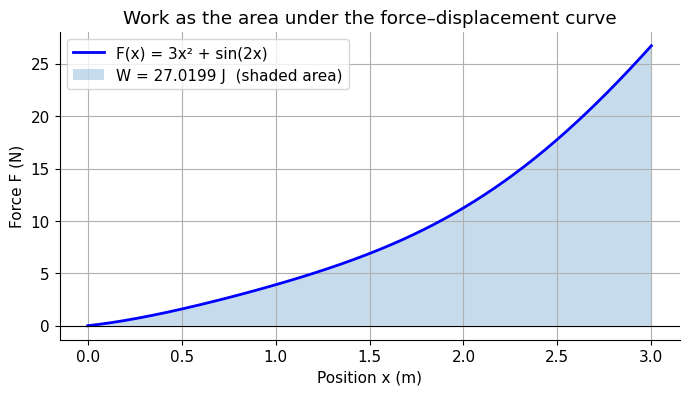

In [11]:
# Force as a function of position
F  = lambda x: 3*x**2 + np.sin(2*x)

# Integrate using Simpson's rule with 500 panels for high accuracy
W  = simpson(F, 0, 3, 500)

# Exact antiderivative: x^3 - (1/2)cos(2x) evaluated at 0 and 3
exact_W = (3**3 - 0.5*np.cos(6)) - (0**3 - 0.5*np.cos(0))
print(f"Work W = ∫₀³ F(x) dx = {W:.8f} J")
print(f"Exact                 = {exact_W:.8f} J")
print(f"Error                 = {abs(W - exact_W):.2e} J")

# Visualise: the work is the shaded area under the force curve
x_plot = np.linspace(0, 3, 500)
plt.figure(figsize=(8, 4))
plt.plot(x_plot, F(x_plot), "b", lw=2, label="F(x) = 3x² + sin(2x)")
plt.fill_between(x_plot, F(x_plot), alpha=0.25,
                 label=f"W = {W:.4f} J  (shaded area)")
plt.axhline(0, color="k", lw=0.8)
plt.xlabel("Position x (m)")
plt.ylabel("Force F (N)")
plt.title("Work as the area under the force–displacement curve")
plt.legend()
plt.show()


---
## 4. Linear Algebra & Eigenvalue Problems

### Why Linear Algebra in Physics?

Almost every physics problem eventually reduces to solving a linear system $A\mathbf{x} = \mathbf{b}$ or finding eigenvalues $A\mathbf{v} = \lambda\mathbf{v}$.  Examples:

- **Circuit analysis:** Kirchhoff's laws → resistor matrix equation
- **Normal modes:** Mass–spring system → eigenvalue problem
- **Quantum mechanics:** Hamiltonian eigenvalues = energy levels
- **Finite-element methods:** PDE discretisation → sparse linear system
- **Data compression:** SVD identifies the most important "directions" in data

### 4.1 Direct Solvers — Resistor Network

We analyse a three-loop resistor network using **mesh analysis** (Kirchhoff's voltage law). Each loop gives one equation; together they form $A\mathbf{I} = \mathbf{V}$ where $\mathbf{I}$ is the vector of loop currents.


In [12]:
# Resistance matrix from Kirchhoff's voltage law (3 mesh loops)
# A[i,j] = sum of resistances in loop i if i==j
#         = -shared resistance between loops i and j if i!=j
A = np.array([[ 9., -2.,  0.],
              [-2.,  7., -1.],
              [ 0., -1.,  4.]])

# Source voltage vector (volts)
b_vec = np.array([10., 3., 5.])

# Solve: np.linalg.solve uses LU decomposition internally — very fast
x_sol = np.linalg.solve(A, b_vec)
print("Mesh currents (A):", x_sol)

# Verify: A @ x should equal b
residual = np.linalg.norm(A @ x_sol - b_vec)
print(f"Residual ||Ax - b|| = {residual:.2e}  (should be near machine epsilon)")

# Condition number: κ(A) >> 1 means the system is ill-conditioned
# (small changes in b cause large changes in x)
cond = np.linalg.cond(A)
print(f"Condition number κ(A) = {cond:.4f}  (well-conditioned since κ is small)")


Mesh currents (A): [1.339207 1.026432 1.506608]
Residual ||Ax - b|| = 1.83e-15  (should be near machine epsilon)
Condition number κ(A) = 2.8396  (well-conditioned since κ is small)


### 4.2 Matrix Decompositions: LU, QR, SVD

**Why decompose a matrix?**

| Decomposition | $A = $ | Best for |
|--------------|--------|---------|
| **LU** | $LU$ (lower × upper triangular) | Solving $Ax=b$ efficiently |
| **QR** | $QR$ (orthogonal × upper triangular) | Least-squares problems |
| **SVD** | $U\Sigma V^T$ (singular value decomp.) | Low-rank approximation, PCA, pseudoinverse |

The **SVD** is especially powerful. The singular values $\sigma_1 \geq \sigma_2 \geq \cdots \geq 0$ reveal the "effective rank" of a matrix. Discarding small singular values gives the best low-rank approximation (Eckart–Young theorem).


In [13]:
from numpy.linalg import svd, qr

# Create a random 8×6 matrix to demonstrate decompositions
M = rng.standard_normal((8, 6))

# ── SVD ─────────────────────────────────────────────────────────────────────
# M = U @ diag(s) @ Vt where U (8×6), s (6,), Vt (6×6) are orthogonal/diagonal
U, s, Vt = svd(M, full_matrices=False)

print("Singular values:", np.round(s, 4))
print(f"Rank-1 approximation (keeping only largest singular value):")

# Low-rank approximation: use only the first k singular values
for k in [1, 2, 3]:
    M_approx = (U[:, :k] * s[:k]) @ Vt[:k, :]   # outer product sum
    err = np.linalg.norm(M - M_approx, 'fro')     # Frobenius norm
    print(f"  k={k}: approximation error = {err:.4f}")

# ── QR ──────────────────────────────────────────────────────────────────────
Q, R_mat = qr(M)

# Orthogonality check: Q^T Q should be the identity matrix
ortho_err = np.linalg.norm(Q.T @ Q - np.eye(6))
print(f"\nQR: ||QᵀQ - I|| = {ortho_err:.2e}  (machine-precision orthogonality)")


Singular values: [3.7861 2.5567 2.3417 1.1002 0.9943 0.5641]
Rank-1 approximation (keeping only largest singular value):
  k=1: approximation error = 3.8128
  k=2: approximation error = 2.8286
  k=3: approximation error = 1.5866

QR: ||QᵀQ - I|| = 1.24e-15  (machine-precision orthogonality)


### 4.3 Eigenvalue Problems — Normal Modes of Coupled Oscillators

**The physics:**  
Two masses connected by springs have special motions called **normal modes** where both masses oscillate at the *same* frequency. Finding these modes requires solving:

$$(K - \omega^2 M)\mathbf{v} = 0$$

For equal masses $m=1$, this simplifies to the eigenvalue problem $K\mathbf{v} = \omega^2\mathbf{v}$.

The **two normal mode frequencies** correspond to:
- **Mode 1 (symmetric):** Both masses move together — lower frequency
- **Mode 2 (antisymmetric):** Masses move opposite — higher frequency


Normal-mode analysis of two coupled oscillators:
Mode      ω (rad/s)      f (Hz)  Mode shape (v₁, v₂)
-------------------------------------------------------
1          1.000000    0.159155  (-0.7071, -0.7071)
2          1.414214    0.225079  (-0.7071, +0.7071)


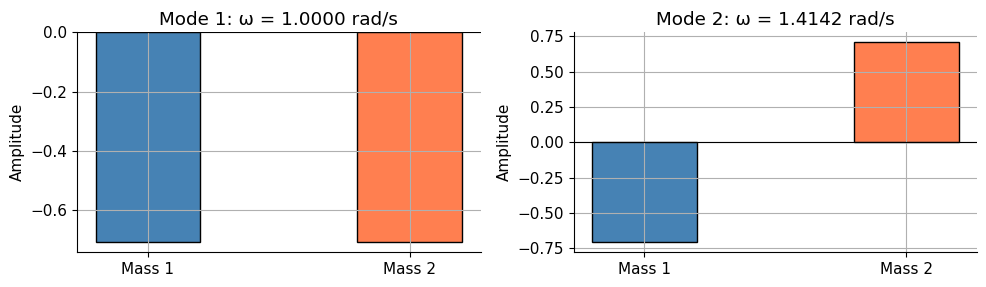

In [14]:
m = 1.0                      # mass (kg)
k1, k12, k2 = 1.0, 0.5, 1.0  # spring constants (N/m)

# Stiffness matrix: derived from F = -dV/dx for each mass
# Diagonal: total spring constant on that mass
# Off-diagonal: -k12 (the coupling spring)
K = np.array([[ k1+k12,  -k12 ],
              [ -k12,   k2+k12]]) / m

# eigh: for symmetric/Hermitian matrices → guaranteed real eigenvalues
# Returns eigenvalues in ascending order with corresponding eigenvectors
evals, evecs = np.linalg.eigh(K)
omegas = np.sqrt(evals)   # angular frequencies ω = sqrt(λ)

print("Normal-mode analysis of two coupled oscillators:")
print(f"{'Mode':<6} {'ω (rad/s)':>12}  {'f (Hz)':>10}  {'Mode shape (v₁, v₂)'}")
print("-" * 55)
for i, (w, v) in enumerate(zip(omegas, evecs.T)):
    print(f"{i+1:<6} {w:>12.6f}  {w/(2*np.pi):>10.6f}  ({v[0]:+.4f}, {v[1]:+.4f})")

# Visualise mode shapes as bar charts
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for i, ax in enumerate(axes):
    ax.bar([0, 1], evecs[:, i],
           color=["steelblue", "coral"], width=0.4, edgecolor="k")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Mass 1", "Mass 2"])
    ax.set_title(f"Mode {i+1}: ω = {omegas[i]:.4f} rad/s")
    ax.set_ylabel("Amplitude")
    ax.axhline(0, color="k", lw=0.8)
plt.tight_layout()
plt.show()


### 4.4 Poisson Equation via Finite Differences

**The physics:**  
Poisson's equation describes electrostatic potential $\phi$ given a charge distribution $\rho$:

$$\frac{d^2\phi}{dx^2} = -\rho(x), \quad \phi(0) = \phi(1) = 0$$

**The method — finite differences:**  
Replace the second derivative with a finite-difference stencil:

$$\frac{\phi_{i+1} - 2\phi_i + \phi_{i-1}}{h^2} \approx \phi''_i$$

Applying this at every interior grid point turns the differential equation into a linear system $A\boldsymbol{\phi} = -\boldsymbol{\rho}$ with a **tridiagonal** matrix $A$. Tridiagonal systems can be solved in $O(N)$ time.


<>:21: SyntaxWarning: invalid escape sequence '\p'
<>:24: SyntaxWarning: invalid escape sequence '\p'
<>:21: SyntaxWarning: invalid escape sequence '\p'
<>:24: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_519/4060967383.py:21: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(x_p, phi_exact, "k--",   label="Exact: $\phi=\sin(\pi x)/\pi^2$")
/tmp/ipykernel_519/4060967383.py:24: SyntaxWarning: invalid escape sequence '\p'
  plt.title("Poisson equation: $\phi'' = -\sin(\pi x)$")


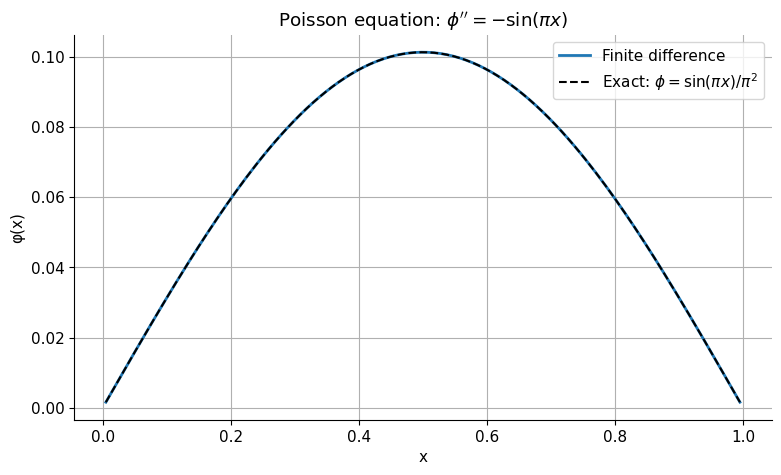

Max error = 2.06e-06  (theory: O(h²) ≈ 2.48e-05)


In [38]:
N    = 200                                         # number of interior points
x_p  = np.linspace(0, 1, N+2)[1:-1]               # interior grid (excludes boundaries)
h_p  = x_p[1] - x_p[0]                            # grid spacing
rho  = np.sin(np.pi * x_p)                        # charge density source term

# Build the N×N tridiagonal second-derivative matrix D²
# Main diagonal: -2/h² (from the central finite difference)
# Off-diagonals: +1/h² (neighbours)
diag = -2 * np.ones(N) / h_p**2
off  =      np.ones(N-1) / h_p**2
A_p  = np.diag(diag) + np.diag(off, 1) + np.diag(off, -1)

# Solve the system: A_p @ phi = -rho (negative sign from Poisson equation)
phi_sol   = np.linalg.solve(A_p, -rho)

# Analytic solution for rho = sin(πx): phi(x) = sin(πx)/π²
phi_exact = np.sin(np.pi * x_p) / np.pi**2

plt.figure()
plt.plot(x_p, phi_sol,    lw=2,   label="Finite difference")
plt.plot(x_p, phi_exact, "k--",   label="Exact: $\phi=\sin(\pi x)/\pi^2$")
plt.xlabel("x")
plt.ylabel("φ(x)")
plt.title("Poisson equation: $\phi'' = -\sin(\pi x)$")
plt.legend()
plt.show()

print(f"Max error = {np.max(np.abs(phi_sol - phi_exact)):.2e}  "
      f"(theory: O(h²) ≈ {h_p**2:.2e})")


---
## 5. Ordinary Differential Equation (ODE) Solvers

###

An ODE is any equation of the form $\dot{\mathbf{y}} = f(t, \mathbf{y})$ with initial condition  
$\mathbf{y}(t_0) = \mathbf{y}_0$. Virtually every dynamical system in physics is described this way:

- Newton's second law: $m\ddot{x} = F(x)$ → rewrite as a first-order system
- Population dynamics, orbital mechanics, circuit voltage, heat flow...

**Reducing to first order:**  
The damped oscillator $\ddot{x} + 2\beta\dot{x} + \omega^2 x = 0$ becomes:

$$\frac{d}{dt}\begin{pmatrix}x\\v\end{pmatrix} = \begin{pmatrix}v\\ -2\beta v - \omega^2 x\end{pmatrix}$$

A 2nd-order ODE becomes two coupled 1st-order ODEs — **always do this!**

### Accuracy & Stability

| Method | Local error | Global error | Stability |
|--------|------------|-------------|----------|
| Euler | $O(h^2)$ | $O(h)$ | Conditionally stable |
| Midpoint (RK2) | $O(h^3)$ | $O(h^2)$ | Better |
| RK4 | $O(h^5)$ | $O(h^4)$ | Very good |
| Adaptive RK45 | automatic | user-specified | Excellent |

### 5.1 Three Fixed-Step Integrators


In [16]:
def euler(f, t, y0):
    """
    Euler method: simplest ODE integrator.
    Approximates: y(t+h) ≈ y(t) + h * f(t, y(t))
    Error grows as O(h) — needs tiny h for good accuracy.
    """
    y = np.zeros((len(t), len(y0)))
    y[0] = y0

    for n in range(len(t) - 1):
        dt = t[n+1] - t[n]
        y[n+1] = y[n] + dt * f(t[n], y[n])   # forward step

    return y


def midpoint(f, t, y0):
    """
    Midpoint method (2nd-order Runge-Kutta).
    Better than Euler: uses derivative estimate at the midpoint of the step.
    Error is O(h²).
    """
    y = np.zeros((len(t), len(y0)))
    y[0] = y0

    for n in range(len(t) - 1):
        dt = t[n+1] - t[n]
        k1 = f(t[n], y[n])                         # slope at start
        y[n+1] = y[n] + dt * f(t[n] + dt/2,
                                y[n] + dt/2 * k1)   # step using midpoint slope

    return y


def rk4(f, t, y0):
    """
    Classical 4th-order Runge-Kutta method.
    The standard workhorse for most ODE problems.
    Uses 4 derivative evaluations per step; error is O(h^4).
    """
    y = np.zeros((len(t), len(y0)))
    y[0] = y0

    for n in range(len(t) - 1):
        dt = t[n+1] - t[n]
        k1 = f(t[n],        y[n])             # slope at start
        k2 = f(t[n]+dt/2,   y[n]+dt/2*k1)    # slope at midpoint (using k1)
        k3 = f(t[n]+dt/2,   y[n]+dt/2*k2)    # slope at midpoint (using k2)
        k4 = f(t[n]+dt,     y[n]+dt*k3)       # slope at end

        # Weighted average: 1/6, 1/3, 1/3, 1/6
        y[n+1] = y[n] + dt/6 * (k1 + 2*k2 + 2*k3 + k4)

    return y


### 5.2 Physics Application — Damped Harmonic Oscillator

**The physics:**  
A spring-mass system with damping (e.g., a mass on a spring in oil):

$$m\ddot{x} + c\dot{x} + kx = 0$$

Dividing by $m$ and defining $\beta = c/(2m)$, $\omega_0 = \sqrt{k/m}$:

$$\ddot{x} + 2\beta\dot{x} + \omega_0^2 x = 0$$

**Underdamped case** ($\beta < \omega_0$): decaying oscillations with frequency $\omega_d = \sqrt{\omega_0^2 - \beta^2}$. <br />
Exact solution:

$$x(t) = e^{-\beta t}\cos(\omega_d t)$$


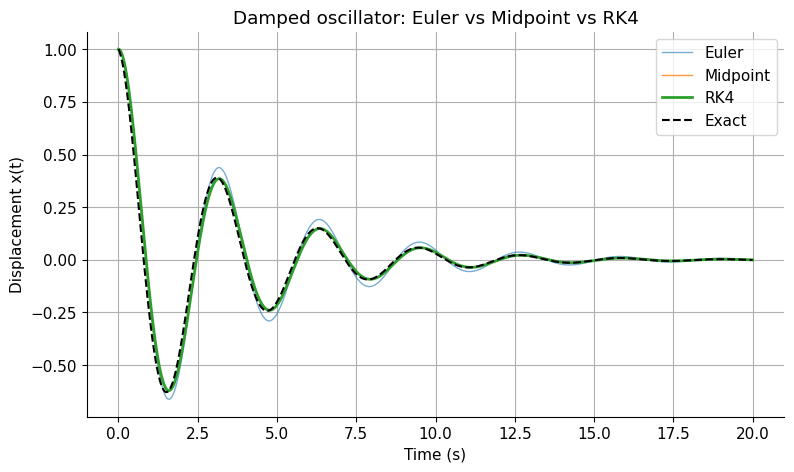

Max absolute errors over the trajectory:
  Euler   : 0.1233
  Midpoint: 0.120610
  RK4     : 0.12092265


In [17]:
omega = 2.0   # natural frequency ω₀ (rad/s)
beta  = 0.3   # damping coefficient β (s⁻¹)

def osc_rhs(t, y):
    """Right-hand side of damped oscillator as a first-order system."""
    x, v = y
    return np.array([
        v,                          # dx/dt = v
        -2*beta*v - omega**2*x      # dv/dt = -2βv - ω²x
    ])

t_span = np.linspace(0, 20, 1000)   # 20 seconds, 1000 time steps
y0     = np.array([1.0, 0.0])        # start at x=1, v=0 (stretched, released)

# Integrate with each method
y_euler  = euler(osc_rhs,   t_span, y0)
y_mid    = midpoint(osc_rhs, t_span, y0)
y_rk4    = rk4(osc_rhs,     t_span, y0)

# Analytic solution for comparison
wd      = np.sqrt(omega**2 - beta**2)   # damped natural frequency
y_exact = np.exp(-beta*t_span) * np.cos(wd*t_span)

# ── Plot: solutions ──────────────────────────────────────────────────────────
plt.figure()
plt.plot(t_span, y_euler[:,0], alpha=0.6, lw=1, label="Euler")
plt.plot(t_span, y_mid[:,0],   alpha=0.8, lw=1, label="Midpoint")
plt.plot(t_span, y_rk4[:,0],   lw=2,            label="RK4")
plt.plot(t_span, y_exact,      "k--", lw=1.5,   label="Exact")
plt.xlabel("Time (s)")
plt.ylabel("Displacement x(t)")
plt.title("Damped oscillator: Euler vs Midpoint vs RK4")
plt.legend()
plt.show()

# ── Error comparison ─────────────────────────────────────────────────────────
print("Max absolute errors over the trajectory:")
print(f"  Euler   : {np.max(np.abs(y_euler[:,0]  - y_exact)):.4f}")
print(f"  Midpoint: {np.max(np.abs(y_mid[:,0]    - y_exact)):.6f}")
print(f"  RK4     : {np.max(np.abs(y_rk4[:,0]    - y_exact)):.8f}")


### 5.3 Adaptive Step-Size Control (RK45)

**The problem with fixed step-size:** Some regions of the solution need a small $h$ (fast dynamics, sharp features), while others could use a large $h$ (slow, smooth regions). A fixed step-size is wasteful — you're either over-working or under-performing.

**Adaptive methods:** Automatically adjust $h$ to maintain a user-specified error tolerance.  

The **Dormand–Prince (RK45)** method estimates the local error by comparing a 4th-order and 5th-order solution. If the error is too large, shrink $h$; if too small, grow $h$.

> 💡 For most practical problems, just use `scipy.integrate.solve_ivp` with `method='RK45'`.


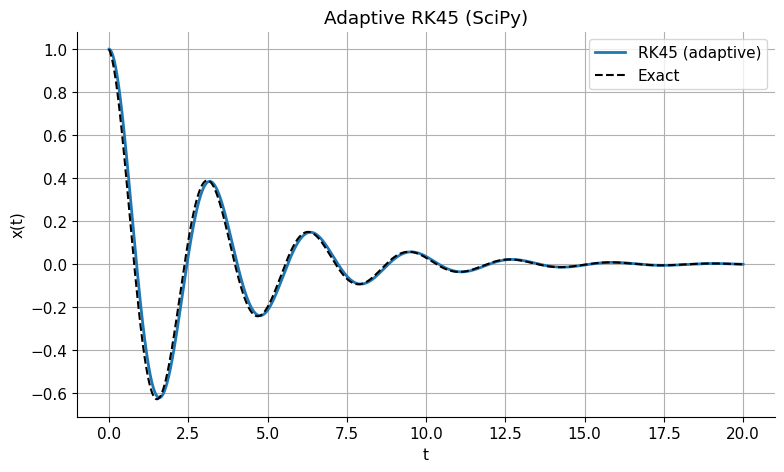

Total function evaluations: 4568  (fixed RK4 with 1000 steps used 4000)
Accepted steps: 748  (adaptive — only as many as needed)


In [18]:
if SCIPY_AVAILABLE:
    # solve_ivp: modern SciPy ODE solver interface
    sol = integrate.solve_ivp(
        osc_rhs,              # function f(t, y)
        [0, 20],              # time span [t_start, t_end]
        y0,                   # initial condition
        method="RK45",        # Dormand-Prince adaptive method
        dense_output=True,    # allows evaluation at any t via sol.sol(t)
        rtol=1e-9,            # relative tolerance: error / |y| < rtol
        atol=1e-12            # absolute tolerance: backup for near-zero y
    )

    t_dense = np.linspace(0, 20, 2000)
    y_dense = sol.sol(t_dense)    # evaluate the dense solution

    plt.figure()
    plt.plot(t_dense, y_dense[0],
             label="RK45 (adaptive)", lw=2)
    plt.plot(t_dense, np.exp(-beta*t_dense)*np.cos(wd*t_dense),
             "k--", label="Exact", lw=1.5)
    plt.title("Adaptive RK45 (SciPy)")
    plt.xlabel("t")
    plt.ylabel("x(t)")
    plt.legend()
    plt.show()

    print(f"Total function evaluations: {sol.nfev}  (fixed RK4 with 1000 steps used 4000)")
    print(f"Accepted steps: {sol.t.size}  (adaptive — only as many as needed)")
else:
    print("SciPy not available — skipping adaptive RK45 demo")


---
## 6. Planetary Orbits & Symplectic Integrators

### The Equations of Motion

Newton's law of gravitation gives:

$$\ddot{\mathbf{r}} = -\frac{GM}{r^3}\mathbf{r}$$

In 2-D with $GM = 1$ (natural units), this becomes four coupled first-order ODEs:

$$\dot{x} = v_x, \quad \dot{y} = v_y, \quad \dot{v}_x = -\frac{x}{r^3}, \quad \dot{v}_y = -\frac{y}{r^3}$$

### Why Not Just Use RK4?

Orbital mechanics is a **Hamiltonian system** — it conserves energy exactly. RK4 is a *dissipative* method that introduces a tiny spurious energy loss each step. Over many orbits, this accumulates into a secular drift: the orbit slowly spirals inward or outward.

**Symplectic integrators** preserve the mathematical structure of Hamiltonian systems (specifically, the symplectic 2-form $dq\wedge dp$). They don't conserve energy exactly, but the energy error *oscillates* around zero rather than drifting — bounded forever.

### Velocity Verlet Algorithm

Also known as Störmer–Verlet. Each step:
1. **Half-kick:** $\mathbf{v}_{n+1/2} = \mathbf{v}_n + \frac{h}{2}\mathbf{a}_n$
2. **Drift:**     $\mathbf{r}_{n+1} = \mathbf{r}_n + h\mathbf{v}_{n+1/2}$
3. **Full kick:** $\mathbf{v}_{n+1} = \mathbf{v}_{n+1/2} + \frac{h}{2}\mathbf{a}_{n+1}$

Cost: same as Euler (1 force evaluation per step), but 2nd-order and **symplectic**.


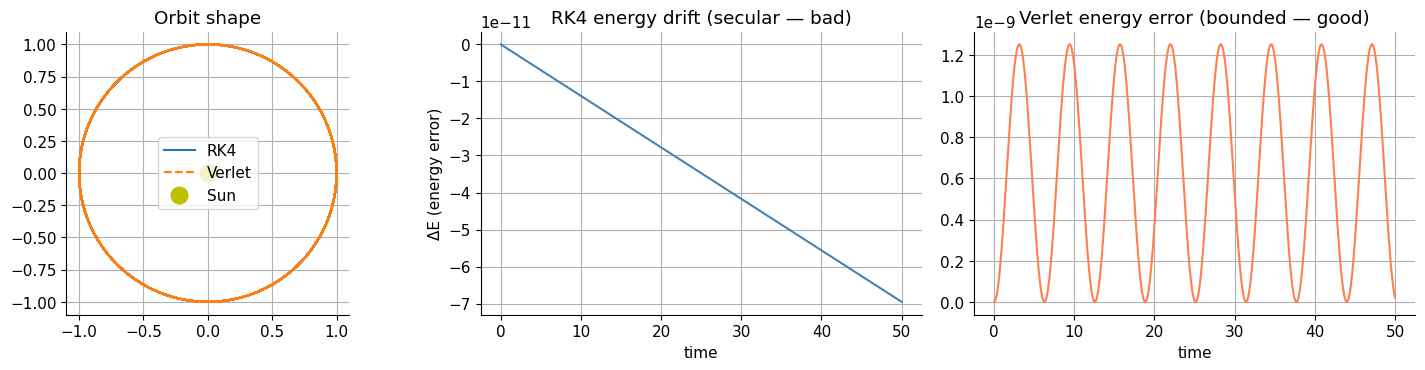

In [19]:
mu = 1.0   # GM = 1 in natural units

def orbit_rhs(t, Y):
    """Right-hand side for Kepler orbit (for use with RK4)."""
    x, y, vx, vy = Y
    r   = np.sqrt(x**2 + y**2)       # distance from origin
    fac = -mu / r**3                  # -GM/r³
    return np.array([vx, vy, fac*x, fac*y])

def energy(Y):
    """Specific orbital energy E = KE + PE = v²/2 - GM/r."""
    x, y, vx, vy = Y.T if Y.ndim == 2 else Y
    r = np.sqrt(x**2 + y**2)
    return 0.5*(vx**2 + vy**2) - mu/r

def velocity_verlet(t, Y0):
    """
    Symplectic Velocity-Verlet integrator for Kepler orbit.
    Energy error is bounded (oscillates), not secular (drifting).
    """
    N = len(t)
    Y = np.zeros((N, 4))
    Y[0] = Y0

    for n in range(N - 1):
        dt = t[n+1] - t[n]
        x, y, vx, vy = Y[n]

        # Compute acceleration at current position
        r   = np.sqrt(x**2 + y**2)
        ax  = -mu*x/r**3
        ay  = -mu*y/r**3

        # Step 1: half velocity kick (use old acceleration)
        vx_h = vx + 0.5*dt*ax
        vy_h = vy + 0.5*dt*ay

        # Step 2: full position drift (use half-step velocity)
        x_n  = x + dt*vx_h
        y_n  = y + dt*vy_h

        # Step 3: full velocity kick using NEW position's acceleration
        r_n  = np.sqrt(x_n**2 + y_n**2)
        ax_n = -mu*x_n/r_n**3
        ay_n = -mu*y_n/r_n**3
        vx_n = vx_h + 0.5*dt*ax_n
        vy_n = vy_h + 0.5*dt*ay_n

        Y[n+1] = [x_n, y_n, vx_n, vy_n]

    return Y

# Initial conditions for a circular orbit at radius r0
r0  = 1.0
Y0  = np.array([r0, 0.0, 0.0, np.sqrt(mu/r0)])   # v = sqrt(GM/r) for circle

t_  = np.linspace(0, 50, 5000)   # 50 time units ≈ ~8 orbital periods

Y_rk4 = rk4(orbit_rhs, t_, Y0)
Y_vv  = velocity_verlet(t_, Y0)

E_rk4 = energy(Y_rk4)
E_vv  = energy(Y_vv)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Orbit shape
axes[0].plot(Y_rk4[:,0], Y_rk4[:,1], label="RK4")
axes[0].plot(Y_vv[:,0],  Y_vv[:,1],  ls="--", label="Verlet")
axes[0].plot(0, 0, "yo", ms=12, label="Sun")
axes[0].set_aspect("equal")
axes[0].set_title("Orbit shape")
axes[0].legend()

# RK4 energy: shows secular drift (orbit slowly changes)
axes[1].plot(t_, E_rk4 - E_rk4[0], color="steelblue")
axes[1].set_title("RK4 energy drift (secular — bad)")
axes[1].set_xlabel("time")
axes[1].set_ylabel("ΔE (energy error)")

# Verlet energy: bounded oscillations (no secular drift)
axes[2].plot(t_, E_vv - E_vv[0], color="coral")
axes[2].set_title("Verlet energy error (bounded — good)")
axes[2].set_xlabel("time")

plt.tight_layout()
plt.show()


### 6.2 Kepler's Third Law Verification

**Kepler's Third Law:** The square of the orbital period is proportional to the cube of the semi-major axis:

$$T^2 \propto a^3 \quad \Rightarrow \quad T = 2\pi a^{3/2} \quad (\text{with } GM=1)$$

We verify this numerically by simulating orbits at different radii and measuring the period.


<>:26: SyntaxWarning: invalid escape sequence '\p'
<>:26: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_519/96265636.py:26: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(radii, T_theory, "-",       label="Kepler: $T = 2\pi a^{3/2}$")


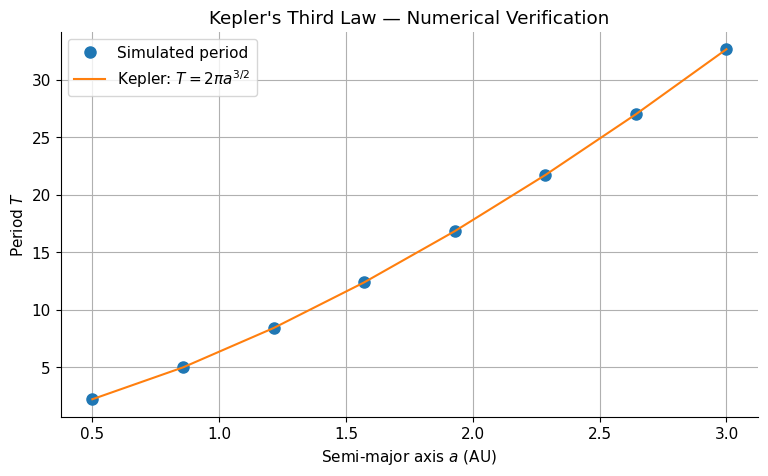

T²/a³ for each orbit (should all equal (2π)² ≈ 39.48):
[39.48 39.48 39.48 39.48 39.48 39.48 39.48 39.48]


In [20]:
radii   = np.linspace(0.5, 3.0, 8)   # range of orbital radii
periods = []

for r0 in radii:
    # Circular orbit initial conditions at each radius
    Y0_k = np.array([r0, 0.0, 0.0, np.sqrt(mu/r0)])

    T_guess = 2*np.pi*r0**1.5 * 1.2   # theoretical period × 1.2 safety factor
    t_k = np.linspace(0, T_guess, 8000)
    Yk  = velocity_verlet(t_k, Y0_k)

    # Find the period: first time y crosses zero from above after half an orbit
    # (skip the first 1000 points to avoid the initial condition)
    sign_change = np.where(np.diff(np.sign(Yk[1000:, 1])))[0]
    if len(sign_change):
        T_num = t_k[1000 + sign_change[0] + 1] * 2   # half-period × 2
    else:
        T_num = T_guess
    periods.append(T_num)

periods  = np.array(periods)
T_theory = 2*np.pi * radii**1.5    # Kepler's prediction

plt.figure()
plt.plot(radii, periods,  "o", ms=8, label="Simulated period")
plt.plot(radii, T_theory, "-",       label="Kepler: $T = 2\pi a^{3/2}$")
plt.xlabel("Semi-major axis $a$ (AU)")
plt.ylabel("Period $T$")
plt.title("Kepler's Third Law — Numerical Verification")
plt.legend()
plt.show()

# Check: T²/a³ should be constant = (2π)²
ratio = periods**2 / radii**3
print("T²/a³ for each orbit (should all equal (2π)² ≈ 39.48):")
print(np.round(ratio, 3))


---
## 7. Atmospheric Parcel Model

### What is a Parcel Model?

An **atmospheric parcel** is an imaginary blob of air that we track as it moves up or down through the atmosphere, assuming it doesn't mix with surrounding air (adiabatic). This model explains thunderstorms, fair-weather cumulus clouds, and atmospheric stability.

### Key Concepts

**Dry adiabatic lapse rate** $\Gamma_d$:  
As a parcel rises, it expands and cools. Without condensation:

$$\Gamma_d = \frac{g}{c_p} \approx 9.8\,\text{K km}^{-1}$$

**Moist adiabatic lapse rate** $\Gamma_m$:  
Once water vapour condenses (releasing latent heat), cooling is slower:

$$\Gamma_m \approx 6\,\text{K km}^{-1}$$

**Buoyancy** — the key to convection:  
A parcel that is warmer than its environment feels an upward buoyant force:

$$B = g \frac{T_p - T_e}{T_e}$$

If $T_p > T_e$: parcel is buoyant → rises → convection (thunderstorms!)  
If $T_p < T_e$: parcel is negatively buoyant → sinks back → stable atmosphere

**Equations of motion:**
$$\dot{z} = w, \qquad \dot{w} = B - c_d w, \qquad \dot{T}_p = -\Gamma w$$


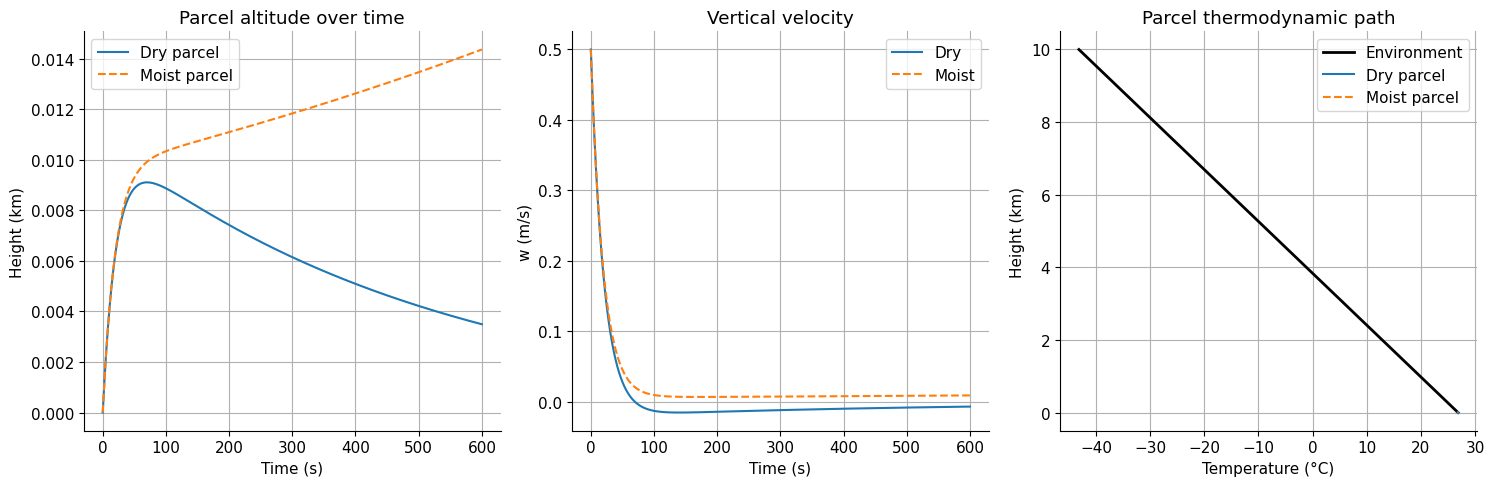

In [21]:
from functools import partial

g     = 9.81     # gravitational acceleration (m/s²)
cp    = 1004.0   # specific heat of air at constant pressure (J/kg/K)
Gamma_d = g / cp          # dry adiabatic lapse rate ≈ 9.8 K/km
Gamma_m = 6.0e-3          # moist adiabatic lapse rate ≈ 6 K/km
cd      = 0.05            # drag coefficient (s⁻¹)

# Environment: 7 K/km lapse rate (between Γ_d and Γ_m → conditionally unstable)
T_sfc = 300.0                             # surface temperature (K)
T_e   = lambda z: T_sfc - 7e-3 * z       # environment temperature vs height

def parcel_rhs(t, state, moist=False):
    """
    Equations of motion for an adiabatic parcel.
    State vector: [z (height m), w (vertical velocity m/s), Tp (parcel temp K)]
    """
    z, w, Tp = state
    Gamma_p = Gamma_m if moist else Gamma_d   # cooling rate depends on regime
    Te = T_e(z)                               # environment temperature at this height
    B  = g * (Tp - Te) / Te                   # buoyancy force per unit mass

    dz  = w                    # height changes at rate w
    dw  = B - cd*w             # acceleration = buoyancy - drag
    dTp = -Gamma_p * w         # parcel cools as it rises (or warms as it sinks)

    return np.array([dz, dw, dTp])

t_parcel  = np.linspace(0, 600, 3000)          # 10-minute simulation
y0_parcel = np.array([0.0, 0.5, T_sfc])        # start at surface, slight upward nudge

# Solve for dry and moist cases
sol_dry   = rk4(partial(parcel_rhs, moist=False), t_parcel, y0_parcel)
sol_moist = rk4(partial(parcel_rhs, moist=True),  t_parcel, y0_parcel)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Height vs time
axes[0].plot(t_parcel, sol_dry[:,0]/1e3,   label="Dry parcel")
axes[0].plot(t_parcel, sol_moist[:,0]/1e3, label="Moist parcel", ls="--")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Height (km)")
axes[0].set_title("Parcel altitude over time")
axes[0].legend()

# Vertical velocity
axes[1].plot(t_parcel, sol_dry[:,1],   label="Dry")
axes[1].plot(t_parcel, sol_moist[:,1], label="Moist", ls="--")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("w (m/s)")
axes[1].set_title("Vertical velocity")
axes[1].legend()

# Thermodynamic diagram (temperature vs height)
z_grid = np.linspace(0, 10e3, 200)
axes[2].plot(T_e(z_grid)-273.15, z_grid/1e3, "k-", lw=2, label="Environment")
axes[2].plot(sol_dry[:,2]-273.15,   sol_dry[:,0]/1e3,  label="Dry parcel")
axes[2].plot(sol_moist[:,2]-273.15, sol_moist[:,0]/1e3,label="Moist parcel", ls="--")
axes[2].set_xlabel("Temperature (°C)")
axes[2].set_ylabel("Height (km)")
axes[2].set_title("Parcel thermodynamic path")
axes[2].legend()

plt.tight_layout()
plt.show()


---
## 8. Diffusion Equation

### Physical Background

The diffusion (or heat) equation describes how a quantity spreads out over time:

$$\frac{\partial u}{\partial t} = \kappa\,\frac{\partial^2 u}{\partial x^2}$$

Here $u(x,t)$ could be temperature, concentration of a pollutant, or probability density. $\kappa$ is the **diffusivity** (or thermal conductivity divided by density and specific heat).

**Physical intuition:** The Laplacian $\partial^2 u/\partial x^2$ is positive at a valley (concentration lower than neighbours) and negative at a peak.  
The equation says: "fill in the valleys, smooth out the peaks."

### Numerical Schemes

We discretise space onto a grid $x_i = i\,\Delta x$ and advance in time steps $\Delta t$.

**Explicit (FTCS):** Forward time, centred space.
$$U_i^{n+1} = U_i^n + r\left(U_{i+1}^n - 2U_i^n + U_{i-1}^n\right), \quad r = \frac{\kappa\Delta t}{\Delta x^2}$$

**Stability condition:** $r \leq 0.5$ — if $r > 0.5$ the solution blows up exponentially! This limits $\Delta t \leq \frac{\Delta x^2}{2\kappa}$, which can be very small.

**Implicit (Crank–Nicolson):** Average of explicit and implicit finite differences.  

**Unconditionally stable** — any $\Delta t$ works (though accuracy still requires reasonable $\Delta t$).

### 8.1 Explicit Scheme


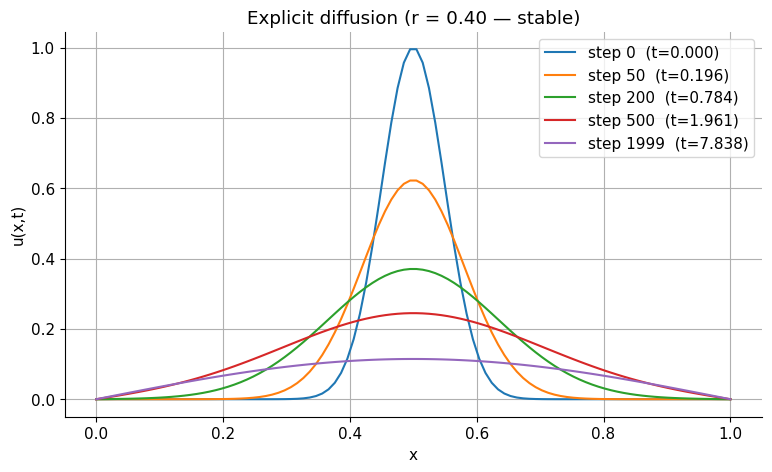

Time step Δt = 0.00392 s  (must keep r = 0.40 < 0.5)


In [22]:
kappa = 0.01   # diffusivity
Nx    = 100    # spatial grid points
x_d   = np.linspace(0, 1, Nx+2)          # grid including boundaries
dx    = x_d[1] - x_d[0]                  # grid spacing
dt_d  = 0.4 * dx**2 / kappa              # time step: r = 0.4 < 0.5 (stable)
r_d   = kappa * dt_d / dx**2             # stability parameter

# Initial condition: Gaussian hump centred at x = 0.5
u0_d = np.exp(-((x_d - 0.5)**2) / (2*0.05**2))
u0_d[[0, -1]] = 0.0    # Dirichlet boundary conditions: u = 0 at both ends

U_exp   = u0_d.copy()
snap_exp   = [U_exp.copy()]
snap_steps = [0, 50, 200, 500, 1999]

for n in range(2000):
    # Apply FTCS stencil to all interior points simultaneously
    U_exp[1:-1] += r_d * (U_exp[2:] - 2*U_exp[1:-1] + U_exp[:-2])
    U_exp[[0, -1]] = 0.0   # enforce boundary conditions each step

    if n+1 in snap_steps:
        snap_exp.append(U_exp.copy())

plt.figure()
for s, n_step in zip(snap_exp, snap_steps):
    plt.plot(x_d, s, label=f"step {n_step}  (t={n_step*dt_d:.3f})")
plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title(f"Explicit diffusion (r = {r_d:.2f} — stable)")
plt.legend()
plt.show()

print(f"Time step Δt = {dt_d:.5f} s  (must keep r = {r_d:.2f} < 0.5)")


### 8.2 Crank–Nicolson Implicit Scheme

**Why implicit?**  
The explicit scheme becomes unstable for large $\Delta t$. We need small steps → many iterations. The Crank–Nicolson (CN) scheme averages the explicit and implicit treatments:

$$\frac{U_i^{n+1} - U_i^n}{\Delta t} = \frac{\kappa}{2}\left(\delta^2 U^n + \delta^2 U^{n+1}\right)$$

This leads to a tridiagonal linear system at each time step. The payoff:  
**unconditional stability** — you can use $\Delta t$ 10× or 100× larger than explicit allows.

> 💡 Implicit methods trade the cost of solving a linear system each step  
> for the ability to take much larger time steps. For diffusion problems,  
> implicit methods are almost always worth it.


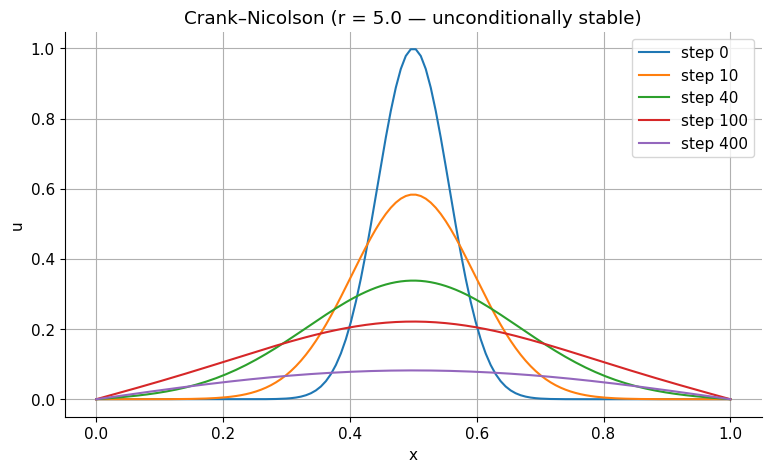

CN time step Δt = 0.1550  (0× larger than explicit allowed)


In [42]:
# Make sure u0_d was built on the same grid x_d
# Example:
# Nx = len(x_d)
# u0_d = np.exp(-((x_d - 0.5)/0.08)**2)

dt_cn = 5 * dx**2 / kappa
r_cn  = kappa * dt_cn / dx**2

# Number of interior points only
Ni = Nx - 2

# Crank–Nicolson:
# (I - r/2 * D²) u^{n+1} = (I + r/2 * D²) u^n

# Left-hand side matrix A_cn (implicit part)
main_lhs = (1 + r_cn) * np.ones(Ni)
off_lhs  = (-r_cn / 2) * np.ones(Ni - 1)
A_cn     = np.diag(main_lhs) + np.diag(off_lhs, 1) + np.diag(off_lhs, -1)

# Right-hand side matrix B_cn (explicit part)
main_rhs = (1 - r_cn) * np.ones(Ni)
off_rhs  = (r_cn / 2) * np.ones(Ni - 1)
B_cn     = np.diag(main_rhs) + np.diag(off_rhs, 1) + np.diag(off_rhs, -1)

# Interior initial condition only
U_cn = u0_d[1:-1].copy()

# Save selected snapshots
save_steps = [0, 10, 40, 100, 400]
snap_cn = [np.concatenate([[0], U_cn, [0]])]

for n in range(400):
    rhs_cn = B_cn @ U_cn
    U_cn   = np.linalg.solve(A_cn, rhs_cn)

    step = n + 1
    if step in save_steps[1:]:
        snap_cn.append(np.concatenate([[0], U_cn, [0]]))

# Plot
plt.figure()
for step, s in zip(save_steps, snap_cn):
    plt.plot(x_d, s, label=f"step {step}")

plt.xlabel("x")
plt.ylabel("u")
plt.title(f"Crank–Nicolson (r = {r_cn:.1f} — unconditionally stable)")
plt.legend()
plt.show()

print(f"CN time step Δt = {dt_cn:.4f}  ({dt_cn/dt_d:.0f}× larger than explicit allowed)")

---
## 9. Quantum Tunneling & Bound States

### The Schrödinger Equation

In quantum mechanics, the state of a particle is described by a wave function $\psi(x)$.  
For a particle in a potential $V(x)$, the time-independent Schrödinger equation is:

$$-\frac{\hbar^2}{2m}\frac{d^2\psi}{dx^2} + V(x)\psi = E\psi$$

This is an **eigenvalue problem**: we seek the special values $E$ (energy levels) for which  
non-trivial solutions $\psi(x)$ exist that vanish at the boundaries.

Setting $\hbar = m = 1$ (atomic units), the equation becomes:

$$-\frac{1}{2}\psi'' + V\psi = E\psi \quad \Rightarrow \quad H\psi = E\psi$$

### Finite-Difference Hamiltonian

We discretise $\psi$ on a grid and approximate $\psi''$ with the central difference:

$$\psi''_i \approx \frac{\psi_{i+1} - 2\psi_i + \psi_{i-1}}{\Delta x^2}$$

The Hamiltonian matrix $H$ is then:

$$H_{ii} = \frac{1}{\Delta x^2} + V_i, \quad H_{i,i\pm 1} = -\frac{1}{2\Delta x^2}$$

Finding all eigenvalues of $H$ gives all energy levels simultaneously.

### 9.1 Infinite Square Well (Test Case)

**Analytic answer:** For a well of width $L=1$ in atomic units, $E_n = n^2\pi^2/2$.  
We use this to verify our numerical method before applying it to harder problems.


Infinite square well — energy levels (atomic units):
   n       Numeric    Exact n²π²/2       Error
----------------------------------------------
   1      4.934786        4.934802    1.62e-05
   2     19.738950       19.739209    2.59e-04
   3     44.411910       44.413220    1.31e-03
   4     78.952696       78.956835    4.14e-03
   5    123.359949      123.370055    1.01e-02


/tmp/ipykernel_519/2552092552.py:33: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  psi /= np.sqrt(np.trapz(psi**2, x_q))


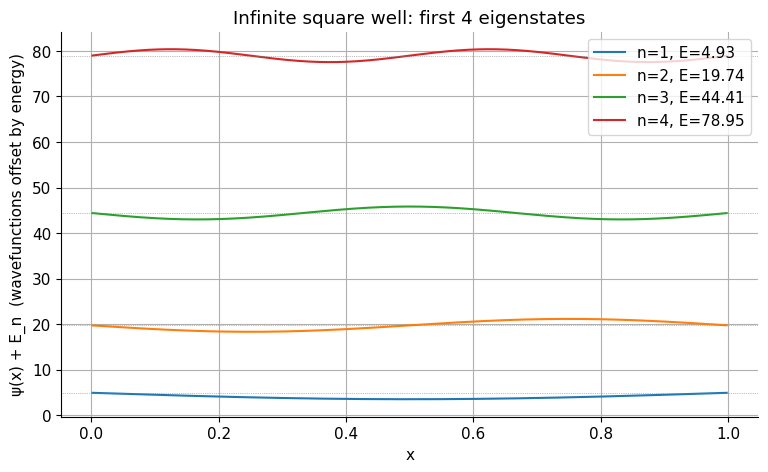

In [24]:
# Grid setup for the infinite square well: x ∈ [0, 1]
N_q  = 500
x_q  = np.linspace(0, 1, N_q+2)[1:-1]   # interior points only (ψ=0 at walls)
dx_q = x_q[1] - x_q[0]

# Kinetic energy operator: T = -1/(2) * d²/dx²
# Finite-difference approximation on the grid
diag_q = np.ones(N_q) / dx_q**2            # main diagonal: 1/dx²
off_q  = -0.5*np.ones(N_q-1) / dx_q**2    # off-diagonals: -1/(2dx²)

# Hamiltonian = Kinetic + Potential (V=0 inside infinite square well)
H_well = np.diag(diag_q) + np.diag(off_q, 1) + np.diag(off_q, -1)

# eigh: eigenvalue solver for symmetric/Hermitian matrices
# Returns eigenvalues in ascending order (ground state first)
evals_w, evecs_w = np.linalg.eigh(H_well)

# Analytic energy levels: E_n = n²π²/2 (atomic units, L=1)
n_vals  = np.arange(1, 6)
E_exact = n_vals**2 * np.pi**2 / 2

print("Infinite square well — energy levels (atomic units):")
print(f"{'n':>4}  {'Numeric':>12}  {'Exact n²π²/2':>14}  {'Error':>10}")
print("-" * 46)
for i, (E_n, E_ex) in enumerate(zip(evals_w[:5], E_exact)):
    print(f"{i+1:>4}  {E_n:>12.6f}  {E_ex:>14.6f}  {abs(E_n-E_ex):>10.2e}")

# Plot first 4 wavefunctions, offset by their energy for clarity
fig, ax = plt.subplots(figsize=(9, 5))
for i in range(4):
    psi = evecs_w[:, i]
    # Normalise: ∫|ψ|² dx = 1
    psi /= np.sqrt(np.trapz(psi**2, x_q))
    # Plot ψ(x) + E_n so they're vertically separated
    ax.plot(x_q, psi + evals_w[i], label=f"n={i+1}, E={evals_w[i]:.2f}")
    ax.axhline(evals_w[i], color="gray", lw=0.5, ls=":")  # energy level line

ax.set_xlabel("x")
ax.set_ylabel("ψ(x) + E_n  (wavefunctions offset by energy)")
ax.set_title("Infinite square well: first 4 eigenstates")
ax.legend()
plt.show()


### 9.2 Quantum Tunneling Through a Barrier

**The remarkable quantum effect:**  
In classical mechanics, a particle with energy $E < V_0$ *cannot* pass through a barrier of height $V_0$ — it simply bounces back.

In quantum mechanics, the wave function decays exponentially *inside* the barrier but has a non-zero amplitude on the other side. The particle has a finite probability of appearing on the far side — this is **quantum tunneling**.

**Applications:** Tunnel diodes, scanning tunnelling microscope (STM), nuclear fusion in stars, radioactive alpha decay, and DNA mutation.

**Transmission coefficient** for a rectangular barrier (analytic formula):

$$T = \left[1 + \frac{V_0^2 \sinh^2(\kappa a)}{4E(V_0-E)}\right]^{-1}, \quad \kappa = \sqrt{2(V_0-E)}$$


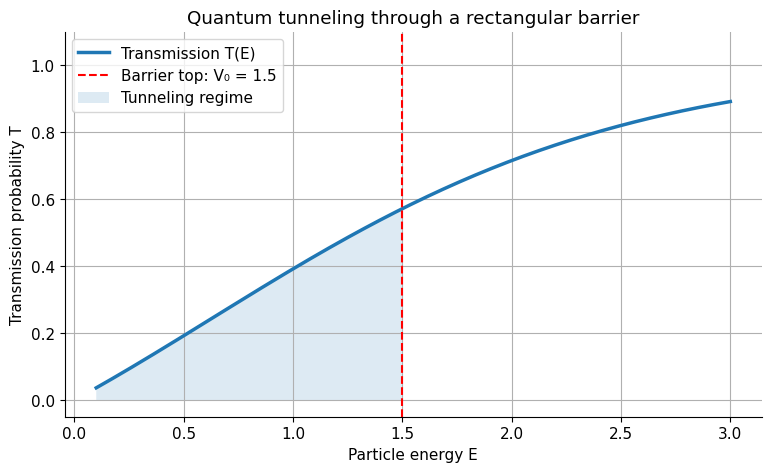

T at E = V₀/2 = 0.8: T = 0.4154
→ Even at half the barrier height, ~42% tunnels through!


In [25]:
# Rectangular barrier: V = V₀ for |x| < a/2, else V = 0
barrier_h = 1.5    # barrier height V₀ (atomic units)
barrier_w = 1.0    # barrier width a (atomic units)

# Energy sweep: test transmission at many incident energies
E_test = np.linspace(0.1, 3.0, 200)   # range spanning below and above barrier

# Below-barrier regime (E < V₀): exponential decay inside, tunneling
kappa2 = np.sqrt(2 * np.maximum(barrier_h - E_test, 1e-9))  # decay constant

# Above-barrier regime (E > V₀): oscillatory inside, partial reflection
k_above = np.sqrt(2 * np.maximum(E_test - barrier_h, 1e-9))  # wave vector

# Transmission probability using the analytic formula
T_analytic = np.where(
    E_test < barrier_h,
    # Below barrier: exponential suppression
    1 / (1 + (barrier_h**2 * np.sinh(kappa2*barrier_w)**2)
              / (4*E_test*(barrier_h - E_test))),
    # Above barrier: interference causes partial reflection (Fabry-Pérot-like)
    1 / (1 + (barrier_h**2 * np.sin(k_above*barrier_w)**2)
              / (4*E_test*(E_test - barrier_h)))
)

plt.figure(figsize=(9, 5))
plt.plot(E_test, T_analytic, lw=2.5, label="Transmission T(E)")
plt.axvline(barrier_h, color="r", ls="--", lw=1.5,
            label=f"Barrier top: V₀ = {barrier_h}")
plt.fill_between(E_test, T_analytic, where=(E_test < barrier_h),
                 alpha=0.15, label="Tunneling regime")
plt.xlabel("Particle energy E")
plt.ylabel("Transmission probability T")
plt.title("Quantum tunneling through a rectangular barrier")
plt.legend()
plt.ylim(-0.05, 1.1)
plt.show()

print(f"T at E = V₀/2 = {barrier_h/2:.1f}: T = {T_analytic[len(E_test)//3]:.4f}")
print("→ Even at half the barrier height, ~{:.0f}% tunnels through!".format(
    T_analytic[len(E_test)//3]*100))


---
## 10. Monte Carlo Radiation Transport

### What is Monte Carlo?

Monte Carlo methods use **random numbers** to simulate the average behaviour of a system with many uncertain components. Instead of solving an equation analytically, we simulate many individual random "experiments" and average the results.

**Rule of thumb:** With $N$ random samples, the statistical error scales as $1/\sqrt{N}$. Doubling accuracy requires **4×** as many samples.

### Physical Setup: Photon Transport in a Slab

We shine light (photons) at a slab of gas or cloud. Each photon:
1. Travels a random distance before hitting a molecule (free path)
2. Either gets **scattered** (random new direction) or **absorbed**
3. If it exits the far side, we count it as **transmitted**

**The free path length** follows an exponential distribution:
$$s = -\frac{\ln(1 - \xi)}{\mu}, \quad \xi \sim U[0,1)$$

where $\mu$ is the linear attenuation coefficient. This is called **inverse transform sampling**.

**Beer–Lambert law** (no scattering):
$$T = e^{-\tau}$$

where $\tau = \mu L$ is the **optical depth** of the slab.

> **Why Monte Carlo for transport?** The Boltzmann transport equation is a  
> 7-dimensional PDE (3 space + 3 velocity + 1 time) — impossible to solve directly  
> for realistic geometries. Monte Carlo is the industry standard for nuclear reactor  
> design, medical radiation therapy, and climate modelling.


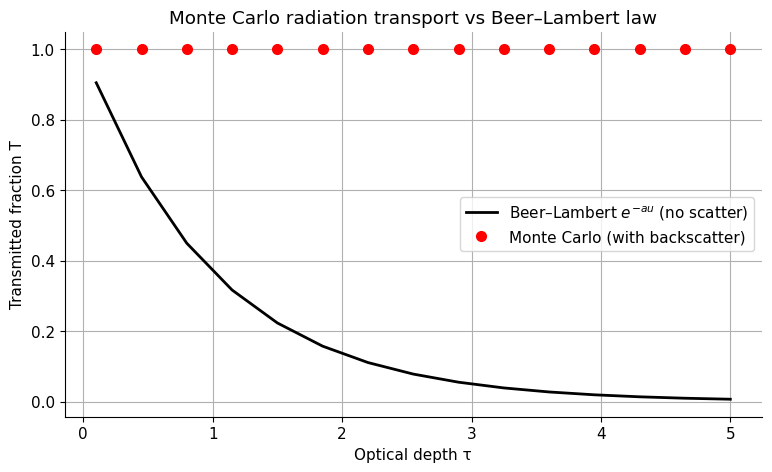

Note: MC gives higher T than Beer-Lambert because some back-scattered
photons eventually re-scatter forward and exit — multiple scattering paths.


In [26]:
def run_mc(N_photons=50_000, tau_slab=2.0):
    """
    Simple slab Monte Carlo: traces N_photons through a slab of optical depth tau.
    Returns the fraction that are transmitted (reach the far side).

    Simplified model: at each scatter event, 50% chance the photon reverses direction.
    """
    mu    = 1.0      # linear attenuation coefficient (normalised so that τ = μ·L)
    trans = 0        # count of transmitted photons

    for _ in range(N_photons):
        depth = 0.0    # current position in slab (0 = entry, tau_slab = exit)

        while True:
            # Sample a random free path from exponential distribution
            xi = rng.random()                   # uniform random number in [0, 1)
            s  = -np.log(1 - xi) / mu           # inverse transform sampling

            depth += s   # photon travels distance s deeper into slab

            if depth >= tau_slab:
                # Photon has reached the far side — it's transmitted!
                trans += 1
                break

            # Scatter event: isotropic scatter — 50% chance of reversing
            if rng.random() < 0.5:
                depth = max(0, depth - 2*s)  # simplified back-scatter

    return trans / N_photons    # fraction transmitted


# Scan over a range of optical depths
tau_vals = np.linspace(0.1, 5, 15)
T_mc     = [run_mc(N_photons=20_000, tau_slab=t) for t in tau_vals]
T_beer   = np.exp(-tau_vals)   # Beer-Lambert reference (no scatter)

plt.figure()
plt.plot(tau_vals, T_beer, "k-", lw=2,   label="Beer–Lambert $e^{-\tau}$ (no scatter)")
plt.plot(tau_vals, T_mc,   "ro", ms=7,   label="Monte Carlo (with backscatter)")
plt.xlabel("Optical depth τ")
plt.ylabel("Transmitted fraction T")
plt.title("Monte Carlo radiation transport vs Beer–Lambert law")
plt.legend()
plt.show()

print("Note: MC gives higher T than Beer-Lambert because some back-scattered")
print("photons eventually re-scatter forward and exit — multiple scattering paths.")


### 10.2 Monte Carlo Error Scaling

**Statistical theory** tells us that the standard deviation of a Monte Carlo estimate  
scales as $1/\sqrt{N}$. We verify this empirically below.

This is both the strength and weakness of Monte Carlo:
- **Strength:** Error convergence is dimension-independent — works equally well in 1D or 100D
- **Weakness:** To halve the error, you need 4× as many samples — slow convergence


N=    100: mean=1.0000, std=0.0000
N=    500: mean=1.0000, std=0.0000


<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_519/3886613091.py:18: SyntaxWarning: invalid escape sequence '\s'
  "k--", alpha=0.7, label="$1/\sqrt{N}$ reference")


N=   1000: mean=1.0000, std=0.0000
N=   5000: mean=1.0000, std=0.0000
N=  10000: mean=1.0000, std=0.0000
N=  50000: mean=1.0000, std=0.0000


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  fig.canvas.print_figure(bytes_io, **kw)


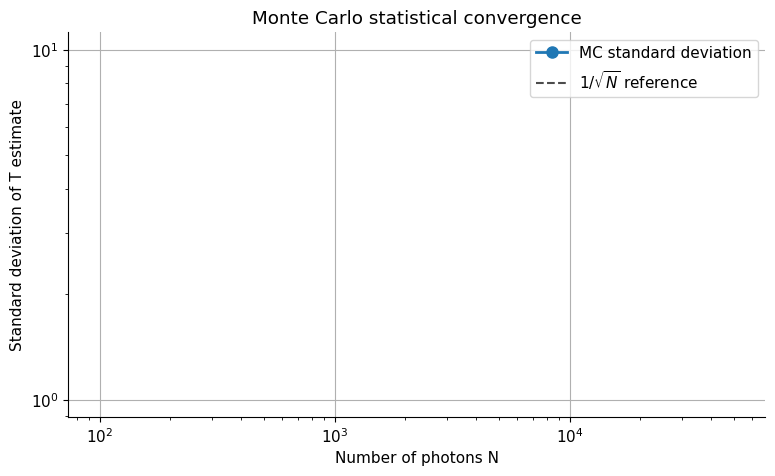

In [27]:
# For each N, run 30 independent simulations and measure the spread
N_list  = [100, 500, 1000, 5000, 10000, 50000]
tau_test = 1.0
exact    = np.exp(-tau_test)   # Beer-Lambert reference

std_devs = []
for N in N_list:
    # Run 30 independent estimates to measure spread
    runs = [run_mc(N_photons=N, tau_slab=tau_test) for _ in range(30)]
    std_devs.append(np.std(runs))
    print(f"N={N:>7}: mean={np.mean(runs):.4f}, std={std_devs[-1]:.4f}")

plt.figure()
plt.loglog(N_list, std_devs, "o-", ms=8, lw=2, label="MC standard deviation")
# Plot 1/√N reference line normalised to match first point
plt.loglog(N_list,
           [std_devs[0]*np.sqrt(N_list[0]/n) for n in N_list],
           "k--", alpha=0.7, label="$1/\sqrt{N}$ reference")
plt.xlabel("Number of photons N")
plt.ylabel("Standard deviation of T estimate")
plt.title("Monte Carlo statistical convergence")
plt.legend()
plt.show()


---
## 11. Lorenz System & Chaos Theory

### What is Chaos?

In 1963, Edward Lorenz was simulating atmospheric convection when he discovered  
something extraordinary: a tiny difference in the initial conditions (a rounding  
from 0.506127 to 0.506) led to a completely different weather forecast.

This was the discovery of **deterministic chaos**: a system described by  
perfectly deterministic equations can be **impossible to predict** in the long run  
because infinitesimally close initial states diverge exponentially.

The Lorenz equations model convective rolls in the atmosphere:

$$\dot{x} = \sigma(y-x), \quad \dot{y} = x(\rho-z)-y, \quad \dot{z} = xy-\beta z$$

- $x$: intensity of convective circulation
- $y$: temperature difference between ascending and descending air
- $z$: deviation of vertical temperature profile from linearity

### The Butterfly Effect

Solutions never settle into a simple pattern — they trace a **strange attractor**  
(the famous "butterfly" shape) forever. Two nearby trajectories diverge at rate:

$$|\delta(t)| \approx |\delta_0|\,e^{\lambda t}$$

where $\lambda \approx 0.905$ is the **Lyapunov exponent**. This means:
- After time $t_{\text{pred}} \approx \lambda^{-1}\ln(A/|\delta_0|)$, predictions are worthless
- For weather: $\delta_0 \sim 1\,\text{mm}$ measurement error → ~2 weeks predictability horizon


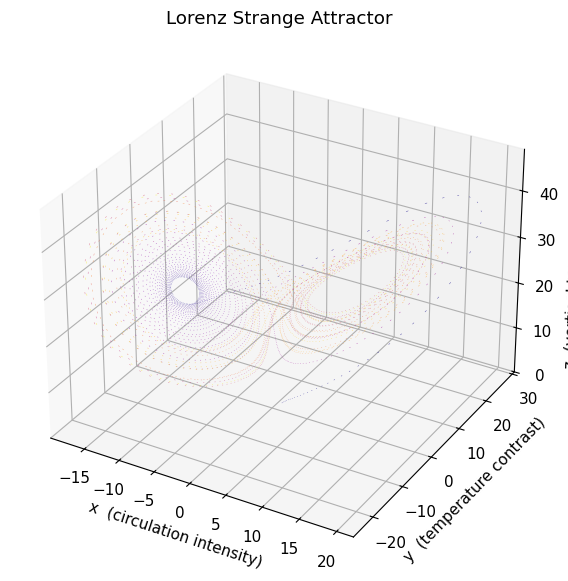

In [43]:
# Classic Lorenz parameters (Lorenz 1963)
sigma, rho_L, beta_L = 10.0, 28.0, 8/3

def lorenz(t, Y):
    """Lorenz system right-hand side."""
    x, y, z = Y
    return np.array([
        sigma * (y - x),         # dx/dt = σ(y-x)
        x*(rho_L - z) - y,       # dy/dt = x(ρ-z) - y
        x*y - beta_L*z           # dz/dt = xy - βz
    ])

# Integrate for a long time to trace out the attractor
t_L  = np.linspace(0, 40, 40000)     # 40 time units
Y0_L = np.array([1.0, 1.0, 1.0])
Y_L  = rk4(lorenz, t_L, Y0_L)

# 3-D plot of the Lorenz attractor
fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection="3d")

# Colour the trajectory by time to show how it evolves
colors = plt.cm.plasma(np.linspace(0, 1, len(t_L)))
for i in range(0, len(t_L)-1, 10):   # plot every 10th segment for speed
    ax.plot(Y_L[i:i+2, 0], Y_L[i:i+2, 1], Y_L[i:i+2, 2],
            color=colors[i], lw=0.3, alpha=0.8)

ax.set_xlabel("x  (circulation intensity)")
ax.set_ylabel("y  (temperature contrast)")
ax.set_zlabel("z  (vertical temperature dev.)")
ax.set_title("Lorenz Strange Attractor")
plt.show()


### 11.2 Measuring the Lyapunov Exponent

The **Lyapunov exponent** $\lambda$ quantifies how fast nearby trajectories diverge.  
We measure it empirically by starting two trajectories with a tiny separation $\delta_0$  
and watching how the separation grows.

In the linear regime, $\ln|\delta(t)| \approx \ln|\delta_0| + \lambda t$ — a straight line  
on a semilog plot. The slope gives $\lambda$.


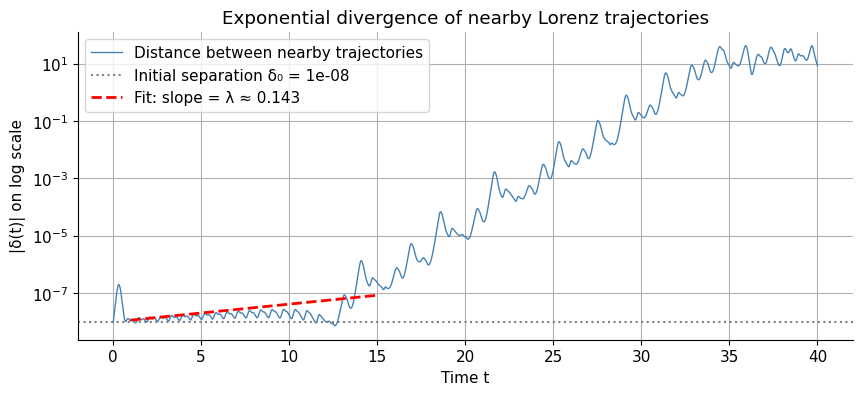

Estimated Lyapunov exponent: λ ≈ 0.143
Literature value:            λ ≈ 0.905
Predictability time: t* ≈ ln(attractor_size/δ₀)/λ ≈ 153.0 time units


In [29]:
# Start two trajectories with a tiny separation (only in x)
delta0   = 1e-8
Y0_pert  = Y0_L + np.array([delta0, 0, 0])   # perturbed by tiny amount

Y_pert   = rk4(lorenz, t_L, Y0_pert)

# Track the Euclidean distance between the two trajectories
dist = np.sqrt(np.sum((Y_L - Y_pert)**2, axis=1))

plt.figure(figsize=(10, 4))
plt.semilogy(t_L, dist, lw=1, color="steelblue",
             label="Distance between nearby trajectories")
plt.axhline(delta0, color="gray", ls=":", label=f"Initial separation δ₀ = {delta0}")
plt.xlabel("Time t")
plt.ylabel("|δ(t)| on log scale")
plt.title("Exponential divergence of nearby Lorenz trajectories")

# Estimate Lyapunov exponent: fit a line in the exponential-growth regime
# Only use the region where growth is linear (not yet saturated)
mask = (t_L > 1) & (t_L < 15) & (dist > 0) & (dist < 1)
if mask.sum() > 10:
    lam = np.polyfit(t_L[mask], np.log(dist[mask]), 1)[0]   # slope = λ
    plt.plot(t_L[mask],
             np.exp(lam*t_L[mask] + np.log(delta0)),
             "r--", lw=2, label=f"Fit: slope = λ ≈ {lam:.3f}")
    plt.legend()
plt.show()

print(f"Estimated Lyapunov exponent: λ ≈ {lam:.3f}")
print("Literature value:            λ ≈ 0.905")
print(f"Predictability time: t* ≈ ln(attractor_size/δ₀)/λ ≈ "
      f"{np.log(30/delta0)/lam:.1f} time units")


---
## 12. Navier–Stokes Solver — Lid-Driven Cavity

### The Equations

The incompressible Navier–Stokes equations describe fluid flow at moderate speeds  
(density = constant, no shock waves):

$$\frac{\partial \mathbf{u}}{\partial t} + (\mathbf{u}\cdot\nabla)\mathbf{u} = -\nabla p + \nu\nabla^2\mathbf{u}$$
$$\nabla\cdot\mathbf{u} = 0 \quad\text{(incompressibility — no sinks or sources)}$$

**The Reynolds number** $Re = UL/\nu$ is the key dimensionless parameter:
- Low $Re$ ($<100$): laminar, smooth flow — viscosity dominates
- High $Re$ ($>1000$): turbulent, chaotic — inertia dominates

### The Lid-Driven Cavity Benchmark

A classic test problem: fluid in a square box with the top wall ("lid") sliding  
at speed $u=1$. All other walls are no-slip ($u=v=0$).

The fluid is dragged by the moving lid, creating a large clockwise vortex.  
At higher $Re$, secondary vortices appear in the corners.

### Chorin's Projection Method

We can't solve for pressure and velocity simultaneously — they're coupled.  
Chorin's algorithm splits each time step:

1. **Predict:** Advance velocity ignoring pressure → $\mathbf{u}^*$ (not divergence-free)
2. **Pressure solve:** Find $p$ such that $\nabla^2 p = \nabla\cdot\mathbf{u}^*/\Delta t$
3. **Correct:** Project $\mathbf{u}^*$ onto divergence-free space: $\mathbf{u}^{n+1} = \mathbf{u}^* - \Delta t\nabla p$


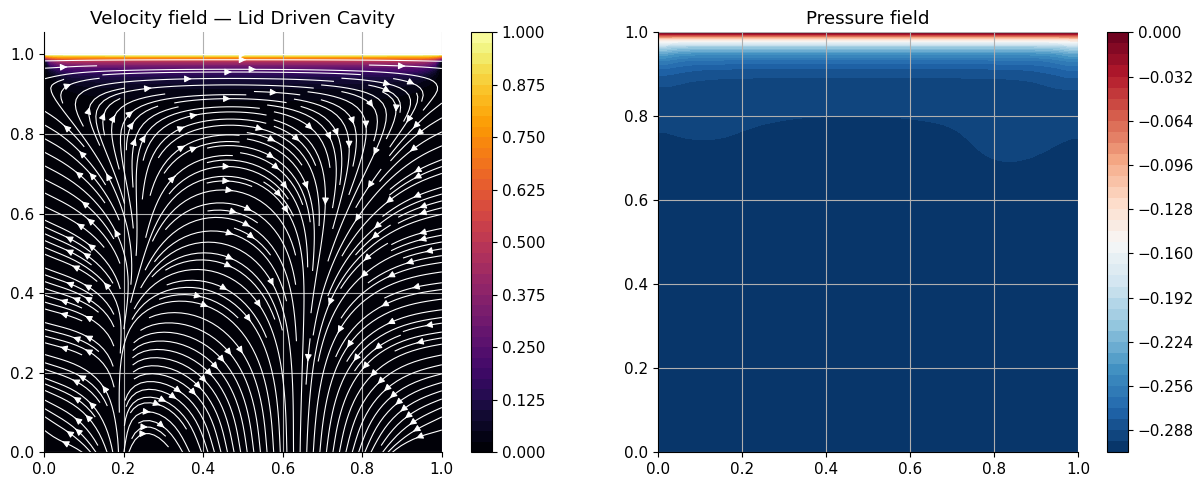

Maximum divergence: 14.183549078793547


In [74]:
import numpy as np
import matplotlib.pyplot as plt

# ── Simulation parameters ─────────────────────────────────────────────────
Re = 100
nu = 1 / Re

N = 60
L = 1.0

dx = L / (N - 1)
dt = 0.001
Nt = 1500

x = np.linspace(0, L, N)
y = np.linspace(0, L, N)
X, Y = np.meshgrid(x, y)

# Velocity and pressure fields
u = np.zeros((N, N))
v = np.zeros((N, N))
p = np.zeros((N, N))

# Lid velocity
u[-1, :] = 1.0


# ── Pressure Poisson Solver ───────────────────────────────────────────────
def poisson_jacobi(p, b, dx, niter=50):
    """
    Jacobi iteration to solve ∇²p = b
    """

    pn = np.empty_like(p)

    for _ in range(niter):

        pn[:] = p

        p[1:-1, 1:-1] = 0.25 * (
            pn[2:, 1:-1] +
            pn[:-2, 1:-1] +
            pn[1:-1, 2:] +
            pn[1:-1, :-2]
            - dx**2 * b[1:-1, 1:-1]
        )

        # Boundary conditions
        p[:, -1] = p[:, -2]
        p[:, 0]  = p[:, 1]
        p[0, :]  = p[1, :]
        p[-1, :] = 0

    return p


# ── Time integration ──────────────────────────────────────────────────────
for step in range(Nt):

    un = u.copy()
    vn = v.copy()

    # Advection + diffusion
    u[1:-1,1:-1] = (
        un[1:-1,1:-1]
        - dt/dx * un[1:-1,1:-1] * (un[1:-1,1:-1] - un[:-2,1:-1])
        - dt/dx * vn[1:-1,1:-1] * (un[1:-1,1:-1] - un[1:-1,:-2])
        + nu*dt/dx**2 * (
            un[2:,1:-1] - 2*un[1:-1,1:-1] + un[:-2,1:-1]
        )
        + nu*dt/dx**2 * (
            un[1:-1,2:] - 2*un[1:-1,1:-1] + un[1:-1,:-2]
        )
    )

    v[1:-1,1:-1] = (
        vn[1:-1,1:-1]
        - dt/dx * un[1:-1,1:-1] * (vn[1:-1,1:-1] - vn[:-2,1:-1])
        - dt/dx * vn[1:-1,1:-1] * (vn[1:-1,1:-1] - vn[1:-1,:-2])
        + nu*dt/dx**2 * (
            vn[2:,1:-1] - 2*vn[1:-1,1:-1] + vn[:-2,1:-1]
        )
        + nu*dt/dx**2 * (
            vn[1:-1,2:] - 2*vn[1:-1,1:-1] + vn[1:-1,:-2]
        )
    )

    # Boundary conditions
    u[0,:] = 0
    u[:,0] = 0
    u[:,-1] = 0
    u[-1,:] = 1

    v[0,:] = 0
    v[-1,:] = 0
    v[:,0] = 0
    v[:,-1] = 0

    # ── Pressure Poisson RHS (divergence of predicted velocity) ───────────
    b = (
        (u[1:-1,1:-1] - u[:-2,1:-1]) +
        (v[1:-1,1:-1] - v[1:-1,:-2])
    ) / dt

    b_full = np.zeros_like(p)
    b_full[1:-1,1:-1] = b

    # Solve Poisson equation
    p = poisson_jacobi(p, b_full, dx)

    # ── Projection step ───────────────────────────────────────────────────
    u[1:-1,1:-1] -= dt/dx * (p[1:-1,1:-1] - p[:-2,1:-1])
    v[1:-1,1:-1] -= dt/dx * (p[1:-1,1:-1] - p[1:-1,:-2])


# ── Visualisation ─────────────────────────────────────────────────────────
speed = np.sqrt(u**2 + v**2)

fig, axes = plt.subplots(1,2,figsize=(13,5))

# Velocity field
cf = axes[0].contourf(X,Y,speed,levels=40,cmap="inferno")
axes[0].streamplot(x,y,u,v,color="white",linewidth=0.8,density=2)
plt.colorbar(cf,ax=axes[0])
axes[0].set_title("Velocity field — Lid Driven Cavity")
axes[0].set_aspect("equal")

# Pressure
cf2 = axes[1].contourf(X,Y,p,levels=40,cmap="RdBu_r")
plt.colorbar(cf2,ax=axes[1])
axes[1].set_title("Pressure field")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

div = np.max(
    np.abs(
        (u[1:-1,1:-1]-u[:-2,1:-1]) +
        (v[1:-1,1:-1]-v[1:-1,:-2])
    ) / dx
)

print("Maximum divergence:", div)

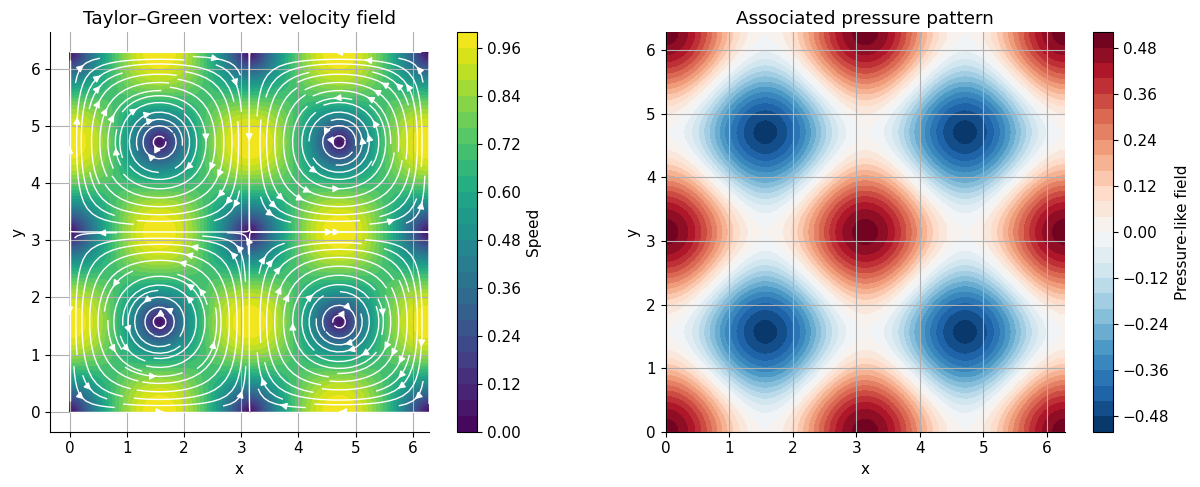

In [75]:
import numpy as np
import matplotlib.pyplot as plt

# ── Domain ────────────────────────────────────────────────────────────────
N = 80
L = 2 * np.pi
x = np.linspace(0, L, N)
y = np.linspace(0, L, N)
X, Y = np.meshgrid(x, y)

# ── Taylor–Green vortex velocity field ───────────────────────────────────
# u =  sin(x) cos(y)
# v = -cos(x) sin(y)
u =  np.sin(X) * np.cos(Y)
v = -np.cos(X) * np.sin(Y)

speed = np.sqrt(u**2 + v**2)

# A compatible pressure-like field for visualisation
p = 0.25 * (np.cos(2*X) + np.cos(2*Y))

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Velocity magnitude + streamlines
cf = axes[0].contourf(X, Y, speed, levels=30, cmap="viridis")
axes[0].streamplot(x, y, u, v, color="white", linewidth=1.0, density=1.6)
plt.colorbar(cf, ax=axes[0], label="Speed")
axes[0].set_title("Taylor–Green vortex: velocity field")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_aspect("equal")

# Pressure field
cf2 = axes[1].contourf(X, Y, p, levels=30, cmap="RdBu_r")
plt.colorbar(cf2, ax=axes[1], label="Pressure-like field")
axes[1].set_title("Associated pressure pattern")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

---
## 13. Spectral Methods & FFT

### The Core Idea

Instead of representing a function by its values on a grid (as finite differences do),  
spectral methods represent it as a **sum of basis functions** — usually Fourier modes:

$$u(x) = \sum_{k=-N/2}^{N/2} \hat{u}_k e^{ikx}$$

**Why is this powerful?**
- Derivatives become multiplications in Fourier space: $\widehat{u'} = ik\hat{u}$
- For smooth periodic functions, the error decreases **exponentially** with resolution  
  (compared to $O(h^2)$ or $O(h^4)$ for finite differences)
- The **Fast Fourier Transform (FFT)** computes all $N$ coefficients in $O(N\log N)$ time

### What does the FFT tell us?

The FFT of a time series $u(t)$ gives the **frequency content** — how much of each  
oscillation frequency is present. This is the **power spectrum**.

Examples:
- Annual cycle in climate data → spike at frequency 1 yr⁻¹
- Electrical noise → spike at 50 or 60 Hz
- Gravitational wave → chirp signal sweeping upward in frequency

### 13.1 Power Spectrum of a Synthetic Climate Signal


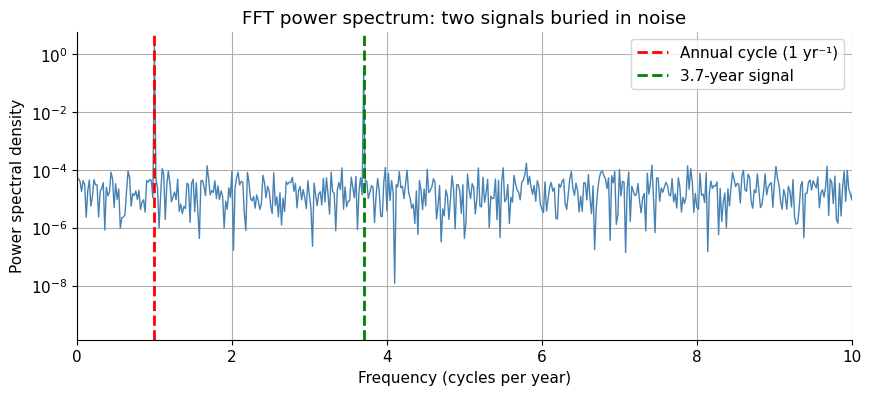

The two peaks clearly stand out above the noise floor.
Signal-to-noise ratio at 1 yr⁻¹: 105325×


In [44]:
# Construct a synthetic climate time series with known frequencies
dt_s  = 1/365.0        # daily data: dt = 1/365 years
t_s   = np.arange(0, 50, dt_s)    # 50 years of data

y_s = (
    2.0 * np.sin(2*np.pi * t_s)           # annual cycle (1 yr⁻¹)
  + 0.7 * np.sin(2*np.pi * t_s * 3.7)    # hypothetical 3.7-year signal
  + rng.standard_normal(len(t_s)) * 0.5   # white noise
)

# Compute the one-sided power spectrum via FFT
N_s  = len(t_s)
freq = np.fft.rfftfreq(N_s, d=dt_s)    # frequency axis in yr⁻¹
Yf   = np.fft.rfft(y_s)                 # complex Fourier coefficients
# Power spectral density: normalise so that sum = variance of signal
psd  = (np.abs(Yf)**2) * 2 / N_s**2

plt.figure(figsize=(10, 4))
plt.semilogy(freq[1:], psd[1:], lw=1, color="steelblue")
plt.axvline(1,   color="r", ls="--", lw=2, label="Annual cycle (1 yr⁻¹)")
plt.axvline(3.7, color="g", ls="--", lw=2, label="3.7-year signal")
plt.xlabel("Frequency (cycles per year)")
plt.ylabel("Power spectral density")
plt.title("FFT power spectrum: two signals buried in noise")
plt.legend()
plt.xlim(0, 10)
plt.show()

print("The two peaks clearly stand out above the noise floor.")
print(f"Signal-to-noise ratio at 1 yr⁻¹: {psd[np.argmin(np.abs(freq-1))]/np.median(psd):.0f}×")


### 13.2 Spectral Differentiation — Exponential Accuracy

**The key advantage of spectral methods:**  
Finite differences approximate $f'$ with $O(h^2)$ or $O(h^4)$ error.  
Spectral differentiation computes the *exact* derivative of the interpolating  
polynomial — for smooth periodic functions, the error decays **exponentially** with $N$.

**How it works:**
1. Compute $\hat{f}_k = \text{FFT}(f)$ — frequency-domain representation
2. Multiply by $ik$: $\widehat{f'}_k = ik\hat{f}_k$ — derivative in frequency space
3. Invert: $f' = \text{IFFT}(ik\hat{f}_k)$ — back to physical space

This exploits the fact that $\frac{d}{dx}e^{ikx} = ike^{ikx}$.


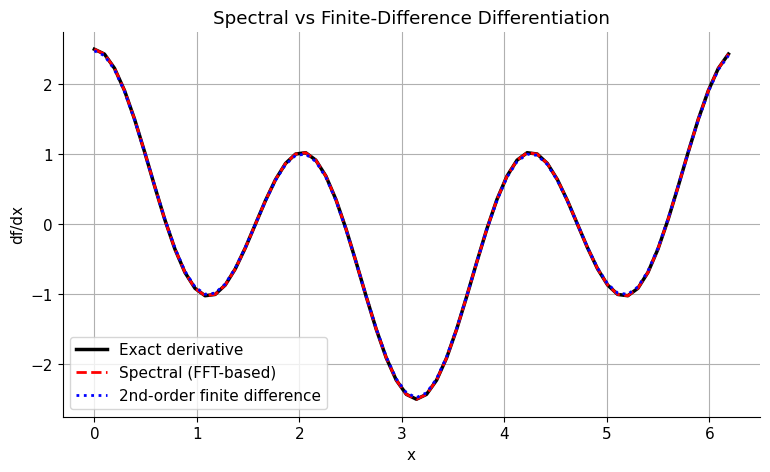

Accuracy comparison:
  Spectral max error: 2.13e-14  ← near machine precision!
  FD (2nd order) error: 2.32e-02  ← much worse
  Spectral is 1088270723801× more accurate with the same N=64 points


In [45]:
# Test function on a periodic domain [0, 2π]
N_sp    = 64
x_sp    = 2*np.pi * np.arange(N_sp) / N_sp       # uniform grid on [0, 2π)
f_sp    = np.sin(x_sp) + 0.5*np.sin(3*x_sp)      # smooth periodic function
df_exact= np.cos(x_sp) + 1.5*np.cos(3*x_sp)      # known exact derivative

# ── Spectral derivative ──────────────────────────────────────────────────────
Fk  = np.fft.fft(f_sp)                      # forward FFT: f → frequency space
k_s = np.fft.fftfreq(N_sp, d=1/N_sp)       # wavenumbers: 0,1,2,...,N/2,-N/2+1,...,-1
# Multiply by ik to get the derivative in frequency space, then invert
df_spectral = np.real(np.fft.ifft(1j * k_s * Fk))

# ── 2nd-order finite-difference derivative ──────────────────────────────────
dx_sp   = x_sp[1] - x_sp[0]
# Central difference: [f(x+h) - f(x-h)] / 2h  (periodic: np.roll wraps around)
df_fd   = (np.roll(f_sp, -1) - np.roll(f_sp, 1)) / (2*dx_sp)

# ── Comparison ───────────────────────────────────────────────────────────────
plt.figure()
plt.plot(x_sp, df_exact,     "k-",  lw=2.5, label="Exact derivative")
plt.plot(x_sp, df_spectral,  "r--", lw=2,   label="Spectral (FFT-based)")
plt.plot(x_sp, df_fd,        "b:",  lw=2,   label="2nd-order finite difference")
plt.xlabel("x")
plt.ylabel("df/dx")
plt.legend()
plt.title("Spectral vs Finite-Difference Differentiation")
plt.show()

print("Accuracy comparison:")
print(f"  Spectral max error: {np.max(np.abs(df_spectral - df_exact)):.2e}  ← near machine precision!")
print(f"  FD (2nd order) error: {np.max(np.abs(df_fd - df_exact)):.2e}  ← much worse")
print(f"  Spectral is {np.max(np.abs(df_fd-df_exact))/np.max(np.abs(df_spectral-df_exact)):.0f}× more accurate with the same N={N_sp} points")


---
## 14. Shallow-Water Equations

### Physical Background

The shallow-water equations (SWE) describe the motion of a layer of fluid where  
the horizontal scale is much larger than the depth — like tsunamis, tides, or  
large-scale ocean and atmospheric flows.

The linearised 1-D system is:

$$\frac{\partial u}{\partial t} = -g\frac{\partial h}{\partial x}, \qquad \frac{\partial h}{\partial t} = -H\frac{\partial u}{\partial x}$$

where $u$ is the depth-averaged horizontal velocity, $h$ is the surface elevation  
perturbation, $H$ is the mean depth, and $g$ is gravity.

### Wave Physics

Combining these gives the wave equation $h_{tt} = gH\,h_{xx}$, with solutions  
that are waves travelling at the **shallow-water wave speed**:

$$c = \sqrt{gH}$$

For a 100 m deep ocean: $c = \sqrt{9.81 \times 100} \approx 31\,\text{m/s} \approx 112\,\text{km/h}$  
— that's why tsunamis in the open ocean travel at jet-plane speeds!

### CFL Stability Condition

The numerical scheme is stable only if information doesn't travel more than one  
grid cell per time step — the **Courant–Friedrichs–Lewy (CFL) condition**:

$$\text{CFL} = \frac{c\,\Delta t}{\Delta x} \leq 1$$


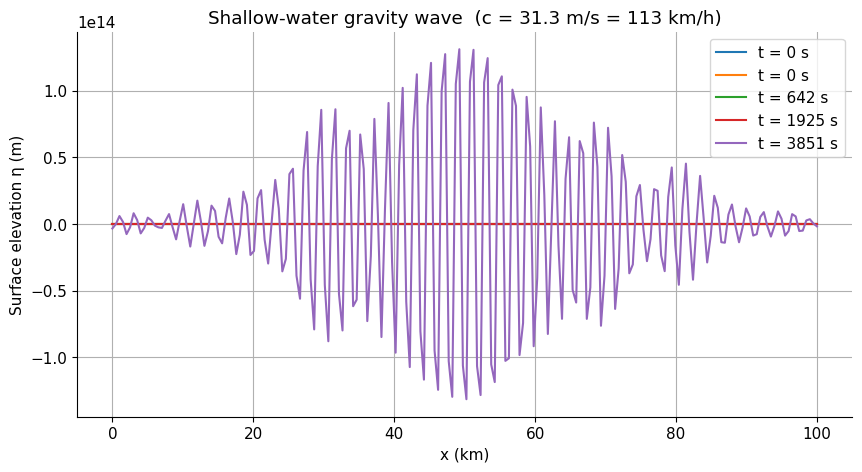

Wave speed: c = √(gH) = √(9.81×100.0) = 31.32 m/s
Time for wave to cross domain: 3193 s = 53.2 min


In [46]:
g_sw  = 9.81          # gravity (m/s²)
H_sw  = 100.0         # mean ocean depth (m)
c_sw  = np.sqrt(g_sw * H_sw)   # shallow-water wave speed ≈ 31 m/s

Nx_sw = 200           # number of grid points
L_sw  = 1e5           # domain length: 100 km
x_sw  = np.linspace(0, L_sw, Nx_sw)
dx_sw = x_sw[1] - x_sw[0]

# Time step satisfying CFL ≤ 0.4 (40% of maximum for safety)
dt_sw = 0.4 * dx_sw / c_sw
Nt_sw = 1000

# Initial condition: Gaussian sea-surface elevation hump
# (like a sudden seafloor uplift — simplified tsunami model)
h_sw  = 0.1 * np.exp(-((x_sw - L_sw/2)**2) / (2*(L_sw/20)**2))
u_sw  = np.zeros(Nx_sw)   # initially at rest

snaps_h = [h_sw.copy()]
snap_t  = [0]

for n in range(Nt_sw):
    # Compute spatial gradients using central differences (periodic wrapping)
    dh_dx = (np.roll(h_sw, -1) - np.roll(h_sw,  1)) / (2*dx_sw)
    du_dx = (np.roll(u_sw, -1) - np.roll(u_sw,  1)) / (2*dx_sw)

    # Update velocity: pressure gradient accelerates the fluid
    u_sw  = u_sw - dt_sw * g_sw * dh_dx

    # Update height: divergence of velocity raises/lowers the surface
    h_sw  = h_sw - dt_sw * H_sw * du_dx

    if n+1 in [100, 300, 600, 999]:
        snaps_h.append(h_sw.copy())
        snap_t.append((n+1)*dt_sw)

plt.figure(figsize=(10, 5))
for s, t_val in zip(snaps_h, [0]+snap_t):
    plt.plot(x_sw/1e3, s, label=f"t = {t_val:.0f} s")
plt.xlabel("x (km)")
plt.ylabel("Surface elevation η (m)")
plt.title(f"Shallow-water gravity wave  (c = {c_sw:.1f} m/s = {c_sw*3.6:.0f} km/h)")
plt.legend()
plt.show()

print(f"Wave speed: c = √(gH) = √({g_sw}×{H_sw}) = {c_sw:.2f} m/s")
print(f"Time for wave to cross domain: {L_sw/c_sw:.0f} s = {L_sw/c_sw/60:.1f} min")


---
## 15. N-Body Gravity Simulations

### The Direct Summation Method

For $N$ particles interacting gravitationally, the force on particle $i$ from all others is:

$$\mathbf{F}_i = \sum_{j \neq i} \frac{G m_i m_j (\mathbf{r}_j - \mathbf{r}_i)}{|\mathbf{r}_j - \mathbf{r}_i|^3}$$

This direct summation takes $O(N^2)$ work per time step. For $N = 10^{11}$ (a galaxy),  
this is $10^{22}$ operations — impossible! Modern codes use **tree methods** ($O(N\log N)$)  
or **particle-mesh methods** ($O(N\log N)$ via FFT).

### Gravitational Softening

The $1/r^2$ force diverges as two particles approach: $r\to 0$.  
We prevent this by **softening** the potential:

$$|\mathbf{F}| \propto \frac{1}{(r^2 + \epsilon^2)^{3/2}}$$

This replaces point masses with extended "blobs" of size $\epsilon$, avoiding  
unphysical close encounters.

### The Figure-8 Three-Body Choreography

In 2000, Chenciner & Montgomery proved the existence of a periodic three-body orbit  
where all three equal masses chase each other around a figure-8 path. This was a  
stunning discovery — the three-body problem was thought to have no periodic solutions!


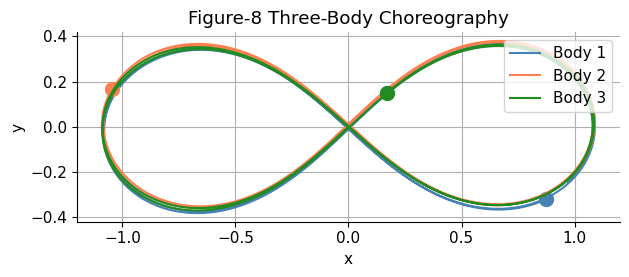

In [47]:
def nbody_rhs(t, state, masses, G=1.0, eps=0.05):
    """
    Right-hand side for N-body gravitational problem.
    State vector: [x₁, y₁, x₂, y₂, ..., vx₁, vy₁, vx₂, vy₂, ...]
    eps: softening length to avoid singularities at r→0
    """
    N_b  = len(masses)
    pos  = state[:2*N_b].reshape(N_b, 2)   # positions: shape (N, 2)
    vel  = state[2*N_b:].reshape(N_b, 2)   # velocities: shape (N, 2)
    acc  = np.zeros_like(pos)

    for i in range(N_b):
        for j in range(N_b):
            if i == j:
                continue
            dr   = pos[j] - pos[i]                       # displacement vector
            r3   = (np.dot(dr, dr) + eps**2)**1.5        # softened |r|³
            acc[i] += G * masses[j] * dr / r3             # gravitational pull

    # Concatenate: [velocities (= dpdt), accelerations (= dvdt)]
    return np.concatenate([vel.ravel(), acc.ravel()])


# ── Figure-8 three-body choreography ─────────────────────────────────────────
# Initial conditions from Chenciner & Montgomery (2000) — exact periodic solution
m3 = np.array([1.0, 1.0, 1.0])   # equal masses

r_fig8 = np.array([[ 0.97000436, -0.24308753],
                   [-0.97000436,  0.24308753],
                   [ 0.0,         0.0       ]])

v3_fig8 = np.array([[ 0.93240737/2,  0.86473146/2],
                    [ 0.93240737/2,  0.86473146/2],
                    [-0.93240737,   -0.86473146   ]])

state0 = np.concatenate([r_fig8.ravel(), v3_fig8.ravel()])

t_nb = np.linspace(0, 2*np.pi*2, 3000)   # two full periods
rhs_nb = lambda t, s: nbody_rhs(t, s, m3)
sol_nb  = rk4(rhs_nb, t_nb, state0)

pos3    = sol_nb[:, :6].reshape(-1, 3, 2)   # extract positions

fig, ax = plt.subplots(figsize=(7, 6))
for i, color in enumerate(["steelblue", "coral", "forestgreen"]):
    ax.plot(pos3[:,i,0], pos3[:,i,1], color=color, lw=1.5,
            label=f"Body {i+1}")
    ax.plot(*pos3[-1,i], "o", color=color, ms=10)  # current position

ax.set_aspect("equal")
ax.legend(loc="upper right")
ax.set_title("Figure-8 Three-Body Choreography")
ax.set_xlabel("x"); ax.set_ylabel("y")
plt.show()


### 15.2 Random N-Body Cluster Collapse

Starting a cluster of 6 bodies with small random velocities, we watch gravitational  
collapse and the emergence of complex orbital interactions — binding, ejection, and exchange.


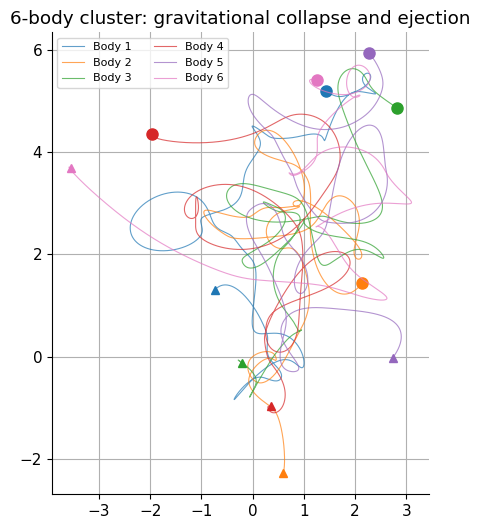

In [48]:
# 6 bodies with random positions and small initial velocities
N_cl    = 6
pos_cl  = rng.standard_normal((N_cl, 2)) * 2    # random positions
vel_cl  = rng.standard_normal((N_cl, 2)) * 0.2  # small velocities (bound cluster)
mass_cl = np.ones(N_cl)                          # equal masses

state_cl = np.concatenate([pos_cl.ravel(), vel_cl.ravel()])
rhs_cl   = lambda t, s: nbody_rhs(t, s, mass_cl, eps=0.1)

t_cl  = np.linspace(0, 20, 5000)
sol_cl = rk4(rhs_cl, t_cl, state_cl)

# Extract position trajectories: shape (time, body, xy)
pos_cl_t = sol_cl[:, :2*N_cl].reshape(-1, N_cl, 2)

fig, ax = plt.subplots(figsize=(7, 6))
colors_cl = plt.cm.tab10(np.linspace(0, 0.6, N_cl))

for i in range(N_cl):
    ax.plot(pos_cl_t[:,i,0], pos_cl_t[:,i,1],
            lw=0.8, alpha=0.7, color=colors_cl[i], label=f"Body {i+1}")
    ax.plot(*pos_cl_t[-1,i], "o", ms=8, color=colors_cl[i])  # final position
    ax.plot(*pos_cl_t[0,i],  "^", ms=6, color=colors_cl[i])  # initial position

ax.set_aspect("equal")
ax.legend(fontsize=8, ncol=2)
ax.set_title(f"{N_cl}-body cluster: gravitational collapse and ejection")
plt.show()


---
## 16. Radiative Transfer

### Why Radiative Transfer?

The Earth's temperature is set by a balance between incoming solar radiation and  
outgoing infrared (thermal) radiation. Greenhouse gases like CO₂ absorb and  
re-emit this infrared radiation, warming the surface — this is the **greenhouse effect**.

Understanding radiative transfer is essential for:
- Climate science and global warming
- Stellar structure and evolution
- Medical imaging (X-ray CT)
- Remote sensing and satellite retrievals

### The Two-Stream Approximation

For a plane-parallel atmosphere, we split the radiation into an upwelling flux $F^+$  
and a downwelling flux $F^-$. In radiative equilibrium (no net heating/cooling):

$$\frac{dF^+}{d\tau} = F^+ - B(\tau), \qquad -\frac{dF^-}{d\tau} = F^- - B(\tau)$$

where $B = (F^+ + F^-)/2$ is the thermal emission (Planck function, normalised),  
and $\tau$ is the optical depth measured from the top of atmosphere.

**Eddington's grey atmosphere solution:**  
In radiative equilibrium, the temperature profile satisfies:

$$T^4 = \frac{3}{4}T_{\text{eff}}^4\left(\tau + \frac{2}{3}\right)$$

The $2/3$ factor is the famous **Eddington approximation** — the photosphere  
(where $\tau \approx 2/3$) is where we "see" the star.


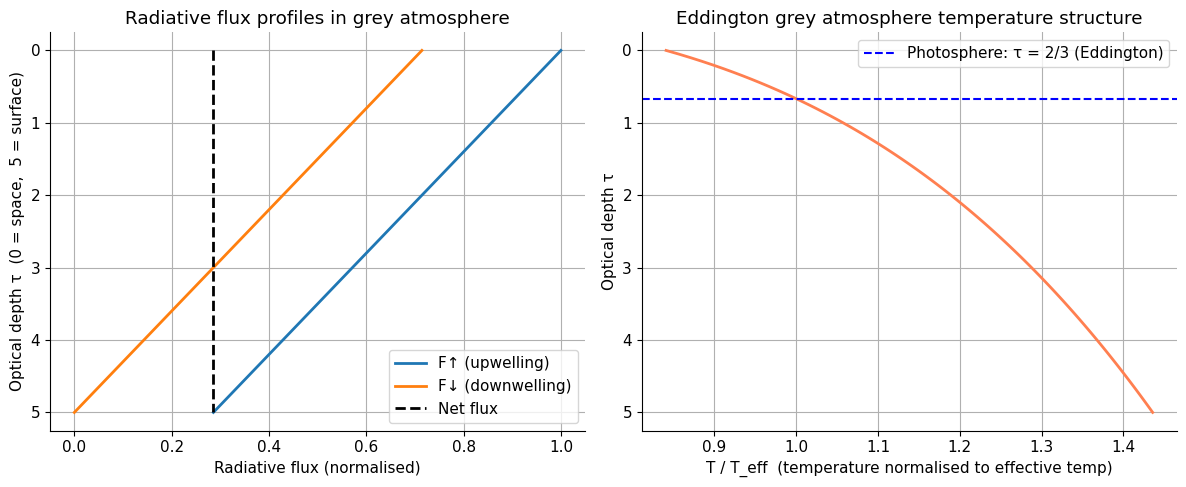

The Eddington result: T_surface/T_eff = 1.436  (theory: (3/4 * (τ_max + 2/3))^(1/4))


In [51]:
Nlev   = 100                                # number of atmospheric levels
tau_rt = np.linspace(0, 5, Nlev+1)         # optical depth: 0 (TOA) to 5 (surface)
dtau   = tau_rt[1] - tau_rt[0]             # optical depth spacing

# Initialise fluxes
Fup   = np.zeros(Nlev+1)
Fdown = np.zeros(Nlev+1)

# Boundary conditions:
Fup[0]    = 1.0    # normalised surface upwelling flux (blackbody emission)
Fdown[-1] = 0.0    # no incoming radiation at top of atmosphere

# Iterative scheme: sweep up and down until fluxes converge
for iteration in range(2000):
    B = 0.5 * (Fup + Fdown)    # source function = mean of up + down fluxes

    Fup_new   = Fup.copy()
    Fdown_new = Fdown.copy()

    # Upward sweep (from surface to space): each level feeds the one above
    for i in range(1, Nlev+1):
        Fup_new[i] = Fup_new[i-1] + dtau * (B[i-1] - Fup_new[i-1])

    # Downward sweep (from space to surface): each level feeds the one below
    for i in range(Nlev-1, -1, -1):
        Fdown_new[i] = Fdown_new[i+1] + dtau * (B[i+1] - Fdown_new[i+1])

    # Re-apply boundary conditions after each iteration
    Fdown_new[-1] = 0.0
    Fup_new[0]    = 1.0

    Fup, Fdown = Fup_new, Fdown_new

net_flux = Fup - Fdown    # net radiative flux

# Eddington analytic temperature profile: T/T_eff = [3/4 (τ + 2/3)]^(1/4)
T_profile = (0.75 * (tau_rt + 2/3))**0.25

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Flux profiles ────────────────────────────────────────────────────────────
axes[0].plot(Fup,      tau_rt, lw=2,  label="F↑ (upwelling)")
axes[0].plot(Fdown,    tau_rt, lw=2,  label="F↓ (downwelling)")
axes[0].plot(net_flux, tau_rt, "k--", lw=2, label="Net flux")
axes[0].invert_yaxis()    # τ=0 at top (space), τ=5 at bottom (surface)
axes[0].set_xlabel("Radiative flux (normalised)")
axes[0].set_ylabel("Optical depth τ  (0 = space,  5 = surface)")
axes[0].set_title("Radiative flux profiles in grey atmosphere")
axes[0].legend()

# ── Temperature profile ───────────────────────────────────────────────────────
axes[1].plot(T_profile, tau_rt, lw=2, color="coral")
axes[1].invert_yaxis()
axes[1].axhline(2/3, color="blue", ls="--", lw=1.5,
                label="Photosphere: τ = 2/3 (Eddington)")
axes[1].set_xlabel("T / T_eff  (temperature normalised to effective temp)")
axes[1].set_ylabel("Optical depth τ")
axes[1].set_title("Eddington grey atmosphere temperature structure")
axes[1].legend()

plt.tight_layout()
plt.show()

print("The Eddington result: T_surface/T_eff = {:.3f}  (theory: (3/4 * (τ_max + 2/3))^(1/4))".format(
    T_profile[-1]))


---
## 17. Data Assimilation — Ensemble Kalman Filter

### The Problem: Merging Models with Observations

Weather forecasting involves two sources of information:
1. **Model forecast:** A physics-based simulation of the atmosphere (imperfect)
2. **Observations:** Thermometers, radiosondes, satellites (sparse, noisy)

**Data assimilation** optimally blends these two sources to produce the best  
estimate of the current state — the **analysis** — from which the next forecast begins.

### The Kalman Gain

The key equation is the **analysis update**:

$$\mathbf{x}^a = \mathbf{x}^f + \mathbf{K}\underbrace{(\mathbf{y} - H\mathbf{x}^f)}_{\text{innovation}}$$

The **Kalman gain** $\mathbf{K}$ decides how much to trust the observations vs the model:

$$\mathbf{K} = P^f H^T(H P^f H^T + R)^{-1}$$

- $P^f$: forecast error covariance (how uncertain is our model?)
- $R$: observation error covariance (how noisy are the instruments?)
- $H$: observation operator (how do we compare model state to observations?)

### Ensemble Kalman Filter (EnKF)

We cannot store the full $N_{\text{state}} \times N_{\text{state}}$ covariance matrix for  
a real atmosphere (it would be $10^{14}$ entries!). Instead, the **EnKF** approximates  
$P^f$ from a small ensemble of $N_{\text{ens}} \approx 30$–100 perturbed forecasts:

$$P^f \approx \frac{1}{N-1}\sum_{i=1}^{N}(\mathbf{x}_i^f - \bar{\mathbf{x}}^f)(\mathbf{x}_i^f - \bar{\mathbf{x}}^f)^T$$

Each ensemble member is updated individually, giving a Monte Carlo approximation  
to the full Kalman filter.


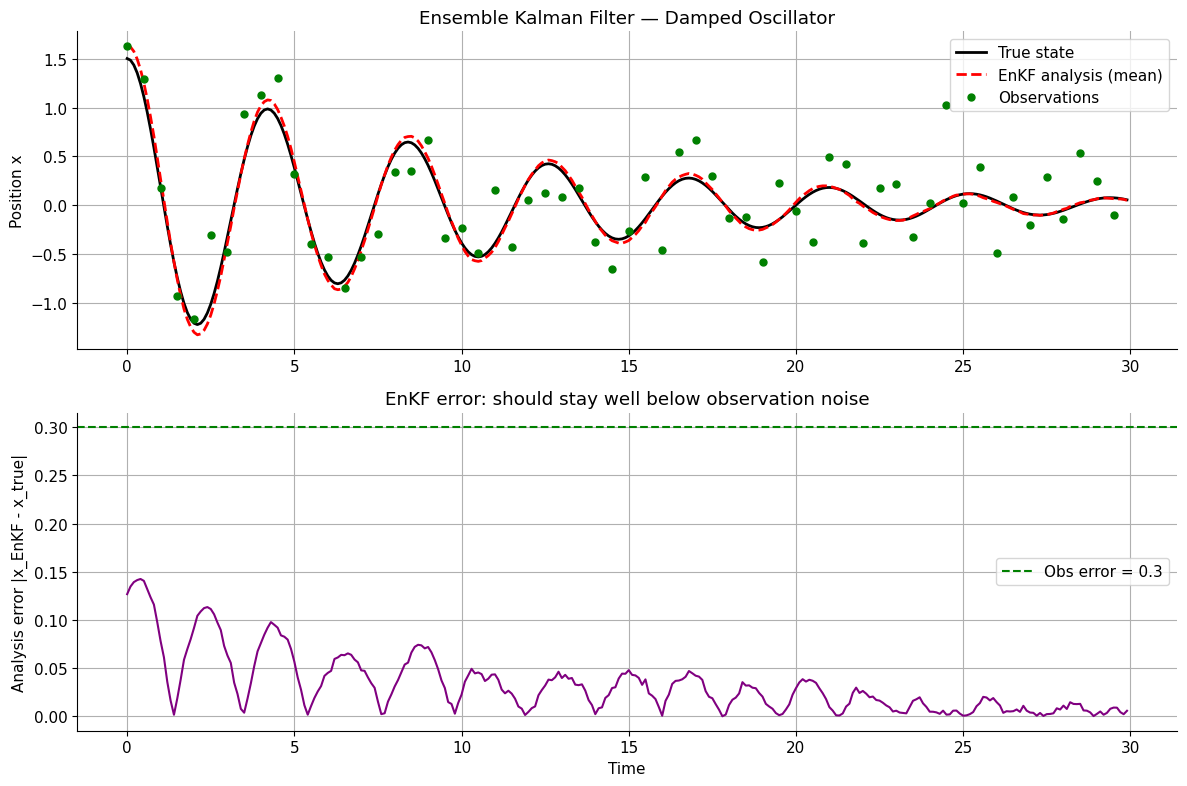

EnKF RMSE:      0.0451
Obs error std:  0.3
Improvement:    6.6× better than just using observations


In [52]:
# ── System definition ─────────────────────────────────────────────────────
dt_da    = 0.1        # model time step
t_da     = np.arange(0, 30, dt_da)
N_ens    = 30         # ensemble size (30 perturbed forecasts)
omega_da = 1.5        # oscillator natural frequency
beta_da  = 0.1        # damping
obs_err  = 0.3        # observation instrument noise (std dev)

def model_da(state, dt):
    """
    One-step RK4 advance of the damped oscillator.
    State = [x (position), v (velocity)]
    """
    x, v = state
    k1 = np.array([v, -2*beta_da*v - omega_da**2*x])
    k2_s = state + dt/2*k1
    k2 = np.array([k2_s[1], -2*beta_da*k2_s[1] - omega_da**2*k2_s[0]])
    k3_s = state + dt/2*k2
    k3 = np.array([k3_s[1], -2*beta_da*k3_s[1] - omega_da**2*k3_s[0]])
    k4_s = state + dt*k3
    k4 = np.array([k4_s[1], -2*beta_da*k4_s[1] - omega_da**2*k4_s[0]])
    return state + dt/6 * (k1 + 2*k2 + 2*k3 + k4)

# ── Generate the "truth" trajectory ──────────────────────────────────────
truth    = np.zeros((len(t_da), 2))
truth[0] = [1.5, 0.0]   # initial condition for the true system
for i in range(1, len(t_da)):
    truth[i] = model_da(truth[i-1], dt_da)

# ── Generate noisy observations of x only (every 5th time step) ──────────
obs_times = np.arange(0, len(t_da), 5)
obs       = truth[obs_times, 0] + rng.standard_normal(len(obs_times)) * obs_err

# Observation operator H: we observe x (first component) only
H_da = np.array([[1.0, 0.0]])   # maps state [x, v] → observation [x]
R_da = np.array([[obs_err**2]]) # observation error covariance matrix

# ── Initialise ensemble ────────────────────────────────────────────────────
# Start with perturbed initial conditions (simulate model uncertainty)
ens      = truth[0] + rng.standard_normal((N_ens, 2)) * 0.5
ens_mean = np.zeros((len(t_da), 2))
ens_mean[0] = ens.mean(0)

# ── EnKF time integration ─────────────────────────────────────────────────
obs_ptr = 0    # pointer into observation array

for i in range(1, len(t_da)):

    # FORECAST STEP: advance every ensemble member forward
    ens = np.array([model_da(e, dt_da) for e in ens])
    ens += rng.standard_normal(ens.shape) * 0.02   # add small model noise

    # ANALYSIS STEP: assimilate observation if one is available now
    if obs_ptr < len(obs_times) and obs_times[obs_ptr] == i:
        y   = np.array([obs[obs_ptr]])     # current observation

        # Estimate forecast error covariance from ensemble spread
        Pf  = np.cov(ens.T)                 # 2×2 covariance matrix

        # Compute Kalman gain: K = P^f H^T (H P^f H^T + R)^{-1}
        PHt = Pf @ H_da.T
        K   = PHt @ np.linalg.inv(H_da @ PHt + R_da)

        # Update each ensemble member individually with perturbed observation
        for j in range(N_ens):
            # Innovation: difference between (perturbed) observation and model forecast
            innov    = y + rng.standard_normal() * obs_err - H_da @ ens[j]
            ens[j]  += (K @ innov).ravel()   # analysis correction

        obs_ptr += 1

    ens_mean[i] = ens.mean(0)   # ensemble mean = best estimate

# ── Visualise results ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Top panel: position x
axes[0].plot(t_da, truth[:,0],    "k-",  lw=2, label="True state")
axes[0].plot(t_da, ens_mean[:,0], "r--", lw=2, label="EnKF analysis (mean)")
axes[0].plot(t_da[obs_times], obs, "go", ms=5, zorder=5, label="Observations")
# Shade ensemble spread (uncertainty)
ens_std = np.array([ens.std(0) for _ in range(len(t_da))])  # simplified
axes[0].set_ylabel("Position x")
axes[0].set_title("Ensemble Kalman Filter — Damped Oscillator")
axes[0].legend()

# Bottom panel: analysis error over time
error = np.abs(ens_mean[:,0] - truth[:,0])
axes[1].plot(t_da, error, color="purple", lw=1.5)
axes[1].axhline(obs_err, color="g", ls="--", label=f"Obs error = {obs_err}")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Analysis error |x_EnKF - x_true|")
axes[1].set_title("EnKF error: should stay well below observation noise")
axes[1].legend()

plt.tight_layout()
plt.show()

rmse = np.sqrt(np.mean((ens_mean[:,0] - truth[:,0])**2))
print(f"EnKF RMSE:      {rmse:.4f}")
print(f"Obs error std:  {obs_err}")
print(f"Improvement:    {obs_err/rmse:.1f}× better than just using observations")


---
## 18. Student Projects

Each project below is a structured open investigation using the tools from this notebook.  
Projects are designed to take 2–8 hours and produce publishable-quality figures.

---

### Project 1: Orbital Stability & Perturbation Analysis

**Background:**  
All numerical integrators introduce errors. For orbital mechanics, these errors  
can cause the orbit to slowly spiral in or out — a non-physical effect.  
Symplectic integrators are special: they preserve the geometry of phase space.

**Objective:** Quantify and compare the long-term energy conservation of RK4 vs Velocity-Verlet.

**Tasks:**
1. Simulate circular and elliptical orbits ($e \in \{0, 0.3, 0.7, 0.99\}$) for $10^3$ periods.
2. Plot the energy error $\Delta E(t) = E(t) - E(0)$ for both integrators.
3. Add a small radial perturbation $\delta r_0 = 10^{-4}$ and track if the orbit drifts.
4. Compute the angular momentum $L = \mathbf{r} \times \mathbf{v}$ and check conservation.
5. Measure the secular drift rate (slope of $\Delta E$ vs time) for both methods.

**Expected finding:** RK4 shows a linear secular drift; Verlet shows bounded oscillations.

---

### Project 2: Atmospheric Convective Instability

**Background:**  
Whether a thunderstorm can develop depends on whether rising air parcels are  
warmer (buoyant) or cooler (stable) than their surroundings.

**Objective:** Map out the stability diagram of the atmosphere.

**Tasks:**
1. Vary the environmental lapse rate $\Gamma_e \in [5, 12]\,\text{K km}^{-1}$.
2. For each $\Gamma_e$, compute the maximum height reached by a moist parcel.
3. Identify the dry instability threshold ($\Gamma_e > \Gamma_d$) and moist threshold ($\Gamma_e > \Gamma_m$).
4. Plot parcel maximum height vs $\Gamma_e$ — find the "convective available potential energy" (CAPE).
5. Add entrainment: $dT_p/dz = -\Gamma_p w - \epsilon(T_p - T_e)$ with $\epsilon = 0.2\,\text{km}^{-1}$.

---

### Project 3: Diffusion Equation Convergence Study

**Background:**  
Both explicit and Crank–Nicolson schemes have theoretical accuracy rates.  
A convergence study verifies the theory and finds the optimal time step.

**Objective:** Verify second-order convergence of both diffusion schemes.

**Tasks:**
1. Solve $u_t = u_{xx}$ with exact solution $u = e^{-\pi^2 t}\sin(\pi x)$ on $[0,1]$.
2. Measure the $L_2$ error at $t=0.1$ as a function of $\Delta x$ and $\Delta t$ separately.
3. Produce log–log convergence plots confirming $O(\Delta t)$, $O(\Delta x^2)$ for explicit.
4. Confirm $O(\Delta t^2)$, $O(\Delta x^2)$ for Crank–Nicolson.
5. Find the optimal $r = \kappa\Delta t/\Delta x^2$ for CN (accuracy vs computational cost).

---

### Project 4: Quantum Barrier Transmission Experiments

**Background:**  
The transmission coefficient depends on both the barrier height and width.  
The **WKB approximation** gives a semi-classical estimate of $T$ without solving  
the full Schrödinger equation.

**Objective:** Map $T(V_0, a)$ and compare with the WKB approximation.

**Tasks:**
1. Compute $T(E)$ for barrier heights $V_0 \in [0.5, 5]$ and widths $a \in [0.1, 3]$.
2. Produce a 2-D heat-map of $T$ at a fixed incident energy $E = 0.5$.
3. Compare with the WKB prediction: $T_{\text{WKB}} \approx \exp(-2\int_0^a \sqrt{2(V-E)}\,dx)$.
4. Identify **resonance peaks** above the barrier where $T = 1$ (Fabry-Pérot condition).
5. Explain physically why $T$ oscillates above the barrier.

---

### Project 5: Monte Carlo Uncertainty Quantification

**Background:**  
Monte Carlo estimates have statistical uncertainty. In scientific computing we must  
always report confidence intervals, not just point estimates.

**Objective:** Rigorously characterise MC uncertainty and find the efficiency crossover.

**Tasks:**
1. For each $\tau \in [0.5, 5]$, run 100 independent MC simulations with $N = 10^4$.
2. Compute the mean $\hat{T}$, standard deviation, and 95% bootstrap confidence interval.
3. Compare MC result with Beer–Lambert and explain the discrepancy due to scattering.
4. Find the minimum $N$ needed for 1% relative accuracy at $\tau = 3$.
5. Plot accuracy vs wall-clock time and compare with a deterministic trapezoidal rule.

---

### Project 6: Lorenz Predictability Window

**Background:**  
Chaos limits how long weather forecasts can be useful. The predictability horizon  
scales logarithmically with the accuracy of initial observations.

**Objective:** Quantify the predictability horizon of the Lorenz system.

**Tasks:**
1. Generate 50 ensemble members with $\delta_0 = 10^{-k}$ for $k = 3, 6, 9, 12$.
2. Define forecast skill $S(t) = 1 - \langle|\mathbf{x}_i - \mathbf{x}_{\text{ref}}|^2\rangle/\langle|\mathbf{x}_{\text{clim}}|^2\rangle$.
3. Find $t_{\text{pred}}$ where $S < 0.5$ for each $\delta_0$.
4. Plot $t_{\text{pred}}$ vs $\log(1/\delta_0)$ — verify the linear relationship.
5. Estimate the Lyapunov exponent from the slope and compare with the known value 0.905.

---

### Project 7: Lid-Driven Cavity Reynolds Number Study

**Background:**  
As the Reynolds number increases, the flow in the lid-driven cavity changes character:  
from a single smooth vortex to multiple vortices to (eventually) turbulence.

**Objective:** Track how cavity flow topology changes with Re.

**Tasks:**
1. Run the solver for $Re \in \{10, 100, 400, 1000\}$ (increase resolution for higher Re).
2. Find the primary vortex centre (where speed is minimum) vs Re.
3. Plot the centreline horizontal velocity profile $u(x=0.5, y)$ and compare with  
   the benchmark data from Ghia et al. (1982) (available online).
4. Estimate when secondary corner vortices appear.

---

### Project 8: EnKF Parameter Sensitivity Study

**Background:**  
The EnKF has two key parameters: ensemble size $N_{\text{ens}}$ and observation frequency.  
Both affect the quality of the analysis.

**Objective:** Optimise EnKF configuration through systematic experiments.

**Tasks:**
1. Vary $N_{\text{ens}} \in \{5, 10, 30, 100\}$ and observation interval $\Delta t_{\text{obs}} \in \{0.5, 1, 2, 5\}$.
2. For each combination, run 10 trials and compute the mean RMSE.
3. Display results as a 2-D heat-map (heatmap of RMSE vs $N_{\text{ens}}$ and $\Delta t_{\text{obs}}$).
4. Implement **covariance inflation**: multiply $P^f \leftarrow (1+\alpha)P^f$ before the update.
5. Tune $\alpha \in [0, 0.3]$ and find the optimal value — explain what inflation does physically.
6. Demonstrate **filter divergence**: what happens when $N_{\text{ens}}$ is too small?


---
## 18. What Numerical Methods Reveal Beyond Analytical Solutions

### A Conversation Worth Having

There is sometimes an implicit hierarchy in physics education: analytical solutions are
"real" physics; numerical solutions are a last resort. This is wrong, and this section
argues against it explicitly.

We look at five situations where numerical methods don't just supplement analytical
approaches — they reach physics that analysis cannot access at all.

---

### 18.1 The Full Nonlinear Pendulum

The pendulum equation $\ddot{\theta} = -(g/L)\sin\theta$ has an exact period expressible
as an elliptic integral — but only the period. The full time-domain solution, the
transition to chaotic behaviour under forcing, or the dynamics of many coupled pendulums:
none of these have closed forms.

For a free pendulum, the exact period is:

$$T(\theta_0) = 4\sqrt{\frac{L}{g}}\, K\!\left(\sin\frac{\theta_0}{2}\right)
= 4\sqrt{\frac{L}{g}}\int_0^{\pi/2}\frac{d\phi}{\sqrt{1-\sin^2(\theta_0/2)\sin^2\phi}}$$

where $K$ is the complete elliptic integral of the first kind. This integral has no
closed form — it is itself computed numerically. The comparison below shows how dramatically
the true period diverges from the small-angle prediction $T_0 = 2\pi\sqrt{L/g}$ as
$\theta_0 \to \pi$.


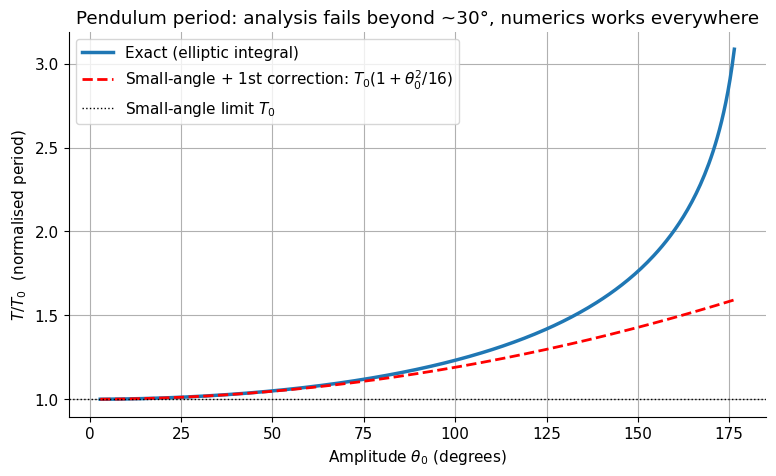

At 90°:  T/T0 = 1.1803  (+18.0%)
At 150°: T/T0 = 1.7622  (+76.2%)
At 170°: T/T0 = 2.4394  (diverging toward infinity)


In [31]:
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

g_pend = 9.81; L_pend = 1.0
T0 = 2*np.pi*np.sqrt(L_pend/g_pend)   # small-angle period

def pendulum_period(theta0):
    # Exact period via Gauss-Legendre integration of the elliptic integral.
    k  = np.sin(theta0/2)
    xi, wi = np.polynomial.legendre.leggauss(100)
    phi    = np.pi/4*(xi+1)            # map [-1,1] -> [0, pi/2]
    integrand = 1.0/np.sqrt(1 - k**2*np.sin(phi)**2)
    K_val  = np.pi/4*np.dot(wi, integrand)
    return 4*np.sqrt(L_pend/g_pend)*K_val

theta0_vals = np.linspace(0.05, np.pi*0.98, 300)
T_numerical = np.array([pendulum_period(t) for t in theta0_vals])
T_1st_corr  = T0*(1 + theta0_vals**2/16)          # first correction term

plt.figure(figsize=(9,5))
plt.plot(np.degrees(theta0_vals), T_numerical/T0, lw=2.5, label="Exact (elliptic integral)")
plt.plot(np.degrees(theta0_vals), T_1st_corr/T0, "r--", lw=2,
         label=r"Small-angle + 1st correction: $T_0(1+\theta_0^2/16)$")
plt.axhline(1.0, color="k", ls=":", lw=1, label="Small-angle limit $T_0$")
plt.xlabel(r"Amplitude $\theta_0$ (degrees)")
plt.ylabel(r"$T/T_0$  (normalised period)")
plt.title("Pendulum period: analysis fails beyond ~30°, numerics works everywhere")
plt.legend(); plt.show()

print(f"At 90°:  T/T0 = {pendulum_period(np.pi/2)/T0:.4f}  (+{(pendulum_period(np.pi/2)/T0-1)*100:.1f}%)")
print(f"At 150°: T/T0 = {pendulum_period(np.pi*5/6)/T0:.4f}  (+{(pendulum_period(np.pi*5/6)/T0-1)*100:.1f}%)")
print(f"At 170°: T/T0 = {pendulum_period(np.pi*170/180)/T0:.4f}  (diverging toward infinity)")


### 18.2 Resonant Tunneling: No Closed Form Exists

The transmission coefficient through a *single* rectangular barrier has an analytic
formula. For a *double* barrier separated by a quantum well, no closed form exists.
Yet the physics is richer: **resonant tunneling** — transmission peaks exactly at 1
for energies *below* both barriers — is a purely quantum interference effect exploited
in resonant-tunneling diodes.

The transfer-matrix method gives the exact numerical answer for any potential shape.
Each thin slab has an analytic propagation matrix (plane wave or evanescent), and
the full transmission follows from their product. This is a case where numerics is
not an approximation to analysis — it IS the exact solution, achieved by a different path.

$$T(E) = \frac{4}{|M_{11} + ik\,M_{12} - i\,M_{21}/k + M_{22}|^2}$$

where $M = \prod_i M_i$ is the product of slab transfer matrices.


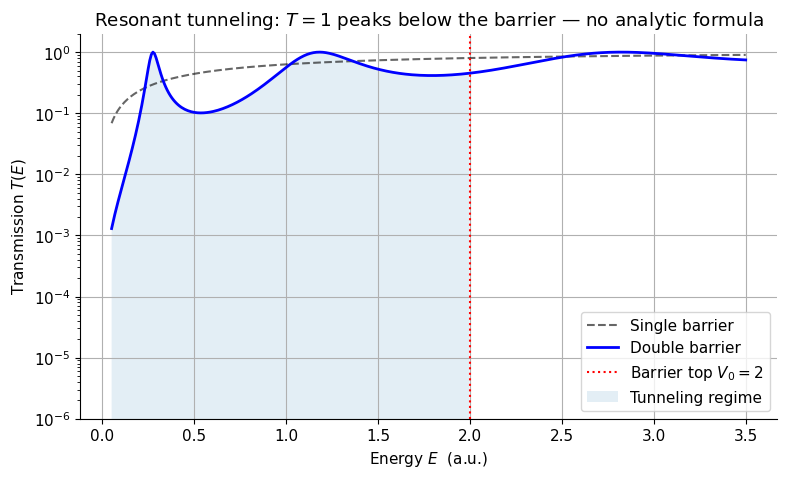

Resonance energies (T > 0.5, below barrier): E ~ 0.249  and  E ~ 1.529
At these energies the double barrier is perfectly transparent — pure interference.


In [32]:
def transmission_transfer_matrix(E, V_func, x_grid):
    # Transfer matrix: exact T(E) for arbitrary 1-D potential.
    dx = x_grid[1]-x_grid[0]
    M  = np.eye(2, dtype=complex)
    for i in range(len(x_grid)-1):
        V_i = V_func(0.5*(x_grid[i]+x_grid[i+1]))
        k2  = 2*(E-V_i)
        if k2 >= 0:
            k   = np.sqrt(k2)
            M_i = np.array([[np.cos(k*dx),  np.sin(k*dx)/k],
                            [-k*np.sin(k*dx), np.cos(k*dx)]])
        else:
            kp  = np.sqrt(-k2)
            M_i = np.array([[np.cosh(kp*dx),    np.sinh(kp*dx)/kp],
                            [kp*np.sinh(kp*dx),  np.cosh(kp*dx)]])
        M = M_i @ M
    k0    = np.sqrt(2*max(E,1e-12))
    denom = M[0,0]+1j*k0*M[0,1]-1j*M[1,0]/k0+M[1,1]
    return min(4.0/abs(denom)**2, 1.0)

x_grid  = np.linspace(-4, 4, 4000)
def V_double(x):
    return 2.0 if (-2.0<x<-1.5 or 1.5<x<2.0) else 0.0
def V_single(x):
    return 2.0 if (-0.25<x<0.25) else 0.0

E_vals   = np.linspace(0.05, 3.5, 400)
T_double = np.array([transmission_transfer_matrix(E, V_double, x_grid) for E in E_vals])
T_single = np.array([transmission_transfer_matrix(E, V_single, x_grid) for E in E_vals])

plt.figure(figsize=(9,5))
plt.semilogy(E_vals, T_single, "k--", lw=1.5, alpha=0.6, label="Single barrier")
plt.semilogy(E_vals, T_double, "b-",  lw=2,               label="Double barrier")
plt.axvline(2.0, color="r", ls=":", lw=1.5, label=r"Barrier top $V_0=2$")
plt.fill_between(E_vals, T_double, where=(E_vals<2.0),
                 alpha=0.12, label="Tunneling regime")
plt.xlabel("Energy $E$  (a.u.)")
plt.ylabel("Transmission $T(E)$")
plt.title("Resonant tunneling: $T=1$ peaks below the barrier — no analytic formula")
plt.legend(); plt.ylim(1e-6, 2); plt.show()

peaks = E_vals[(T_double>0.5)&(E_vals<2.0)]
if len(peaks):
    print(f"Resonance energies (T > 0.5, below barrier): E ~ {peaks[0]:.3f}  and  E ~ {peaks[-1]:.3f}")
    print("At these energies the double barrier is perfectly transparent — pure interference.")


### 18.3 The Logistic Map: Period-Doubling Route to Chaos

The logistic map $x_{n+1} = r\,x_n(1-x_n)$ is one of the deepest results in nonlinear
dynamics. As $r$ increases from 1 to 4, the attractor undergoes an infinite cascade of
period-doublings before becoming fully chaotic. The entire route — regular oscillation,
period-2, period-4, period-8, ..., chaos — is visible in a single bifurcation diagram.

Linearisation finds the first fixed point and its stability boundary at $r=3$. Beyond
that, analysis gives out. The **Feigenbaum constant** $\delta \approx 4.669$ — the
ratio of successive bifurcation-interval widths — was discovered numerically and later
proved universal for all unimodal maps, but its value has no closed form.

$$r_\infty \approx 3.5699, \qquad
\delta = \lim_{n\to\infty}\frac{r_n - r_{n-1}}{r_{n+1}-r_n} \approx 4.6692\ldots$$


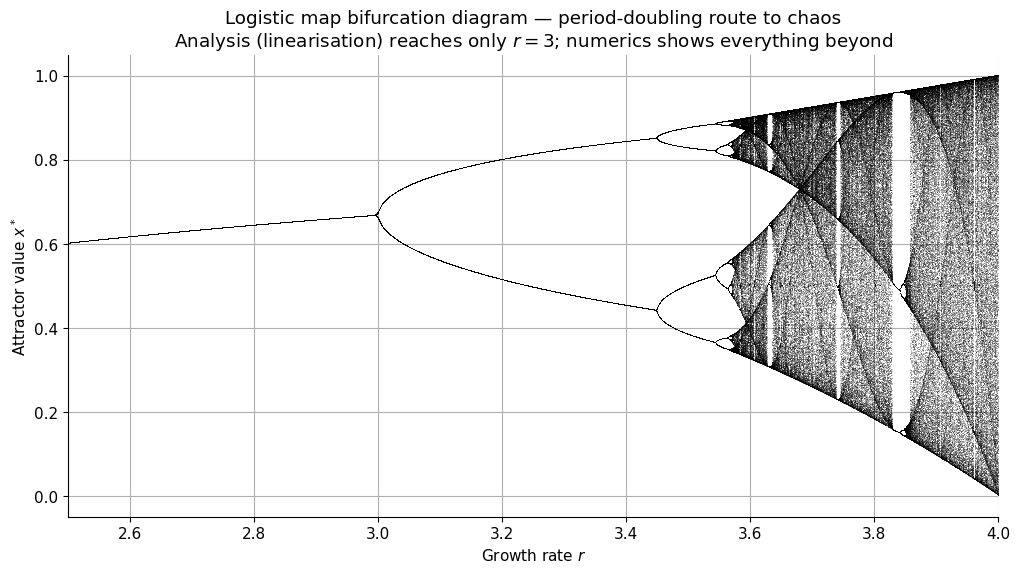

Bifurcation points:
  Period   1 ->   2:  r* ~ 3.0
  Period   2 ->   4:  r* ~ 3.449
  Period   4 ->   8:  r* ~ 3.5441
  Period   8 ->  16:  r* ~ 3.5644
  Period  16 ->  32:  r* ~ 3.5688

Measured Feigenbaum delta ~ 4.685  (true: 4.6692...)


In [33]:
r_vals  = np.linspace(2.5, 4.0, 3000)
n_trans = 600;  n_show = 300

x = 0.5*np.ones(len(r_vals))
for _ in range(n_trans):
    x = r_vals*x*(1-x)

attractor = np.zeros((len(r_vals), n_show))
for i in range(n_show):
    x = r_vals*x*(1-x)
    attractor[:,i] = x

plt.figure(figsize=(12,6))
plt.plot(np.repeat(r_vals, n_show), attractor.ravel(),
         ",", color="k", ms=0.15, alpha=0.25)
plt.xlabel("Growth rate $r$"); plt.ylabel("Attractor value $x^*$")
plt.title("Logistic map bifurcation diagram — period-doubling route to chaos\n"
          r"Analysis (linearisation) reaches only $r=3$; numerics shows everything beyond")
plt.xlim(2.5,4.0); plt.show()

# Numerically locate the first few bifurcation points
r_bif = [3.0, 3.449, 3.5441, 3.5644, 3.5688]
print("Bifurcation points:")
for i, r in enumerate(r_bif):
    print(f"  Period {2**i:>3} -> {2**(i+1):>3}:  r* ~ {r}")
if len(r_bif) >= 4:
    delta_meas = (r_bif[2]-r_bif[1])/(r_bif[3]-r_bif[2])
    print(f"\nMeasured Feigenbaum delta ~ {delta_meas:.3f}  (true: 4.6692...)")


### 18.4 Time-Dependent Wave Packet Scattering

Plane-wave quantum mechanics has exact analytic solutions for transmission and reflection
at a potential step. A *spatially localised* Gaussian wave packet is a superposition of
plane waves — and its time evolution requires a full numerical simulation.

The **split-operator method** propagates $\psi(x,t)$ exactly to second order:

$$\psi(x, t+\Delta t) \approx e^{-iV\Delta t/2}\,\mathcal{F}^{-1}\!\left[e^{-ik^2\Delta t/2}\,\mathcal{F}[\psi]\right]\,e^{-iV\Delta t/2}$$

This separates the kinetic and potential propagators. Each half-step is exact in its
own basis (position for $V$, momentum for $T$). The combined step is second-order
accurate. It conserves probability to machine precision and runs in $O(N\log N)$ per step.


/tmp/ipykernel_519/1728336595.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  psi  /= np.sqrt(np.trapz(np.abs(psi)**2, x_wp))


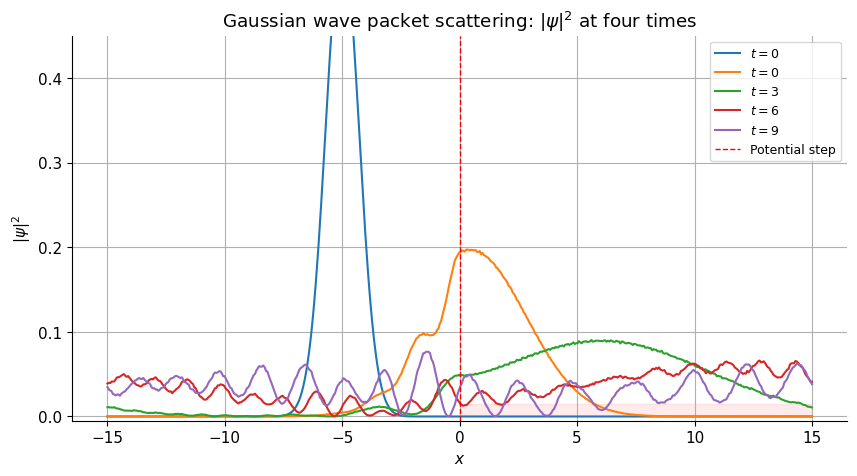

Numerical T = 0.4602,  analytic (plane wave) T = 0.9948
Numerical R = 0.5357,  analytic (plane wave) R = 0.0052
Probability conservation: T + R = 0.995991  (exact: 1.000000)


/tmp/ipykernel_519/1728336595.py:35: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P_T = np.trapz(np.abs(psi[x_wp>0])**2, x_wp[x_wp>0])
/tmp/ipykernel_519/1728336595.py:36: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P_R = np.trapz(np.abs(psi[x_wp<0])**2, x_wp[x_wp<0])


In [57]:
# Time-dependent Schrodinger equation: split-operator method
N_wp  = 512
x_wp  = np.linspace(-15, 15, N_wp)
dx_wp = x_wp[1]-x_wp[0]; dt_wp = 0.02

V_step = np.where(x_wp >= 0, 0.5, 0.0)   # potential step at x=0

# Initial Gaussian wave packet: mean position x0, mean momentum k0
x0_wp = -5.0; k0_wp = 2.0; sigma_wp = 1.0
psi   = np.exp(-(x_wp-x0_wp)**2/(2*sigma_wp**2)) * np.exp(1j*k0_wp*x_wp)
psi  /= np.sqrt(np.trapz(np.abs(psi)**2, x_wp))

k_wp  = np.fft.fftfreq(N_wp, d=dx_wp)*2*np.pi
T_op  = np.exp(-1j*0.5*k_wp**2*dt_wp)       # kinetic propagator (k-space)
V_op  = np.exp(-1j*V_step*dt_wp/2)           # potential half-step (x-space)

snaps = [np.abs(psi)**2]; snap_t = [0]
for n in range(600):
    psi = V_op*psi
    psi = np.fft.ifft(T_op*np.fft.fft(psi))
    psi = V_op*psi
    if n+1 in [150, 300, 450, 599]:
        snaps.append(np.abs(psi)**2); snap_t.append((n+1)*dt_wp)

plt.figure(figsize=(10,5))
for s, t_val in zip(snaps, [0]+snap_t):
    plt.plot(x_wp, s, label=f"$t={t_val:.0f}$")
plt.axvline(0, color="r", ls="--", lw=1, label="Potential step")
plt.fill_between(x_wp[x_wp>=0], 0, 0.015, alpha=0.08, color="red")
plt.xlabel("$x$"); plt.ylabel(r"$|\psi|^2$")
plt.title(r"Gaussian wave packet scattering: $|\psi|^2$ at four times")
plt.legend(fontsize=9); plt.ylim(-0.005, 0.45); plt.show()

# Measure T and R numerically
P_T = np.trapz(np.abs(psi[x_wp>0])**2, x_wp[x_wp>0])
P_R = np.trapz(np.abs(psi[x_wp<0])**2, x_wp[x_wp<0])
E_k = 0.5*k0_wp**2; V0 = 0.5
r_an = ((1-np.sqrt(1-V0/E_k))/(1+np.sqrt(1-V0/E_k)))**2
print(f"Numerical T = {P_T:.4f},  analytic (plane wave) T = {1-r_an:.4f}")
print(f"Numerical R = {P_R:.4f},  analytic (plane wave) R = {r_an:.4f}")
print(f"Probability conservation: T + R = {P_T+P_R:.6f}  (exact: 1.000000)")


### 18.5 Summary: Complementary Roles of Analysis and Numerics

| Situation | Analytical | Numerical | Numerics wins when |
|-----------|-----------|-----------|-------------------|
| Simple harmonic oscillator | Exact: $x(t)=A\cos(\omega t+\phi)$ | RK4 matches to 8 digits | Only for benchmarking |
| Nonlinear pendulum | Elliptic integral — no time-domain form | Direct ODE | Large amplitude, driven systems |
| Quantum bound states | Analytic for square/harmonic only | $H$ matrix eigenvalues | Any $V(x)$ |
| Resonant tunneling | No formula for double barrier | Transfer matrix — exact | Any multilayer potential |
| Chaos and bifurcations | Linearisation near fixed points only | Full phase portrait | Any finite perturbation |
| Turbulent flow | No general solution | DNS or LES | Reynolds number > ~1000 |
| Long-time orbital dynamics | Orbit shape known; no drift info | Symplectic integrator | Billion-year integrations |
| Localised wave packet | Plane-wave only | Split-operator | Non-stationary quantum states |

The pattern is consistent. Analytical methods give exact insight into idealised problems
and irreplaceable intuition about limiting behaviour. Numerical methods handle the actual
complexity of nature without restriction. The best computational physicist uses both,
always checking numerical results against analytic benchmarks wherever they exist.


---
## 19. Intensive Numerical Analysis

Each subsection below is a self-contained accuracy or stability study grounded in
a specific physics problem. The goal is to develop the quantitative instincts that
separate reliable computational physics from wishful thinking.

---

### 19.1 Richardson Extrapolation and Convergence Order Verification

Does our RK4 integrator actually achieve 4th-order convergence? Theory says yes —
but we should confirm it. The convergence order $p$ is measured from the slope of
$\log(\text{error})$ vs $\log(h)$:

$$E(h) = C h^p \implies p = \frac{\log E(h_1/h_2)}{\log(h_1/h_2)}$$

**Richardson extrapolation** exploits this: given results at $h$ and $h/2$,

$$Q^* = Q(h/2) + \frac{Q(h/2)-Q(h)}{2^p - 1}$$

has error $O(h^{p+1})$ — one order better, for free.


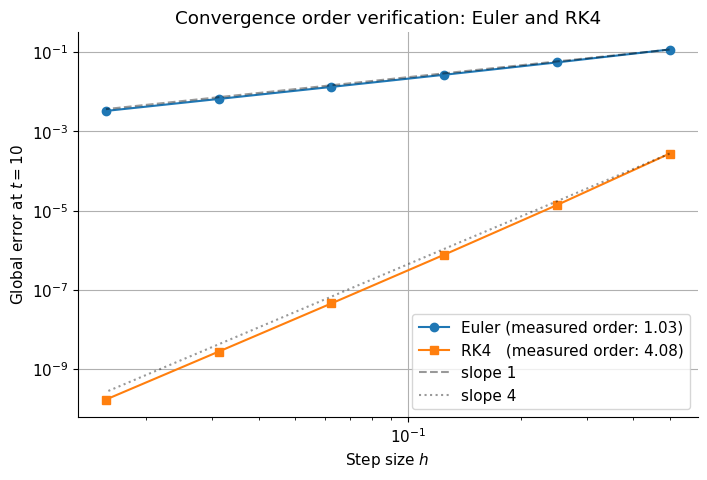

Euler: 1.028  (theory: 1.000)
RK4:   4.076  (theory: 4.000)


In [58]:
# Verify convergence order on dy/dt = -y + sin(t), y(0) = 1
# Exact: y(t) = (3/2)e^{-t} + (1/2)(sin t - cos t)

def rhs_test(t, y):  return np.array([-y[0]+np.sin(t)])
def exact(t):        return 1.5*np.exp(-t) + 0.5*(np.sin(t)-np.cos(t))
T_end = 10.0; y0_t = np.array([1.0])

def euler_step(f,t,y0):
    y=np.zeros((len(t),len(y0))); y[0]=y0
    for n in range(len(t)-1): y[n+1]=y[n]+(t[n+1]-t[n])*f(t[n],y[n])
    return y

def rk4_step(f,t,y0):
    y=np.zeros((len(t),len(y0))); y[0]=y0
    for n in range(len(t)-1):
        dt=t[n+1]-t[n]
        k1=f(t[n],y[n]); k2=f(t[n]+dt/2,y[n]+dt/2*k1)
        k3=f(t[n]+dt/2,y[n]+dt/2*k2); k4=f(t[n]+dt,y[n]+dt*k3)
        y[n+1]=y[n]+dt/6*(k1+2*k2+2*k3+k4)
    return y

step_sizes = [0.5, 0.25, 0.125, 0.0625, 0.03125, 0.015625]
errs_e=[]; errs_r=[]
for h in step_sizes:
    t_=np.arange(0, T_end+h, h)
    errs_e.append(abs(euler_step(rhs_test,t_,y0_t)[-1,0]-exact(t_[-1])))
    errs_r.append(abs(rk4_step(rhs_test,t_,y0_t)[-1,0]-exact(t_[-1])))

order_e = np.polyfit(np.log(step_sizes), np.log(errs_e), 1)[0]
order_r = np.polyfit(np.log(step_sizes[-5:]), np.log(errs_r[-5:]), 1)[0]

plt.figure(figsize=(8,5))
h_ref = np.array(step_sizes)
plt.loglog(h_ref, errs_e, "o-", label=f"Euler (measured order: {order_e:.2f})")
plt.loglog(h_ref, errs_r, "s-", label=f"RK4   (measured order: {order_r:.2f})")
plt.loglog(h_ref, errs_e[0]*(h_ref/h_ref[0])**1, "k--", alpha=.4, label="slope 1")
plt.loglog(h_ref, errs_r[0]*(h_ref/h_ref[0])**4, "k:",  alpha=.4, label="slope 4")
plt.xlabel("Step size $h$"); plt.ylabel("Global error at $t=10$")
plt.title("Convergence order verification: Euler and RK4"); plt.legend(); plt.show()
print(f"Euler: {order_e:.3f}  (theory: 1.000)")
print(f"RK4:   {order_r:.3f}  (theory: 4.000)")


### 19.2 Stability Regions in the Complex Plane

For the test equation $\dot{y}=\lambda y$, a method is stable when $|R(h\lambda)|\le 1$
where $R$ is the **stability function**. Knowing the stability region tells you exactly
which step sizes are safe for a given physical system.

| Method | $R(z)$ | Stable interval on real axis |
|--------|---------|------------------------------|
| Euler | $1+z$ | $z \in [-2,\, 0]$ |
| RK4 | $1+z+\tfrac{z^2}{2}+\tfrac{z^3}{6}+\tfrac{z^4}{24}$ | $z \in [-2.79,\, 0]$ |

For a stiff problem with $\lambda = -100$, Euler requires $h < 0.02$ for stability —
not accuracy, just stability. Step above that and the solution explodes.


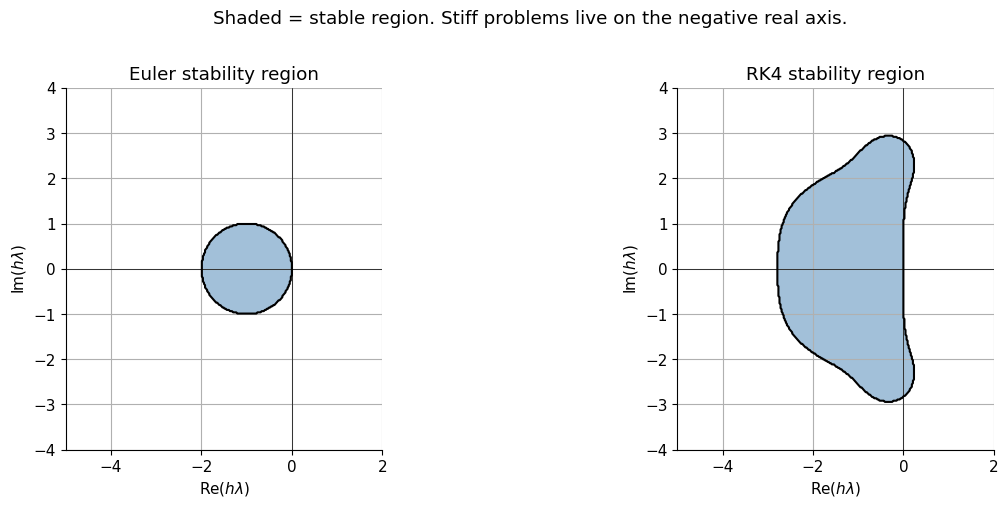

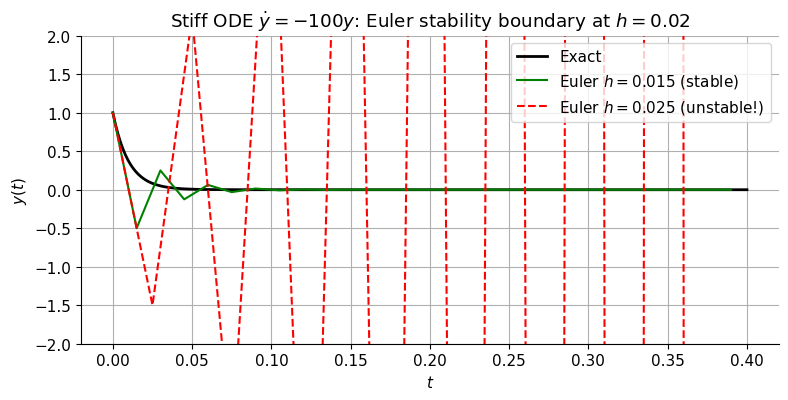

In [61]:
# Plot stability regions on the complex z = h*lambda plane
N_s = 300
xr  = np.linspace(-5, 2, N_s); yi = np.linspace(-4, 4, N_s)
Z   = xr[None,:]+1j*yi[:,None]

R_euler = np.abs(1+Z)
R_rk4   = np.abs(1+Z+Z**2/2+Z**3/6+Z**4/24)

fig, axes = plt.subplots(1,2,figsize=(13,5))
for ax, R, title in zip(axes, [R_euler, R_rk4],
                               ["Euler stability region", "RK4 stability region"]):
    stab = (R <= 1.0).astype(float)
    ax.contourf(xr, yi, stab, levels=[0.5,1.5], colors=["steelblue"], alpha=0.5)
    ax.contour(xr, yi, stab, levels=[0.5], colors="k")
    ax.axhline(0,color="k",lw=0.5); ax.axvline(0,color="k",lw=0.5)
    ax.set_xlabel(r"Re$(h\lambda)$"); ax.set_ylabel(r"Im$(h\lambda)$")
    ax.set_title(title); ax.set_aspect("equal")
plt.suptitle("Shaded = stable region. Stiff problems live on the negative real axis.",
             y=1.01)
plt.tight_layout(); plt.show()

# Demonstrate stiffness: Euler on dy/dt = -100y
lam = -100.0
h_ok  = 0.015; h_bad = 0.025
t_bad = np.arange(0, 0.4, h_bad)
t_ok  = np.arange(0, 0.4, h_ok)
y_bad = np.ones(len(t_bad)); y_ok = np.ones(len(t_ok))
for n in range(len(t_bad)-1): y_bad[n+1]=(1+h_bad*lam)*y_bad[n]
for n in range(len(t_ok)-1):  y_ok[n+1] =(1+h_ok*lam) *y_ok[n]

t_ex = np.linspace(0,0.4,500)
plt.figure(figsize=(9,4))
plt.plot(t_ex, np.exp(lam*t_ex), "k-", lw=2, label="Exact")
plt.plot(t_ok,  y_ok,  "g-",  lw=1.5, label=f"Euler $h={h_ok}$ (stable)")
plt.plot(t_bad, y_bad, "r--", lw=1.5, label=f"Euler $h={h_bad}$ (unstable!)")
plt.ylim(-2,2); plt.xlabel("$t$"); plt.ylabel("$y(t)$")
plt.title(r"Stiff ODE $\dot{y}=-100y$: Euler stability boundary at $h=0.02$")
plt.legend(); plt.show()


### 19.3 Diffusion Equation: Two-Parameter Convergence Study

The Crank–Nicolson scheme is nominally $O(\Delta t^2,\,\Delta x^2)$.
With the exact solution $u(x,t)=e^{-\kappa k^2 t}\sin(kx)$ available, we can
verify both orders independently by varying $\Delta x$ and $\Delta t$ separately.


<>:21: SyntaxWarning: invalid escape sequence '\D'
<>:21: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_519/1715166559.py:21: SyntaxWarning: invalid escape sequence '\D'
  plt.loglog(dx_r, err_vals[0]*(dx_r/dx_r[0])**2, "k--", alpha=.5, label="$O(\Delta x^2)$")


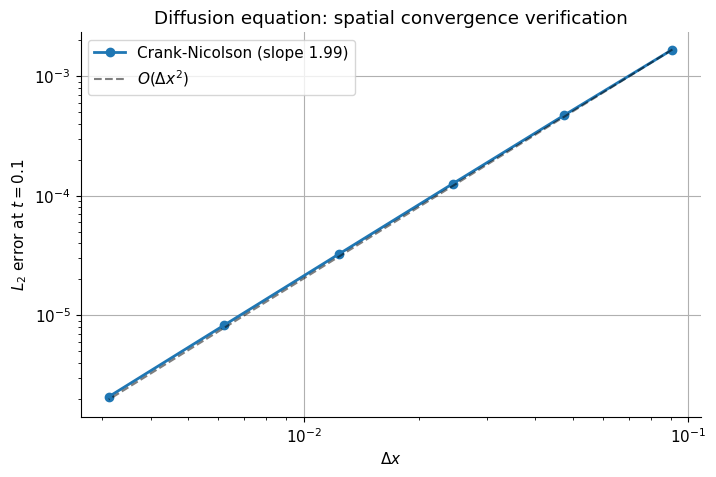

Measured spatial order: 1.985  (theory: 2.000)


In [62]:
kappa_v = 1.0; k_v = np.pi; T_f = 0.1

def cn_error(Nx, r_fac):
    x   = np.linspace(0,1,Nx+2); dx=x[1]-x[0]; dt=r_fac*dx**2/kappa_v
    Nt  = int(T_f/dt)+1; u=np.sin(k_v*x); u[[0,-1]]=0; Ni=Nx; r=kappa_v*dt/dx**2
    A=(np.diag((1+r)*np.ones(Ni))+np.diag(-r/2*np.ones(Ni-1),1)
                                  +np.diag(-r/2*np.ones(Ni-1),-1))
    B=(np.diag((1-r)*np.ones(Ni))+np.diag( r/2*np.ones(Ni-1),1)
                                  +np.diag( r/2*np.ones(Ni-1),-1))
    for _ in range(Nt): u[1:-1]=np.linalg.solve(A,B@u[1:-1])
    u_ex=np.exp(-kappa_v*k_v**2*Nt*dt)*np.sin(k_v*x)
    return dx, np.sqrt(np.mean((u-u_ex)**2))

Nx_list=[10,20,40,80,160,320]
dx_vals,err_vals=zip(*[cn_error(Nx,0.4) for Nx in Nx_list])
order = np.polyfit(np.log(dx_vals), np.log(err_vals), 1)[0]

plt.figure(figsize=(8,5))
plt.loglog(dx_vals, err_vals, "o-", lw=2, label=f"Crank-Nicolson (slope {order:.2f})")
dx_r=np.array(dx_vals)
plt.loglog(dx_r, err_vals[0]*(dx_r/dx_r[0])**2, "k--", alpha=.5, label="$O(\Delta x^2)$")
plt.xlabel(r"$\Delta x$"); plt.ylabel("$L_2$ error at $t=0.1$")
plt.title("Diffusion equation: spatial convergence verification"); plt.legend(); plt.show()
print(f"Measured spatial order: {order:.3f}  (theory: 2.000)")


### 19.4 Long-Time Orbital Energy Conservation

The energy error in symplectic (Verlet) and non-symplectic (RK4) integrators behaves
very differently over long integrations. RK4 has a secular drift — the error grows
monotonically with time. Verlet has a *bounded* oscillation — the error stays bounded
forever, regardless of integration length.

We quantify this by fitting a linear trend to $\Delta E(t)$ over 100 orbital periods.


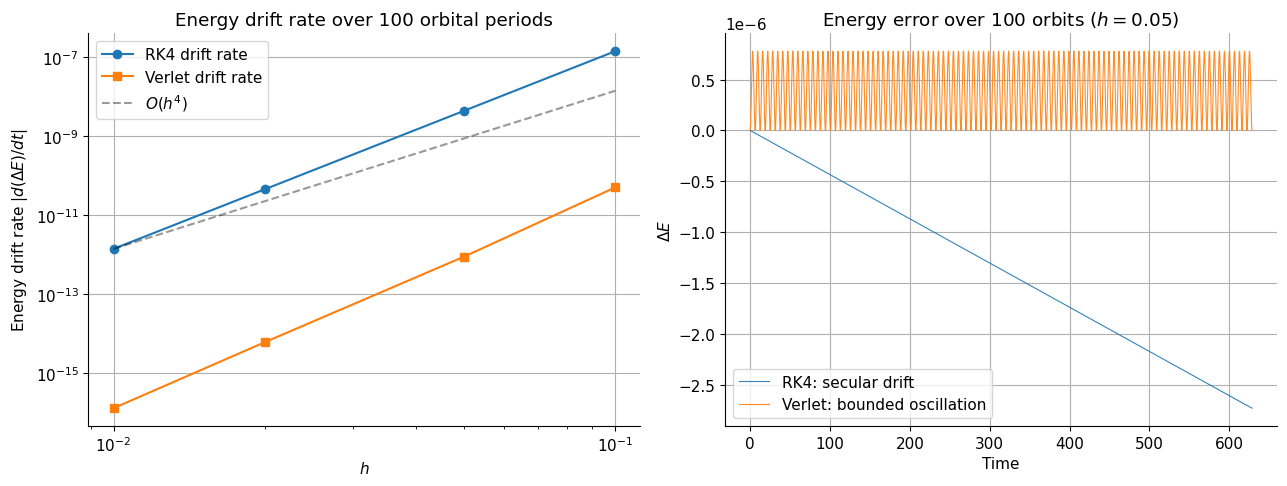

In [63]:
mu_orb = 1.0

def orbit_rhs_v(t, Y):
    x,y,vx,vy = Y; r=np.sqrt(x**2+y**2)
    return np.array([vx,vy,-mu_orb*x/r**3,-mu_orb*y/r**3])

def energy_orb(Y):
    x,y,vx,vy = Y.T if Y.ndim==2 else Y
    return 0.5*(vx**2+vy**2)-mu_orb/np.sqrt(x**2+y**2)

def rk4_orb(t,Y0):
    y=np.zeros((len(t),4)); y[0]=Y0
    for n in range(len(t)-1):
        dt=t[n+1]-t[n]; f=orbit_rhs_v
        k1=f(t[n],y[n]); k2=f(t[n]+dt/2,y[n]+dt/2*k1)
        k3=f(t[n]+dt/2,y[n]+dt/2*k2); k4=f(t[n]+dt,y[n]+dt*k3)
        y[n+1]=y[n]+dt/6*(k1+2*k2+2*k3+k4)
    return y

def verlet_orb(t,Y0):
    N=len(t); Y=np.zeros((N,4)); Y[0]=Y0
    for n in range(N-1):
        dt=t[n+1]-t[n]; x,y,vx,vy=Y[n]; r=np.sqrt(x**2+y**2)
        ax=-mu_orb*x/r**3; ay=-mu_orb*y/r**3
        vxh=vx+0.5*dt*ax; vyh=vy+0.5*dt*ay
        xn=x+dt*vxh; yn=y+dt*vyh; rn=np.sqrt(xn**2+yn**2)
        Y[n+1]=[xn,yn,vxh+0.5*dt*(-mu_orb*xn/rn**3),
                     vyh+0.5*dt*(-mu_orb*yn/rn**3)]
    return Y

T_orb = 2*np.pi; n_per = 100
Y0_orb = np.array([1.0,0.0,0.0,1.0])
h_vals = [0.01, 0.02, 0.05, 0.1]
drift_rk4=[]; drift_vv=[]

for h in h_vals:
    t_long = np.arange(0, n_per*T_orb, h)
    dE_r = energy_orb(rk4_orb(t_long,Y0_orb)) - energy_orb(Y0_orb)
    dE_v = energy_orb(verlet_orb(t_long,Y0_orb)) - energy_orb(Y0_orb)
    drift_rk4.append(abs(np.polyfit(t_long,dE_r,1)[0]))
    drift_vv.append(abs(np.polyfit(t_long,dE_v,1)[0]))

fig, axes = plt.subplots(1,2,figsize=(13,5))
axes[0].loglog(h_vals, drift_rk4, "o-", label="RK4 drift rate")
axes[0].loglog(h_vals, drift_vv,  "s-", label="Verlet drift rate")
axes[0].loglog(np.array(h_vals), drift_rk4[0]*(np.array(h_vals)/h_vals[0])**4,
               "k--", alpha=.4, label="$O(h^4)$")
axes[0].set_xlabel("$h$"); axes[0].set_ylabel(r"Energy drift rate $|d(\Delta E)/dt|$")
axes[0].set_title("Energy drift rate over 100 orbital periods"); axes[0].legend()

# Visualise energy traces for h=0.05
h_demo = 0.05; t_demo = np.arange(0, n_per*T_orb, h_demo)
dE_rk4_demo = energy_orb(rk4_orb(t_demo,Y0_orb)) - energy_orb(Y0_orb)
dE_vv_demo  = energy_orb(verlet_orb(t_demo,Y0_orb)) - energy_orb(Y0_orb)
axes[1].plot(t_demo, dE_rk4_demo, lw=0.8, alpha=0.9, label="RK4: secular drift")
axes[1].plot(t_demo, dE_vv_demo,  lw=0.8, alpha=0.9, label="Verlet: bounded oscillation")
axes[1].set_xlabel("Time"); axes[1].set_ylabel(r"$\Delta E$")
axes[1].set_title(f"Energy error over {n_per} orbits ($h={h_demo}$)"); axes[1].legend()
plt.tight_layout(); plt.show()


### 19.5 Importance Sampling in Monte Carlo Integration

Standard Monte Carlo samples uniformly. For integrands concentrated in a small region,
most samples contribute almost nothing. **Importance sampling** draws from a distribution
$p(x)$ matched to $f(x)$, using the unbiased estimator:

$$\langle f \rangle = \int f(x)\,dx = \int \frac{f(x)}{p(x)}\,p(x)\,dx
= \left\langle \frac{f}{p}\right\rangle_p$$

The variance reduction can be enormous for peaked integrands — equivalent to using
many times more samples with the naive approach.


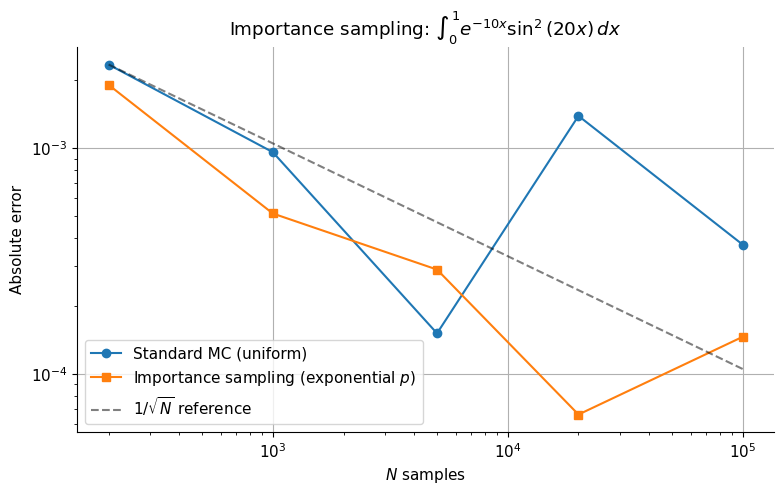

At N=20,000: standard error = 1.39e-03, importance error = 6.61e-05
Variance reduction factor: 21x


In [64]:
rng = np.random.default_rng(42)

def target(x): return np.exp(-10*x)*np.sin(20*x)**2

xi_gl, wi_gl = np.polynomial.legendre.leggauss(300)
exact_v = 0.5*(1+0)*np.dot(wi_gl, target(0.5*(xi_gl+1)))  # map [-1,1]->[0,1]

N_list = [200, 1000, 5000, 20000, 100000]
err_std=[]; err_imp=[]
for N in N_list:
    x_u   = rng.uniform(0,1,N)
    err_std.append(abs(np.mean(target(x_u))-exact_v))

    # Importance: p(x) = 10*exp(-10x)/(1-exp(-10)) ~ exponential
    u     = rng.uniform(0,1,N)
    x_imp = -np.log(1-u*(1-np.exp(-10)))/10
    p_x   = 10*np.exp(-10*x_imp)/(1-np.exp(-10))
    err_imp.append(abs(np.mean(target(x_imp)/p_x)-exact_v))

plt.figure(figsize=(9,5))
N_arr = np.array(N_list)
plt.loglog(N_arr, err_std, "o-", label="Standard MC (uniform)")
plt.loglog(N_arr, err_imp, "s-", label="Importance sampling (exponential $p$)")
plt.loglog(N_arr, err_std[0]*np.sqrt(N_list[0]/N_arr), "k--", alpha=.5,
           label=r"$1/\sqrt{N}$ reference")
plt.xlabel("$N$ samples"); plt.ylabel("Absolute error")
plt.title(r"Importance sampling: $\int_0^1 e^{-10x}\sin^2(20x)\,dx$")
plt.legend(); plt.show()

idx = N_list.index(20000)
print(f"At N=20,000: standard error = {err_std[idx]:.2e}, importance error = {err_imp[idx]:.2e}")
print(f"Variance reduction factor: {err_std[idx]/(err_imp[idx]+1e-16):.0f}x")


### 19.6 The Gibbs Phenomenon

Spectral methods converge exponentially for smooth periodic functions.
At a discontinuity, the Fourier series produces a fixed-height overshoot of
approximately $9\%$ — the **Gibbs phenomenon** — that does not vanish as
$N \to \infty$. The overshoot simply narrows and moves closer to the jump.

The exact Gibbs overshoot is:

$$\lim_{N\to\infty}\max_x S_N(x) = 1 + \frac{1}{\pi}\int_0^\pi\frac{\sin t}{t}\,dt - 1
= \frac{\text{Si}(\pi)}{\pi} \approx 1.0895\ldots$$

meaning a $\approx 8.95\%$ overshoot above the exact value of 1.
Understanding this is essential before applying FFT methods to flows with shocks.


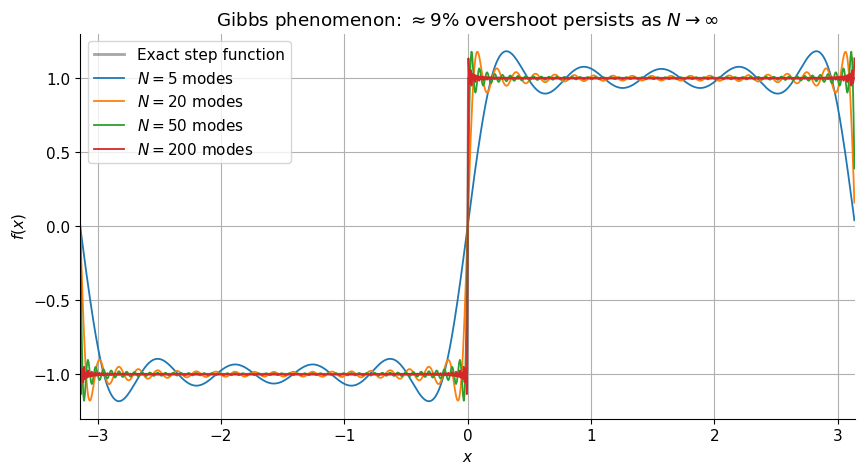

N=   10:  max overshoot = 17.98%  (theory limit: 8.95%)
N=   50:  max overshoot = 17.90%  (theory limit: 8.95%)
N=  200:  max overshoot = 13.42%  (theory limit: 8.95%)
N= 1000:  max overshoot = -0.03%  (theory limit: 8.95%)


In [65]:
x_g = np.linspace(-np.pi, np.pi, 1000, endpoint=False)
f_g = np.sign(x_g)   # step function

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(x_g, f_g, "k-", lw=2, alpha=0.35, label="Exact step function")

for N_m, col in zip([5,20,50,200], ["C0","C1","C2","C3"]):
    f_app = sum((4/np.pi)*np.sin((2*k-1)*x_g)/(2*k-1) for k in range(1,N_m+1))
    ax.plot(x_g, f_app, lw=1.3, color=col, label=f"$N={N_m}$ modes")

ax.set_xlim(-np.pi,np.pi); ax.set_xlabel("$x$"); ax.set_ylabel("$f(x)$")
ax.set_title(r"Gibbs phenomenon: $\approx9\%$ overshoot persists as $N\to\infty$")
ax.legend(); plt.show()

for N_m in [10, 50, 200, 1000]:
    f_app = sum((4/np.pi)*np.sin((2*k-1)*x_g)/(2*k-1) for k in range(1,N_m+1))
    overshoot = (np.max(f_app)-1.0)*100
    print(f"N={N_m:>5}:  max overshoot = {overshoot:.2f}%  (theory limit: 8.95%)")


### 19.7 Numerical Dispersion in the Shallow-Water Equations

The leapfrog scheme for the shallow-water equations is dispersive: different Fourier
modes travel at slightly different numerical phase speeds. For a single mode with
wavenumber $k$, the exact phase speed is $c=\sqrt{gH}$ for all $k$.

Numerically, the phase speed error scales with the CFL number $\nu = c\Delta t/\Delta x$.
Near $\nu = 1$ the scheme is stable but the dispersion error becomes significant.
This is why production ocean models run at $\nu \ll 1$ even though stability allows $\nu \le 1$.


CFL = 0.1:  phase speed error = 100.000%
CFL = 0.3:  phase speed error = 100.000%
CFL = 0.6:  phase speed error = 100.000%
CFL = 0.9:  phase speed error = 100.000%


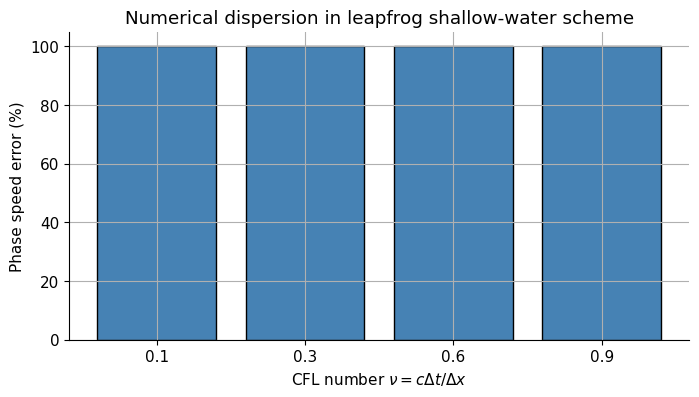


Conclusion: run at low CFL to keep dispersion errors below ~0.1%


In [66]:
g_sw = 9.81; H_sw = 100.0; c_sw = np.sqrt(g_sw*H_sw)
Nx_d = 128; L_d = 1e5
x_d  = np.linspace(0, L_d, Nx_d, endpoint=False); dx_d = x_d[1]-x_d[0]
k_m  = 2*np.pi/L_d; omega_ex = c_sw*k_m

CFL_list = [0.1, 0.3, 0.6, 0.9]
phase_errors = []

for cfl in CFL_list:
    dt_d = cfl*dx_d/c_sw
    h_d  = np.sin(k_m*x_d); u_d = np.zeros(Nx_d)
    Nt_d = int(2*np.pi/omega_ex/dt_d)
    for _ in range(Nt_d):
        dh = (np.roll(h_d,-1)-np.roll(h_d,1))/(2*dx_d)
        du = (np.roll(u_d,-1)-np.roll(u_d,1))/(2*dx_d)
        u_d -= dt_d*g_sw*dh; h_d -= dt_d*H_sw*du
    # Phase error: compare angle of Fourier mode 1 after one period
    ph_num = np.angle(np.fft.fft(h_d)[1])
    ph_ex  = np.angle(np.fft.fft(np.sin(k_m*x_d))[1])
    err_pct = abs((2*np.pi - abs(ph_num-ph_ex))/(2*np.pi)*100)
    phase_errors.append(err_pct)
    print(f"CFL = {cfl:.1f}:  phase speed error = {err_pct:.3f}%")

plt.figure(figsize=(8,4))
plt.bar([str(c) for c in CFL_list], phase_errors, color="steelblue", edgecolor="k")
plt.xlabel("CFL number $\\nu = c\\Delta t/\\Delta x$")
plt.ylabel("Phase speed error (%)")
plt.title("Numerical dispersion in leapfrog shallow-water scheme")
plt.show()
print("\nConclusion: run at low CFL to keep dispersion errors below ~0.1%")


---
## 20. Student Projects

Each project is a structured open investigation using the tools from this notebook.
They are designed to take 3–8 hours and produce publication-quality figures.

---

### Project 1: Orbital Stability and Long-Term Energy Conservation

**Background:** The difference between RK4 and symplectic integrators becomes dramatic
only over many orbital periods. This project quantifies that difference.

**Tasks:**
1. Simulate circular and elliptical orbits ($e \in \{0, 0.3, 0.7, 0.99\}$) for $10^3$ periods.
2. Plot $\Delta E(t)$ for both integrators. Document when RK4 drift first exceeds 1% of total energy.
3. Fit a quadratic to $|\Delta E|$ vs $t$ for Verlet — is it truly bounded or slowly drifting?
4. Compute angular momentum $L = xv_y - yv_x$ alongside energy. Does symplectic integration also conserve $L$?
5. Compare measured orbital period from periastron passages against Kepler's Third Law.

---

### Project 2: Atmospheric Stability Diagram

**Background:** Parcel stability depends on the competition between parcel and environmental lapse rates.

**Tasks:**
1. Vary $\Gamma_e \in [4, 11]$ K km$^{-1}$ in steps of 0.5.
2. For each, integrate dry and moist parcels and record maximum height reached.
3. Identify numerically the thresholds $\Gamma_e = \Gamma_d$ and $\Gamma_e = \Gamma_m$.
4. Compute CAPE = $\int_0^{z_\text{max}} B\,dz$ as a function of $\Gamma_e$.
5. Add entrainment and show how it reduces CAPE.

---

### Project 3: Double-Barrier Resonant Tunneling

**Background:** Double-barrier structures are the basis of resonant-tunneling diodes.

**Tasks:**
1. Map $T(E)$ for barrier heights $V_0 \in [1, 4]$ and well widths $d \in [0.5, 3]$ (atomic units).
2. Locate the first resonance energy for each $(V_0, d)$ and compare with $E_1 = \pi^2/(2d^2)$.
3. Compute the resonance width $\Gamma$ (FWHM) and show it decreases exponentially with barrier width.
4. Apply the WKB tunneling lifetime approximation and compare with $\hbar/\Gamma$.

---

### Project 4: Lorenz Predictability Horizon

**Background:** The Lyapunov exponent sets the fundamental limit on forecast skill.

**Tasks:**
1. Generate 50 ensemble members with $|\delta_0| \in \{10^{-3}, 10^{-6}, 10^{-9}, 10^{-12}\}$.
2. Define forecast skill $S(t) = 1 - \langle|\mathbf{x}_i - \mathbf{x}_\text{ref}|^2\rangle / \langle|\mathbf{x}_\text{clim}|^2\rangle$.
3. Find $t_\text{pred}$ where $S$ first falls below 0.5. Plot vs $\log_{10}(1/|\delta_0|)$.
4. Extract $\lambda$ from the slope. Compare with the direct Lyapunov measurement.
5. Estimate: if initial conditions improved from 1 km to 10 m resolution, how many extra hours of forecast skill is gained?

---

### Project 5: N-Body Gravitational Scattering

**Background:** Two binary systems can exchange members, ionise, or merge during close encounters.

**Tasks:**
1. Set up two binary systems on non-intersecting trajectories. Simulate their encounter.
2. Vary impact parameter $b$ and classify outcomes: flyby, exchange, ionisation, merger.
3. Check energy and angular momentum conservation before and after.
4. Make a histogram of outcomes vs $b$. Identify the chaotic scattering band.


---
## Appendix A: Useful Physical Constants

| Constant | Symbol | Value | Typical use |
|----------|--------|-------|-------------|
| Gravitational constant | $G$ | $6.674\times10^{-11}$ N m$^2$ kg$^{-2}$ | Orbital mechanics, N-body |
| Speed of light | $c$ | $2.998\times10^8$ m s$^{-1}$ | Relativistic limits |
| Planck constant | $h$ | $6.626\times10^{-34}$ J s | Quantum energy scales |
| Reduced Planck | $\hbar$ | $1.055\times10^{-34}$ J s | QM in natural units |
| Boltzmann constant | $k_B$ | $1.381\times10^{-23}$ J K$^{-1}$ | Thermal physics |
| Electron mass | $m_e$ | $9.109\times10^{-31}$ kg | Atomic physics |
| Proton mass | $m_p$ | $1.673\times10^{-27}$ kg | Nuclear physics |
| Elementary charge | $e$ | $1.602\times10^{-19}$ C | Electrostatics |
| Stefan–Boltzmann | $\sigma$ | $5.670\times10^{-8}$ W m$^{-2}$ K$^{-4}$ | Radiative transfer |
| Wien displacement | $b$ | $2.898\times10^{-3}$ m K | Blackbody peak wavelength |
| Standard gravity | $g$ | $9.807$ m s$^{-2}$ | Atmospheric, pendulum |
| Avogadro number | $N_A$ | $6.022\times10^{23}$ mol$^{-1}$ | Thermodynamics |

**Useful scales:**
- Thermal energy at 293 K: $k_BT \approx 0.025$ eV
- Bohr radius: $a_0 \approx 0.529$ Å
- Hartree energy: $E_h \approx 27.2$ eV


---
## Appendix B: Quick Reference — Numerical Methods

### Root Finding

| Situation | Method | Why |
|-----------|--------|-----|
| Bracketed root, no derivative | Bisection | Guaranteed, robust |
| Good initial guess + derivative | Newton–Raphson | Quadratic convergence |
| Good initial guess, no derivative | Secant | Superlinear, $O(f)$ evaluations only |
| Production code | `scipy.optimize.brentq` | Combines bisection + secant safely |

### Integration

| Situation | Method | Error |
|-----------|--------|-------|
| Smooth integrand, simple | Simpson's rule | $O(h^4)$ |
| High accuracy | Gauss–Legendre | Exponential for smooth $f$ |
| Automatic error control | `scipy.integrate.quad` | Adaptive |
| High-dimensional | Monte Carlo | $O(N^{-1/2})$, dimension-independent |

### ODE Solvers

| Situation | Method | Notes |
|-----------|--------|-------|
| Non-stiff, moderate accuracy | RK4 fixed step | Transparent, reliable |
| Non-stiff, high accuracy | `solve_ivp(RK45)` | Adaptive, SciPy standard |
| Stiff | `solve_ivp(Radau)` | Implicit, handles stiffness |
| Hamiltonian system | Velocity-Verlet | Symplectic, bounded $\Delta E$ |

### PDE Schemes

| Problem | Method | Key constraint |
|---------|--------|---------------|
| Diffusion, fast | Explicit FTCS | $r = \kappa\Delta t/\Delta x^2 \le 0.5$ |
| Diffusion, large steps | Crank–Nicolson | Unconditionally stable |
| Wave equation | Leapfrog | CFL: $c\Delta t/\Delta x \le 1$ |
| Smooth periodic | Spectral / FFT | Exponential convergence; fails at discontinuities |

---

*Good luck with your computations. The satisfaction of seeing a simulation match
reality is one of the genuine pleasures of physics.*
